# 1. Data Exploration và đồng nhất định dạng, đơn vị.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình xuất biểu đồ chất lượng cao (chuẩn báo cáo/bài báo)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
sns.set_theme(style="whitegrid")

def comprehensive_eda(file_path, target_col=None):
    """
    Hàm phân tích khám phá dữ liệu (EDA) chi tiết.
    - file_path: Đường dẫn tới file CSV.
    - target_col (tùy chọn): Tên cột mục tiêu (label) để phân tích chi tiết sự mất cân bằng lớp.
    """
    print(f'{"="*10} BÁO CÁO CHẨN ĐOÁN DỮ LIỆU {"="*10}\n')    
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Lỗi khi đọc file: {e}")
        return None

    # --- 1. TỔNG QUAN & TÍNH ĐỦ (COMPLETENESS) ---
    print(f"[1] TỔNG QUAN KÍCH THƯỚC: {df.shape[0]} dòng x {df.shape[1]} cột")
    duplicate_count = df.duplicated().sum()
    print(f"[!] Dữ liệu trùng lặp hoàn toàn: {duplicate_count} dòng ({(duplicate_count/len(df))*100:.2f}%)\n")

    print("[2] TÌNH TRẠNG KHUYẾT THIẾU (MISSING VALUES):")
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    if not missing_data.empty:
        missing_df = pd.DataFrame({
            'Số lượng thiếu': missing_data,
            'Tỷ lệ (%)': np.round((missing_data / len(df)) * 100, 2)
        })
        print(missing_df)
    else:
        print("-> Tuyệt vời! Bộ dữ liệu không có giá trị khuyết thiếu nào.\n")

    # Phân tách loại biến
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # --- 2. TÍNH ĐÚNG & PHÂN PHỐI DỮ LIỆU SỐ (CORRECTNESS & DISTRIBUTION) ---
    if num_cols:
        print("\n[3] THỐNG KÊ BIẾN ĐỊNH LƯỢNG (NUMERICAL) & PHÁT HIỆN OUTLIER:")
        num_stats = df[num_cols].describe().T
        # Bổ sung Skewness (Độ lệch) và Kurtosis (Độ nhọn)
        num_stats['skewness'] = df[num_cols].skew()
        num_stats['kurtosis'] = df[num_cols].kurtosis()
        
        # Chỉ hiển thị các cột quan trọng để tránh rối mắt
        display_stats = num_stats[['mean', 'std', 'min', '50%', 'max', 'skewness']]
        print(display_stats.round(3))
        print("  *Lưu ý: Skewness > 1 hoặc < -1 cho thấy dữ liệu có phân phối lệch (đuôi dài) hoặc chứa outlier lớn.")

    # --- 3. TỶ LỆ THỰC TẾ & MẤT CÂN BẰNG LỚP (REPRESENTATIVENESS & IMBALANCE) ---
    if cat_cols:
        print("\n[4] THỐNG KÊ BIẾN PHÂN LOẠI (CATEGORICAL):")
        cat_stats = pd.DataFrame({
            'Số giá trị Unique': df[cat_cols].nunique(),
            'Giá trị xuất hiện nhiều nhất (Top)': df[cat_cols].mode().iloc[0],
            'Tỷ lệ Top (%)': [np.round((df[col].value_counts(normalize=True).max()) * 100, 2) for col in cat_cols]
        })
        print(cat_stats)
        print("  *Lưu ý: Nếu 'Tỷ lệ Top (%)' quá cao (ví dụ > 95%), cột đó có thể gây nhiễu vì gần như chỉ chứa 1 giá trị.")
        
    return df

In [3]:
df = comprehensive_eda('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_expanded/Final_Merged_2605.csv')

========== BÁO CÁO CHẨN ĐOÁN DỮ LIỆU ==========

[1] TỔNG QUAN KÍCH THƯỚC: 9519 dòng x 16 cột
[!] Dữ liệu trùng lặp hoàn toàn: 2406 dòng (25.28%)

[2] TÌNH TRẠNG KHUYẾT THIẾU (MISSING VALUES):
                       Số lượng thiếu  Tỷ lệ (%)
Hướng ban công                   8403      88.28
Hướng nhà                        7579      79.62
Nội thất                         4731      49.70
Loại đường vào                   4675      49.11
Đường vào                        4413      46.36
Số phòng tắm, vệ sinh            3251      34.15
Số phòng ngủ                     2923      30.71
Số tầng                          1822      19.14
Pháp lý                          1552      16.30
Latitude                          915       9.61
Longitude                         915       9.61
Địa chỉ                           914       9.60
Khoảng giá                        914       9.60
Diện tích                         914       9.60
Mô tả                             914       9.60

[3] THỐNG KÊ BIẾN ĐỊNH

In [4]:
print(df.columns)
print(df.shape)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào'],
      dtype='object')
(9519, 16)


## Xử lý định dạng, thống nhất về các kiểu giá trị (trong các thuộc tính categorical) và đơn vị

Tỉ lệ missing của thuộc tính 'Hướng ban công' và 'Hướng nhà' quá cáo. Xoá bỏ 2 thuộc tính này.

### Xử lý miền giá trị của các thuộc tính categorical

Chuyển tất cả kiểu chữ thành Unicode để các bước xử lý sau dễ dàng trong xử lý chuỗi.

In [5]:
import unicodedata
import numpy as np

# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền tất cả các cột dạng chữ (Text/Categorical) bạn muốn chuẩn hóa Unicode
columns_to_normalize = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'] 
# ========================================================

print(f"{'='*10} CHUẨN HÓA UNICODE & KHÔNG GIAN DỮ LIỆU {'='*10}\n")
print(f"Đang tiến hành làm sạch {len(columns_to_normalize)} cột...")

for col in columns_to_normalize:
    if col in df.columns:
        # 1. Ép kiểu về dạng chuỗi (Object/String), nhưng giữ nguyên các giá trị NaN thực sự
        # Sử dụng .notnull() để tránh việc biến giá trị khuyết thiếu thành chữ 'nan'
        mask = df[col].notnull()
        
        # 2. Áp dụng chuẩn hóa Unicode NFC và cắt khoảng trắng thừa hai đầu (Strip)
        df.loc[mask, col] = df.loc[mask, col].astype(str).apply(
            lambda x: unicodedata.normalize('NFC', x).strip()
        )
        
        # 3. Tiện tay xử lý luôn lỗi: nếu dòng nào sau khi strip() chỉ còn là chuỗi rỗng '' 
        # thì chuyển nó về NaN chuẩn để dễ quản lý khuyết thiếu
        df[col] = df[col].replace('', np.nan)
        
        print(f" ✅ Đã dọn dẹp xong cột: [{col}]")
    else:
        print(f" ❌ Bỏ qua: Không tìm thấy cột '{col}' trong DataFrame.")

print("\n🎉 HOÀN THÀNH! Tất cả các cột cấu hình đã về cùng một chuẩn mã hóa.")

========== CHUẨN HÓA UNICODE & KHÔNG GIAN DỮ LIỆU ==========

Đang tiến hành làm sạch 6 cột...
 ✅ Đã dọn dẹp xong cột: [Hướng nhà]
 ✅ Đã dọn dẹp xong cột: [Hướng ban công]
 ✅ Đã dọn dẹp xong cột: [Pháp lý]
 ✅ Đã dọn dẹp xong cột: [Nội thất]
 ❌ Bỏ qua: Không tìm thấy cột 'Quan_Huyen' trong DataFrame.
 ❌ Bỏ qua: Không tìm thấy cột 'Phuong_Xa' trong DataFrame.

🎉 HOÀN THÀNH! Tất cả các cột cấu hình đã về cùng một chuẩn mã hóa.


Xoá dấu chấm cuối câu cho các cột để dễ so sánh cuối ở các bước xử lý sau.

In [6]:
# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền các cột chữ bạn muốn xóa dấu chấm ở cuối câu
columns_to_remove_dot = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'] 
# ========================================================

print(f"{'='*10} XÓA DẤU CHẤM CUỐI CÂU ĐỒNG LOẠT {'='*10}\n")

for col in columns_to_remove_dot:
    if col in df.columns:
        # Tạo bộ lọc tránh các ô bị khuyết (NaN)
        mask = df[col].notnull()
        
        # .str.rstrip('.') sẽ chỉ xóa dấu chấm nếu nó nằm ở cuối chuỗi
        # Sau khi xóa dấu chấm, ta tiện tay .str.strip() một lần nữa để phòng hờ khoảng trắng thừa
        df.loc[mask, col] = df.loc[mask, col].astype(str).str.rstrip('.').str.strip()
        
        print(f" ✅ Đã xóa dấu chấm cuối câu cho cột: [{col}]")
    else:
        print(f" ❌ Bỏ qua: Không tìm thấy cột '{col}'")

print("\n🎉 HOÀN THÀNH! Thử thống kê lại, bạn sẽ thấy các nhóm tự động gom về với nhau.")

========== XÓA DẤU CHẤM CUỐI CÂU ĐỒNG LOẠT ==========

 ✅ Đã xóa dấu chấm cuối câu cho cột: [Hướng nhà]
 ✅ Đã xóa dấu chấm cuối câu cho cột: [Hướng ban công]
 ✅ Đã xóa dấu chấm cuối câu cho cột: [Pháp lý]
 ✅ Đã xóa dấu chấm cuối câu cho cột: [Nội thất]
 ❌ Bỏ qua: Không tìm thấy cột 'Quan_Huyen'
 ❌ Bỏ qua: Không tìm thấy cột 'Phuong_Xa'

🎉 HOÀN THÀNH! Thử thống kê lại, bạn sẽ thấy các nhóm tự động gom về với nhau.


Chuyển các giá trị trong các cột xác định thành chữ viết thường.

In [7]:
import pandas as pd

# 1. Khai báo danh sách các cột bạn muốn chuyển thành chữ thường
# (Bạn có thể thêm các cột khác như 'Loại hình', 'Quận/Huyện' vào list này)
cols_to_lower = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất'] 

# 2. Vòng lặp xử lý từng cột
for col in cols_to_lower:
    if col in df.columns:
        # Chuyển toàn bộ text sang chữ thường, NaN tự động được giữ nguyên
        df[col] = df[col].str.lower()

print(f"✅ Đã chuyển đổi chữ thường thành công cho các cột: {cols_to_lower}")

✅ Đã chuyển đổi chữ thường thành công cho các cột: ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất']


Thống kê miền giá trị trên các thuộc tính categotical

In [8]:
# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền tên các cột bạn muốn kiểm tra vào danh sách dưới đây
columns_to_check = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'] 
# ========================================================

print(f"{'='*15} THỐNG KÊ GIÁ TRỊ ĐỂ CHUẨN HÓA {'='*15}\n")

for col in columns_to_check:
    if col in df.columns:
        print(f"🔷 CỘT: [{col}]")
        print(f"-> Tổng số lượng giá trị khác nhau: {df[col].nunique(dropna=False)}")
        print("-" * 40)
        
        # value_counts(dropna=False) sẽ in ra từng giá trị kèm số lần xuất hiện, tính cả giá trị trống (NaN)
        stats = df[col].value_counts(dropna=False)
        
        # In kết quả định dạng bảng đẹp mắt
        for value, count in stats.items():
            # Sử dụng repr() để hiển thị rõ nếu giá trị có khoảng trắng thừa ở đầu/cuối (ví dụ: ' Hà Nội ')
            print(f"   • {repr(value):<30} xuất hiện {count:>5} lần")
        print("\n" + "="*50 + "\n")
    else:
        print(f"❌ Cảnh báo: Không tìm thấy cột '{col}' trong dữ liệu hiện tại.\n")

=============== THỐNG KÊ GIÁ TRỊ ĐỂ CHUẨN HÓA ===============

🔷 CỘT: [Hướng nhà]
-> Tổng số lượng giá trị khác nhau: 13
----------------------------------------
   • nan                            xuất hiện  7579 lần
   • 'đông - nam'                   xuất hiện   495 lần
   • 'nam'                          xuất hiện   282 lần
   • 'đông - bắc'                   xuất hiện   251 lần
   • 'tây - nam'                    xuất hiện   201 lần
   • 'tây - bắc'                    xuất hiện   190 lần
   • 'tây'                          xuất hiện   165 lần
   • 'đông'                         xuất hiện   155 lần
   • 'bắc'                          xuất hiện   149 lần
   • 'đông nam'                     xuất hiện    25 lần
   • 'tây nam'                      xuất hiện    11 lần
   • 'đông bắc'                     xuất hiện     9 lần
   • 'tây bắc'                      xuất hiện     7 lần


🔷 CỘT: [Hướng ban công]
-> Tổng số lượng giá trị khác nhau: 10
----------------------------------------
   •

1. Xử lý cột ['Pháp lý']

 - Từ ngày 10/12/2009 cho đến nay, Nhà nước đã gộp hai loại sổ trên lại thành một mẫu giấy chung duy nhất do Bộ Tài nguyên và Môi trường phát hành.
 - Cột Pháp lý cần thống nhất miền giá trị: ['Sổ đỏ', 'Sổ hồng']

In [9]:
import numpy as np
import pandas as pd

print(f"{'='*15} BẮT ĐẦU MAP LUẬT MỚI (GIỮ 3 NHÓM) {'='*15}\n")

def map_phap_ly_3_classes(val):
    if pd.isna(val):
        return np.nan
    
    text = str(val).strip() # Chỉ strip khoảng trắng, không lower nữa
    
    # 1. CHƯA/KHÔNG CÓ SỔ -> Bắt buộc ra NaN
    tai_san_chua_so = ['chờ sổ', 'hợp đồng', 'hdmb', 'hđmb']
    if any(k in text for k in tai_san_chua_so):
        return np.nan
        
    # 2. CÓ SỔ HỒNG -> Vào Sổ hồng
    hong_keys = ['hồng', 'hong', 'shr']
    if any(k in text for k in hong_keys):
        return 'Sổ hồng'
        
    # 3. ĐIỀU CHỈNH: Cứ có chữ "sổ", "đỏ", hoặc "sdc" (Sổ chung) thì vào Sổ đỏ
    # (Hốt sạch đám 'có sổ', 'sổ riêng', 'sổ sẵn', 'sổ vuông đẹp'...)
    if 'sổ' in text or 'đỏ' in text or 'sdc' in text or text == 'sh':
        return 'Sổ đỏ'
        
    return np.nan

# Áp dụng hàm map
df['Pháp lý'] = df['Pháp lý'].apply(map_phap_ly_3_classes)

print("✅ Đã cập nhật luật map mới thành công!\n")

# Thống kê đối chiếu
stats_after = df['Pháp lý'].value_counts(dropna=False)
for value, count in stats_after.items():
    print(f"   • {repr(value):<20} xuất hiện {count:>5} lần")

=============== BẮT ĐẦU MAP LUẬT MỚI (GIỮ 3 NHÓM) ===============

✅ Đã cập nhật luật map mới thành công!

   • 'Sổ hồng'            xuất hiện  7364 lần
   • nan                  xuất hiện  1811 lần
   • 'Sổ đỏ'              xuất hiện   344 lần


2. Xử lý cột [Nội thất]

- Chuyển các giá trị về ['Đầy đủ', 'Cơ bản', 'Không nội thất]
- Quét nhóm 'Cao cấp' trước nhóm 'Đầy đủ'. Vì nếu quét chữ "đầy đủ" hay "full" trước, giá trị như "full nội thất cao cấp" sẽ bị rơi nhầm vào nhóm 'Đầy đủ' và làm mất đi thuộc tính xa xỉ ('Cao cấp') của bất động sản.

In [10]:
import numpy as np
import pandas as pd

print(f"{'='*15} BẮT ĐẦU CHUẨN HÓA CỘT [Nội thất] {'='*15}\n")

def map_noi_that(val):
    if pd.isna(val):
        return np.nan
    
    # Gọt khoảng trắng (Không dùng .lower() vì đã xử lý ở cell trước)
    text = str(val).strip()
    
    # 0. Xử lý dữ liệu rác lỗi hệ thống (ví dụ lọt chữ 'tỷ', 'triệu' của cột giá)
    if 'tỷ' in text or 'triệu' in text:
        return np.nan
        
    # 1. Nhóm TRỐNG / NHÀ THÔ
    tho_keys = ['thô', 'trống', 'không nội thất', 'không nt', 'nhà trống']
    if any(k in text for k in tho_keys):
        return 'Trống / Nhà thô'
        
    # 2. Nhóm CAO CẤP (Phải check trước nhóm Đầy đủ)
    cao_cap_keys = ['cao cấp', 'luxury', 'vip', 'xịn', 'sang']
    if any(k in text for k in cao_cap_keys):
        return 'Cao cấp'
        
    # 3. Nhóm ĐẦY ĐỦ
    full_keys = ['đầy đủ', 'full', 'đủ nội thất', 'đủ nt', 'ful', 'tặng toàn bộ', 'để lại nội thất']
    if any(k in text for k in full_keys):
        return 'Đầy đủ'
        
    # 4. Nhóm CƠ BẢN
    if 'cơ bản' in text:
        return 'Cơ bản'
        
    # Tất cả các trường hợp văn bản mô tả quá dài dòng hoặc mơ hồ (ví dụ: 'khách sạn', 'nội thất')
    return np.nan

# Áp dụng bộ lọc vào DataFrame
df['Nội thất'] = df['Nội thất'].apply(map_noi_that)

print("✅ Đã gom nhóm thành công về 4 miền giá trị sạch!\n")

# Thống kê kết quả sau khi làm sạch
print(f"{'-'*15} KẾT QUẢ SAU KHI CHUẨN HÓA {'-'*15}")
print(f"-> Tổng số lượng giá trị khác nhau: {df['Nội thất'].nunique(dropna=False)}")
print("-" * 40)

stats_after = df['Nội thất'].value_counts(dropna=False)
for value, count in stats_after.items():
    print(f"   • {repr(value):<20} xuất hiện {count:>5} lần")

=============== BẮT ĐẦU CHUẨN HÓA CỘT [Nội thất] ===============

✅ Đã gom nhóm thành công về 4 miền giá trị sạch!

--------------- KẾT QUẢ SAU KHI CHUẨN HÓA ---------------
-> Tổng số lượng giá trị khác nhau: 5
----------------------------------------
   • nan                  xuất hiện  4822 lần
   • 'Đầy đủ'             xuất hiện  2852 lần
   • 'Cơ bản'             xuất hiện  1286 lần
   • 'Trống / Nhà thô'    xuất hiện   363 lần
   • 'Cao cấp'            xuất hiện   196 lần


### Xử lý đơn vị đo cho các thuộc tính số học.

Thống kê các đơn vị trong các cột.

In [11]:
import re
import pandas as pd

# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền các cột chứa số bị dính đơn vị chữ của bạn
columns_with_units = ['Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào'] 
# ========================================================

print(f"{'='*15} THỐNG KÊ ĐƠN VỊ THUỘC TÍNH SỐ (ĐÃ SỬA LỖI) {'='*15}\n")

for col in columns_with_units:
    if col in df.columns:
        print(f"🔷 CỘT: [{col}]")
        all_units = []
        
        # Lọc bỏ NaN, chuyển về chuỗi và gọt khoảng trắng
        valid_series = df[col].dropna().astype(str).str.strip()
        
        for value in valid_series:
            # REGEX MỚI: 
            # ^\s*[\d.,]+ -> Tìm và khớp toàn bộ cụm số đứng ở đầu dòng (chấp nhận cả dấu chấm, dấu phẩy thập phân)
            # \s* -> Bỏ qua khoảng trắng ở giữa số và đơn vị
            # (.*)$       -> Chỉ capture (bóc tách) phần ký tự còn lại ở phía sau cùng
            match = re.search(r'^\s*[\d.,]+\s*(.*)$', value)
            
            if match:
                unit = match.group(1).strip()
                # Nếu phần đuôi trống rỗng, chứng tỏ đây là số thuần túy
                if unit == '':
                    all_units.append("[Số thuần - Không đơn vị]")
                else:
                    all_units.append(unit)
            else:
                # Trường hợp ô dữ liệu không bắt đầu bằng số (ví dụ: "Thỏa thuận", "Chưa rõ")
                all_units.append(f"[Dữ liệu chữ/Ký tự lạ: {value}]")
                    
        # Thống kê tần suất
        unit_series = pd.Series(all_units)
        unit_counts = unit_series.value_counts()
        
        print(f"-> Phát hiện {len(unit_counts)} kiểu đơn vị thực tế:")
        for unit_name, count in unit_counts.items():
            print(f"   • {repr(unit_name):<25} xuất hiện {count:>5} lần")
        print("\n" + "="*50 + "\n")
    else:
        print(f"❌ Không tìm thấy cột '{col}' trong DataFrame.\n")

=============== THỐNG KÊ ĐƠN VỊ THUỘC TÍNH SỐ (ĐÃ SỬA LỖI) ===============

🔷 CỘT: [Khoảng giá]
-> Phát hiện 4 kiểu đơn vị thực tế:
   • 'tỷ'                      xuất hiện  8456 lần
   • '[Dữ liệu chữ/Ký tự lạ: Thỏa thuận]' xuất hiện   113 lần
   • 'triệu/m²'                xuất hiện    31 lần
   • 'triệu'                   xuất hiện     5 lần


🔷 CỘT: [Diện tích]
-> Phát hiện 1 kiểu đơn vị thực tế:
   • 'm²'                      xuất hiện  8605 lần


🔷 CỘT: [Số phòng ngủ]
-> Phát hiện 2 kiểu đơn vị thực tế:
   • 'phòng'                   xuất hiện  6462 lần
   • '[Số thuần - Không đơn vị]' xuất hiện   134 lần


🔷 CỘT: [Số phòng tắm, vệ sinh]
-> Phát hiện 2 kiểu đơn vị thực tế:
   • 'phòng'                   xuất hiện  6158 lần
   • '[Số thuần - Không đơn vị]' xuất hiện   110 lần


🔷 CỘT: [Số tầng]
-> Phát hiện 2 kiểu đơn vị thực tế:
   • 'tầng'                    xuất hiện  7184 lần
   • '[Số thuần - Không đơn vị]' xuất hiện   513 lần


🔷 CỘT: [Đường vào]
-> Phát hiện 1 kiểu đơn vị t

1. Xử lý cột 'Khoảng giá'

Khoảng_giá(tỷ) = [Khoảng_giá(triệu/m²) * Diện_tích(m²)] / 1000
Dữ liệu chữ/Ký tự lạ hiếm khi xuât hiện: Đổi thành nan

In [12]:
import re
import numpy as np
import pandas as pd

print(f"{'='*15} BẮT ĐẦU CHUẨN HÓA CỘT [Khoảng giá] VỀ ĐƠN VỊ TỶ {'='*15}\n")

def convert_price_to_billion(row):
    price_val = str(row['Khoảng giá']).strip()
    
    # Kiểm tra NaN
    if pd.isna(row['Khoảng giá']) or price_val in ['nan', '', 'thỏa thuận']:
        return np.nan
        
    # Hàm phụ để trích xuất số và xử lý dấu phẩy thập phân (ví dụ: 50,5 -> 50.5)
    def extract_float(text):
        # Tìm cụm số chứa dấu chấm hoặc dấu phẩy
        match = re.search(r'[\d.,]+', text)
        if match:
            num_str = match.group(0)
            # Nếu có cả dấu chấm và dấu phẩy (như 1,234.5 hoặc 1.234,5)
            if ',' in num_str and '.' in num_str:
                # Giả định dấu phẩy là phân cách phần nghìn nếu nó đứng trước
                if num_str.find(',') < num_str.find('.'):
                    num_str = num_str.replace(',', '')
                else:
                    num_str = num_str.replace('.', '').replace(',', '.')
            # Nếu chỉ có dấu phẩy (kiểu VN: 50,5)
            elif ',' in num_str:
                num_str = num_str.replace(',', '.')
            return float(num_str)
        return None

    # Trường hợp 1: Đơn vị là 'tỷ'
    if 'tỷ' in price_val:
        return extract_float(price_val)
        
    # Trường hợp 2: Đơn vị là 'triệu/m²' (hoặc các biến thể viết thường 'triệu/m2')
    elif 'triệu' in price_val:
        price_per_m2 = extract_float(price_val)
        if price_per_m2 is None:
            return np.nan
            
        # Lấy diện tích từ cùng một dòng
        area_val = str(row['Diện tích']).strip()
        area_num = extract_float(area_val)
        
        if area_num and area_num > 0:
            # Công thức: (Triệu/m2 * m2) / 1000 = Tỷ
            total_billion = (price_per_m2 * area_num) / 1000
            print(f"💡 Quy đổi thành công dòng 'triệu/m²':")
            print(f"   Giá gốc: {price_val} | Diện tích: {area_num} m² ➔ {total_billion:.3f} tỷ\n")
            return total_billion

    return np.nan

# Áp dụng quy đổi trên từng dòng
df['Khoảng giá'] = df.apply(convert_price_to_billion, axis=1)

print("🎉 ĐÃ HOÀN THÀNH: Cột 'Khoảng giá' đã được dọn sạch về dạng số thuần túy (float), đơn vị tính: Tỷ VNĐ.")
print(f"-> Số lượng giá trị khuyết (NaN) hiện tại: {df['Khoảng giá'].isna().sum()} dòng")

=============== BẮT ĐẦU CHUẨN HÓA CỘT [Khoảng giá] VỀ ĐƠN VỊ TỶ ===============

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 120 triệu/m² | Diện tích: 483.8 m² ➔ 58.056 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 161 triệu/m² | Diện tích: 139.0 m² ➔ 22.379 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 72 triệu/m² | Diện tích: 110.0 m² ➔ 7.920 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 32 triệu/m² | Diện tích: 156.0 m² ➔ 4.992 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 50 triệu/m² | Diện tích: 80.6 m² ➔ 4.030 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 220 triệu/m² | Diện tích: 180.0 m² ➔ 39.600 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 85 triệu/m² | Diện tích: 97.0 m² ➔ 8.245 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 85 triệu/m² | Diện tích: 163.0 m² ➔ 13.855 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 140 triệu/m² | Diện tích: 490.0 m² ➔ 68.600 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc

2. Xử lý các thuộc tính khác đã đồng nhất về đơn vị

In [13]:
columns_to_clean = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào']

for col in columns_to_clean:
    if col in df.columns:
        # Trích xuất cụm số và dấu thập phân
        extracted_str = df[col].astype(str).str.extract(r'([\d.]+)')[0]
        
        # Dùng pd.to_numeric để ép kiểu an toàn. Những chuỗi như '.' sẽ bị ép thành NaN
        df[col] = pd.to_numeric(extracted_str, errors='coerce')
        
        print(f"✅ Đã chuyển đổi cột [{col}] về dạng số thuần túy.")

✅ Đã chuyển đổi cột [Diện tích] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Số phòng ngủ] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Số phòng tắm, vệ sinh] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Số tầng] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Đường vào] về dạng số thuần túy.


## Xử lý các bản ghi trùng lặp

Thống kê số lượng bản ghi bị trùng

- Không lấy cột link để xét vì một ngôi nhà có thể được đăng bởi nhiều môi gơi, nhiều thời điểm, đăng lại,...

In [14]:
# Giả sử DataFrame của bạn đã được khai báo là 'df'
# Cách chạy: Copy đoạn code này vào một cell trong Jupyter Notebook/Colab và chạy.

# 1. Tính toán số lượng và tỷ lệ trùng lặp
num_duplicates = df.duplicated(subset=['Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']).sum()
total_rows = len(df)
pct_duplicates = (num_duplicates / total_rows) * 100

print(f"{'='*10} KIỂM TRA DỮ LIỆU TRÙNG LẶP {'='*10}\n")
print(f"-> Tổng số dòng trong tập dữ liệu : {total_rows:,} dòng")
print(f"-> Số dòng bị trùng lặp hoàn toàn: {num_duplicates:,} dòng")
print(f"-> Tỷ lệ trùng lặp                 : {pct_duplicates:.2f}%\n")

# 2. Hiển thị chi tiết các dòng bị trùng để kiểm tra trực quan
if num_duplicates > 0:
    print(f"{'-'*10} HIỂN THỊ CÁC DÒNG BỊ TRÙNG (Tối đa 5 dòng) {'-'*10}")
    # keep='first' sẽ giữ lại dòng đầu tiên và đánh dấu các dòng lặp lại phía sau
    df_duplicates = df[df.duplicated(subset=['Địa chỉ'], keep='first')]
    display(df_duplicates.head(5))
    
    print("\n[GỢI Ý AM ĐẠT]: Bạn có thể loại bỏ các dòng trùng lặp này và giữ lại dòng đầu tiên bằng lệnh:")
    print("df = df.drop_duplicates(keep='first').reset_index(drop=True)")
else:
    print("🎉 Tuyệt vời! Bộ dữ liệu của bạn hoàn toàn sạch sẽ, không có dòng nào bị trùng lặp.")

========== KIỂM TRA DỮ LIỆU TRÙNG LẶP ==========

-> Tổng số dòng trong tập dữ liệu : 9,519 dòng
-> Số dòng bị trùng lặp hoàn toàn: 3,620 dòng
-> Tỷ lệ trùng lặp                 : 38.03%

---------- HIỂN THỊ CÁC DÒNG BỊ TRÙNG (Tối đa 5 dòng) ----------


,Link,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Hướng nhà,Hướng ban công,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả,Loại đường vào
2,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...",5.95,48.0,2.0,2.0,2.0,đông - nam,đông,6.0,Sổ hồng,Cơ bản,10.798712,106.613474,Nhà đẹp 48m² hiếm khu Aeon Tân Phú - hẻm xe hơ...,Hẻm ô tô
4,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",26.90,293.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,21.028949,105.852447,DUY NHẤT CĂN BIỆT THỰ ĐƠN LẬP TRỤC VN92 GIÁ 29...,NaN
12,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"The Manhattan Glory - Vinhomes Grand Park, Đườ...",23.90,144.0,NaN,NaN,5.0,nam,NaN,NaN,Sổ hồng,NaN,10.835955,106.843016,Chủ kẹt tiền bán lỗ căn nhà phố khu dân cư cao...,NaN
15,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Phú Thuận, Phường Phú Thuận, Quận 7, Hồ ...",15.80,75.0,4.0,5.0,4.0,NaN,NaN,8.0,Sổ hồng,Đầy đủ,10.726276,106.733669,"Nhà phố hiện đại KDC Nam Long Phú Thuận, Quận ...",NaN
29,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,"Đường Nguyễn Bá Huân, Phường Thảo Điền, Quận 2...",34.00,204.0,6.0,6.0,4.0,NaN,NaN,NaN,Sổ hồng,NaN,10.804487,106.728807,"Sản phẩm tốt nhất thị trường khu Thảo Điền, Qu...",Mặt tiền



[GỢI Ý AM ĐẠT]: Bạn có thể loại bỏ các dòng trùng lặp này và giữ lại dòng đầu tiên bằng lệnh:
df = df.drop_duplicates(keep='first').reset_index(drop=True)


Xoá các bản ghi bị trùng

In [15]:
# Giả sử DataFrame của bạn đang là 'df'

# 1. Lấy số lượng dòng trước khi xóa để đối chiếu
rows_before = df.shape[0]

# 2. Tiến hành xóa trùng lặp
# keep='first': Giữ lại dòng xuất hiện đầu tiên, xóa các bản sao phía sau
# reset_index(drop=True): Sắp xếp lại số thứ tự dòng từ 0, 1, 2... liên tục
df = df.drop_duplicates(keep='first').reset_index(drop=True)

# 3. Kiểm tra lại kết quả
rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print(f"{'='*10} KẾT QUẢ XỬ LÝ TRÙNG LẶP {'='*10}\n")
print(f"-> Số dòng ban đầu     : {rows_before:,} dòng")
print(f"-> Số dòng sau khi xóa : {rows_after:,} dòng")
print(f"🎉 Thành công! Đã giải phóng đúng {rows_removed:,} dòng sao chép thừa.")

========== KẾT QUẢ XỬ LÝ TRÙNG LẶP ==========

-> Số dòng ban đầu     : 9,519 dòng
-> Số dòng sau khi xóa : 7,113 dòng
🎉 Thành công! Đã giải phóng đúng 2,406 dòng sao chép thừa.


## Xử lý các bản ghi trống

Thống kê số lượng bản ghi trống thông tin. Thực nghiệm cho thấy cứ crawl 31 link thì sẽ có môt link trống dữ liệu vì link đó là link QUẢNG CÁO cuả trang web.

In [16]:
import pandas as pd

# Giả sử DataFrame của bạn là 'df'

# 1. Xác định các cột cốt lõi khác (tất cả các cột TRỪ cột 'Link' và 'Trạng thái')
cols_to_check = [col for col in df.columns if col not in ['Link', 'Trang_Thai']]

# 2. Lọc ra các dòng mà TẤT CẢ các cột cốt lõi này đều bị khuyết (isnull)
# .all(axis=1) nghĩa là tất cả các cột được kiểm tra trên dòng đó đều phải là True (trống)
cond_empty_records = df[cols_to_check].isnull().all(axis=1)

# 3. Đếm số lượng
num_empty_records = cond_empty_records.sum()
total_rows = len(df)

print(f"{'='*10} THỐNG KÊ BẢN GHI RỖNG THÔNG TIN {'='*10}\n")
print(f"-> Tổng số dòng trong tập dữ liệu : {total_rows:,} dòng")
print(f"-> Số bản ghi chỉ có Link & Trạng thái (còn lại trống): {num_empty_records:,} dòng")
print(f"-> Tỷ lệ bản ghi rỗng              : {(num_empty_records/total_rows)*100:.2f}%\n")

# 4. Hiển thị thử các dòng này và đưa ra giải pháp
if num_empty_records > 0:
    print(f"{'-'*10} HIỂN THỊ CÁC BẢN GHI RỖNG (Tối đa 5 dòng) {'-'*10}")
    display(df[cond_empty_records].head(5))
    
    print("\n[GỢI Ý]: Những bản ghi này không mang giá trị phân tích vì thiếu sạch thuộc tính số/phân loại.")
    print("Bạn nên loại bỏ chúng bằng lệnh dưới đây để làm sạch dữ liệu:")
    print("df = df[~cond_empty_records].reset_index(drop=True)")
else:
    print("🎉 Tuyệt vời! Không có bản ghi nào bị tình trạng chỉ có Link và Trạng thái.")

========== THỐNG KÊ BẢN GHI RỖNG THÔNG TIN ==========

-> Tổng số dòng trong tập dữ liệu : 7,113 dòng
-> Số bản ghi chỉ có Link & Trạng thái (còn lại trống): 732 dòng
-> Tỷ lệ bản ghi rỗng              : 10.29%

---------- HIỂN THỊ CÁC BẢN GHI RỖNG (Tối đa 5 dòng) ----------


,Link,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Hướng nhà,Hướng ban công,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả,Loại đường vào
27,https://thepeakgarden.vn/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2218,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3669,https://thepeakgarden.vn/?vrs=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5300,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5301,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



[GỢI Ý]: Những bản ghi này không mang giá trị phân tích vì thiếu sạch thuộc tính số/phân loại.
Bạn nên loại bỏ chúng bằng lệnh dưới đây để làm sạch dữ liệu:
df = df[~cond_empty_records].reset_index(drop=True)


Xoá các bản ghi trống

In [17]:
# Giả sử DataFrame của bạn đang là 'df'

# 1. Lấy số lượng dòng trước khi xóa để đối chiếu
rows_before = df.shape[0]

# 2. Xác định các cột cốt lõi cần kiểm tra (tất cả các cột TRỪ 'Link' và 'Trạng thái')
cols_to_check = [col for col in df.columns if col not in ['Link', 'Trạng thái']]

# 3. Tạo điều kiện lọc: Lấy những dòng KHÔNG BỊ TRỐNG HOÀN TOÀN (dấu ~ đại diện cho phủ định)
cond_empty_records = df[cols_to_check].isnull().all(axis=1)
df = df[~cond_empty_records].reset_index(drop=True)

# 4. Kiểm tra và in kết quả nghiệm thu
rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print(f"{'='*10} KẾT QUẢ LOẠI BỎ BẢN GHI RỖNG {'='*10}\n")
print(f"-> Số dòng trước khi xử lý : {rows_before:,} dòng")
print(f"-> Số dòng sau khi xóa     : {rows_after:,} dòng")
print(f"🎉 Thành công! Đã xóa sạch {rows_removed:,} bản ghi vô giá trị.")

========== KẾT QUẢ LOẠI BỎ BẢN GHI RỖNG ==========

-> Số dòng trước khi xử lý : 7,113 dòng
-> Số dòng sau khi xóa     : 6,381 dòng
🎉 Thành công! Đã xóa sạch 732 bản ghi vô giá trị.


In [18]:
print(df.columns)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào'],
      dtype='object')


==================== BẮT ĐẦU KHÁM PHÁ DỮ LIỆU (EDA) ====================

--- [1] Thống kê mô tả thuộc tính số học ---


,count,mean,std,min,25%,50%,75%,max
Khoảng giá,6301.0,20.592026,39.572608,0.33,6.8,9.8,19.5,700.0
Diện tích,6381.0,100.295319,93.064449,1.00,52.0,73.0,108.0,990.0
Số phòng ngủ,5078.0,4.725286,4.819364,1.00,3.0,4.0,5.0,100.0
"Số phòng tắm, vệ sinh",4805.0,4.562955,4.053149,1.00,3.0,4.0,5.0,80.0
Số tầng,5937.0,3.531750,2.905760,1.00,2.0,3.0,4.0,108.0
Đường vào,3902.0,9.807919,10.752473,1.00,5.0,7.0,12.0,367.0



------------------------------------------------------------

--- [2] Trực quan hóa Phân phối Biến Mục tiêu & Vị trí ---


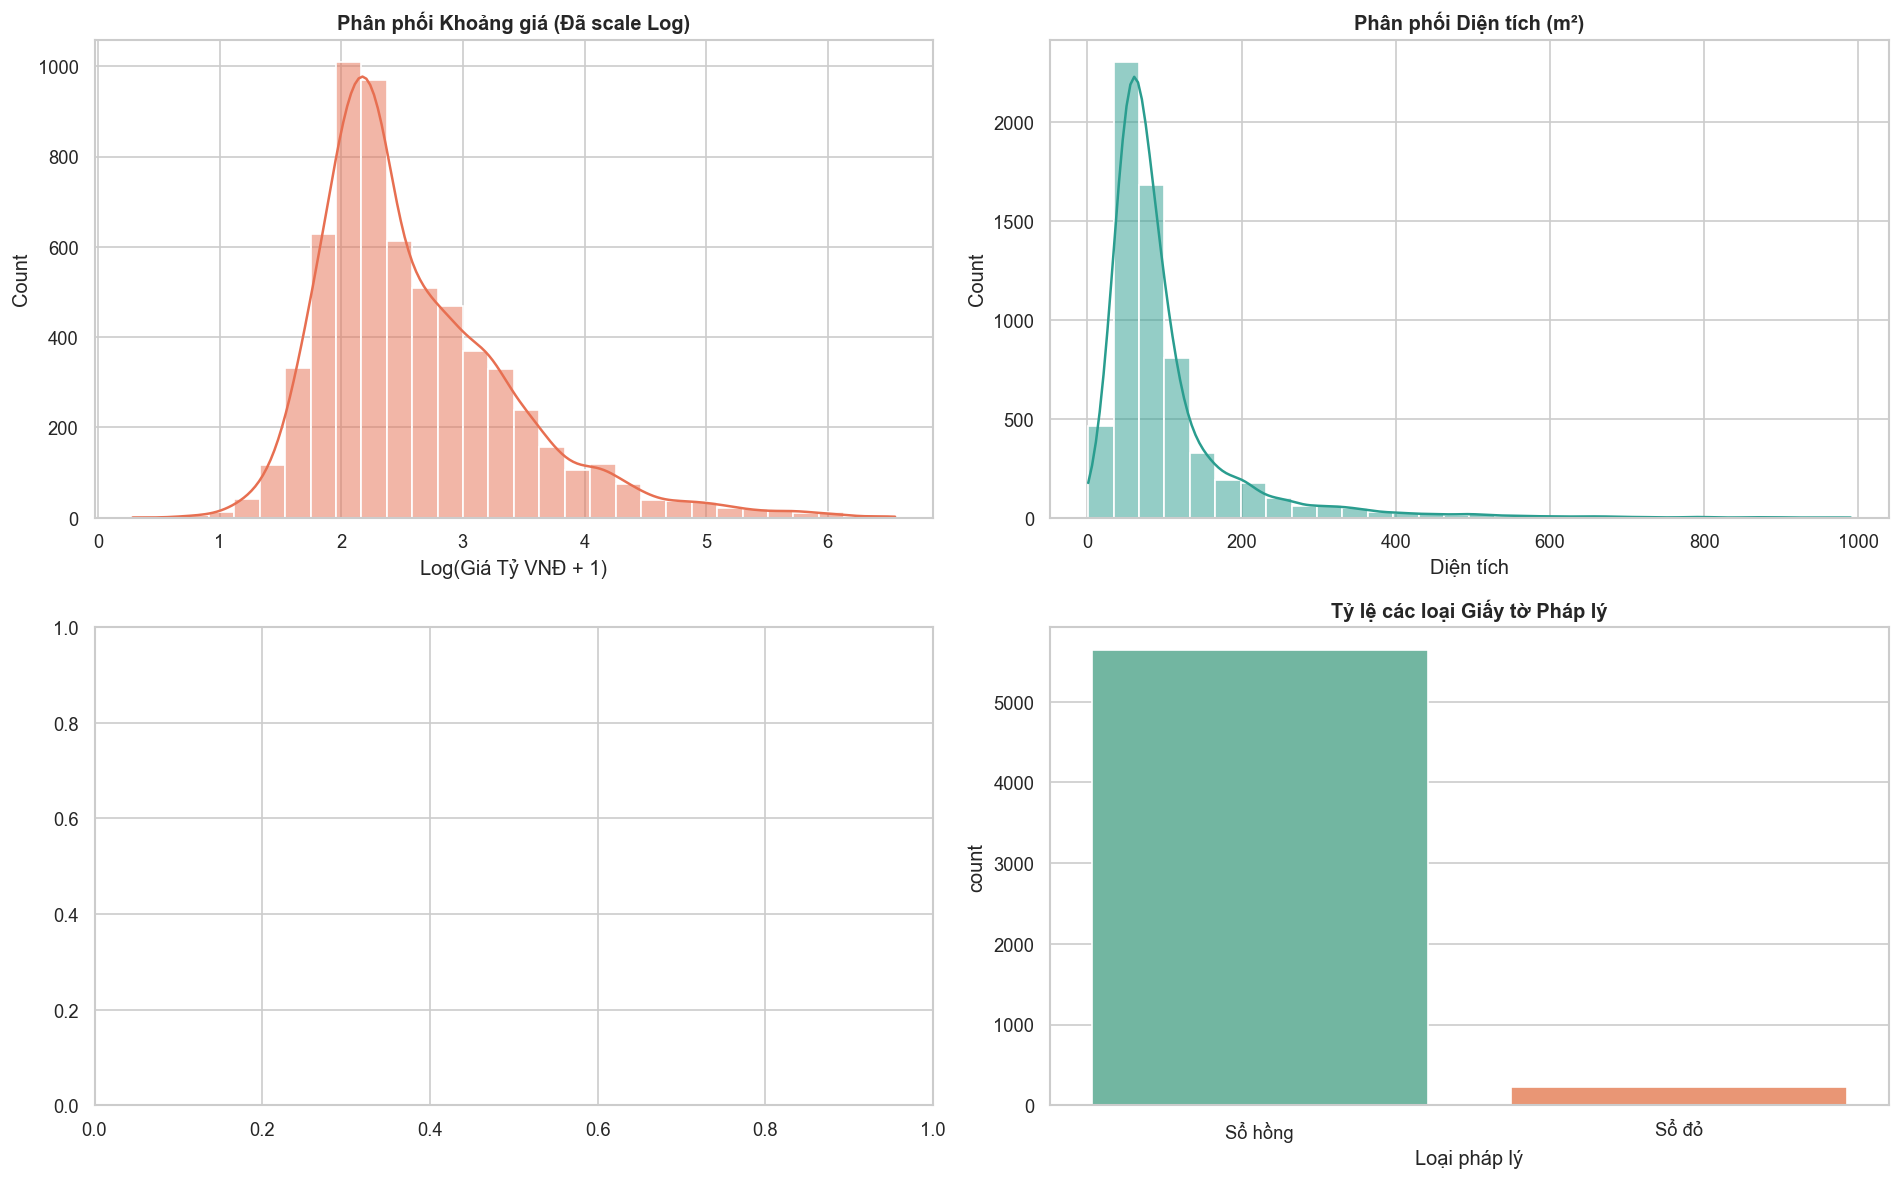


------------------------------------------------------------

--- [3] Phân tích sự ảnh hưởng của các yếu tố đến Giá Nhà ---


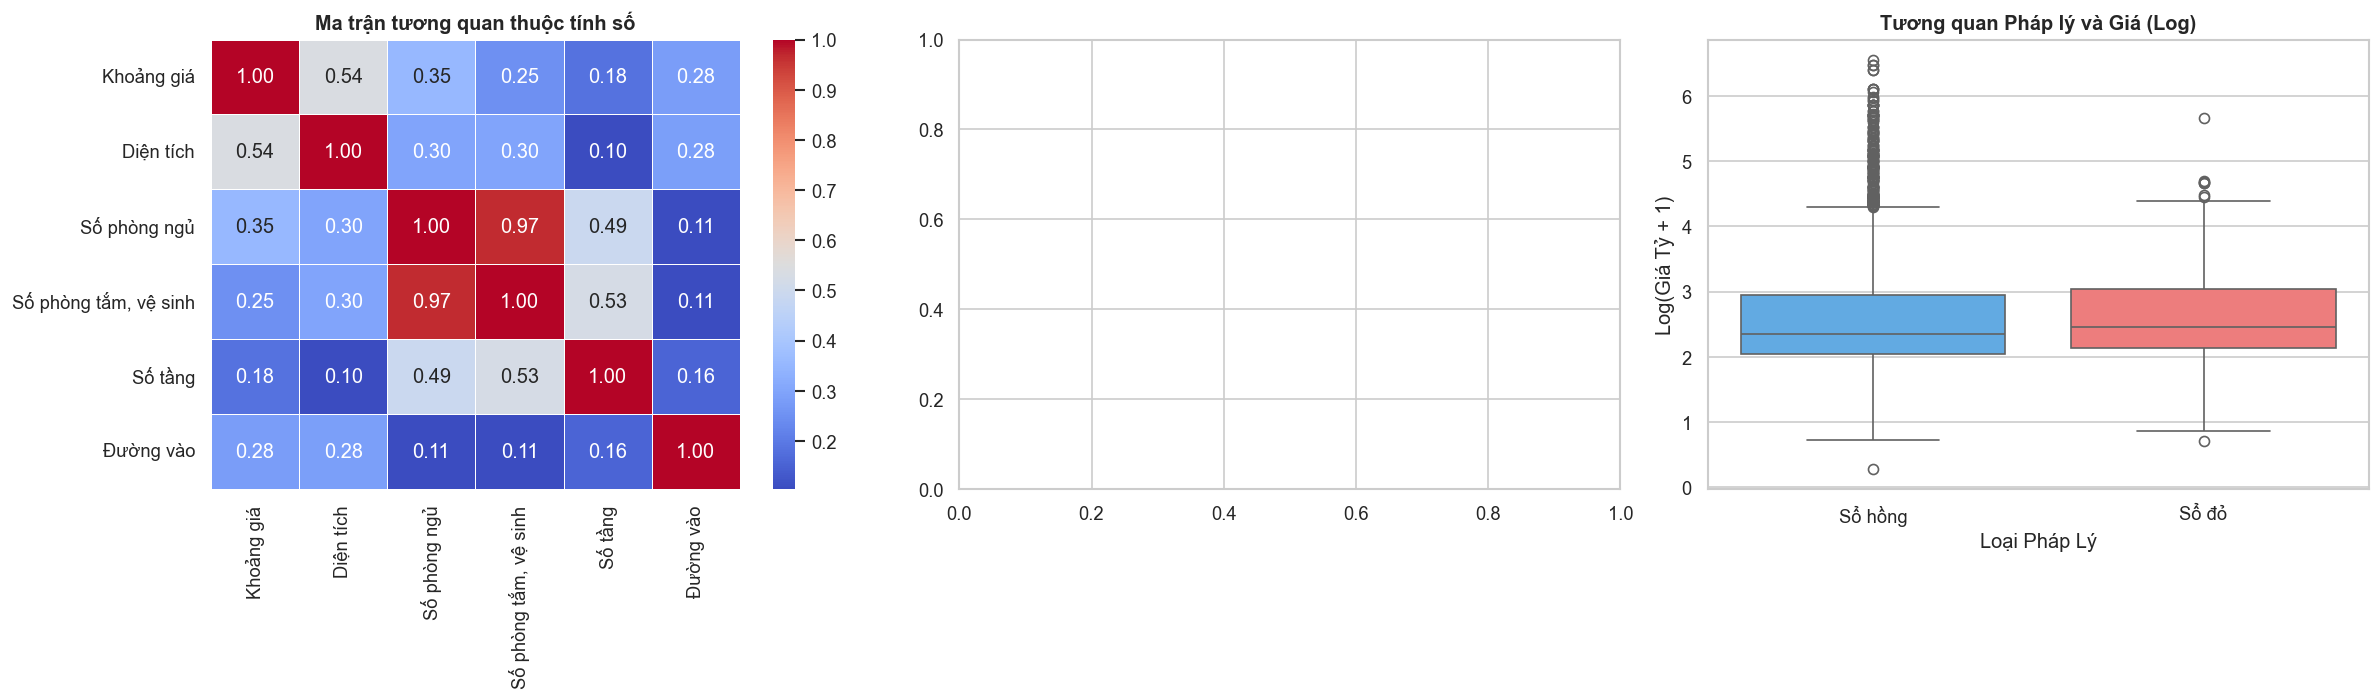

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị và đồ họa độ nét cao (DPI 100-150 là đủ nét và an toàn cho RAM)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print(f"{'='*20} BẮT ĐẦU KHÁM PHÁ DỮ LIỆU (EDA) {'='*20}\n")

# =====================================================================
# PHẦN 1: THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC KHÓA CHỐT
# =====================================================================
print(f"--- [1] Thống kê mô tả thuộc tính số học ---")
num_cols = ['Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào']
num_cols = [c for c in num_cols if c in df.columns]

display(df[num_cols].describe().T)
print("\n" + "-"*60 + "\n")


# =====================================================================
# TẠO BIẾN TẠM ĐỂ TRỰC QUAN HÓA GIÁ RÕ RÀNG HƠN (LOG TRANSFORMATION)
# =====================================================================
# Dùng log1p (log(1+x)) để xử lý dữ liệu lệch phải cực mạnh
df['Khoảng giá_log'] = np.log1p(df['Khoảng giá'])


# =====================================================================
# PHẦN 2: PHÂN TÍCH ĐƠN BIẾN (TRỰC QUAN HÓA DISTRIBUTION)
# =====================================================================
print(f"--- [2] Trực quan hóa Phân phối Biến Mục tiêu & Vị trí ---")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 2.1. Phân phối của Giá nhà đã biến đổi Logarit (Nhìn sẽ thành hình quả chuông rất đẹp)
sns.histplot(data=df, x='Khoảng giá_log', kde=True, ax=axes[0, 0], color='#e76f51', bins=30)
axes[0, 0].set_title('Phân phối Khoảng giá (Đã scale Log)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Log(Giá Tỷ VNĐ + 1)')

# 2.2. Phân phối của Diện tích
sns.histplot(data=df, x='Diện tích', kde=True, ax=axes[0, 1], color='#2a9d8f', bins=30)
axes[0, 1].set_title('Phân phối Diện tích (m²)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Diện tích')

# 2.3. Top các Quận Huyện có nhiều bất động sản nhất
if 'Quan_Huyen' in df.columns:
    sns.countplot(data=df, y='Quan_Huyen', ax=axes[1, 0], 
                  order=df['Quan_Huyen'].value_counts().index[:8], palette='Blues_r', hue='Quan_Huyen', legend=False)
    axes[1, 0].set_title('Top 8 Quận/Huyện có nhiều bài đăng nhất', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Quận/Huyện')

# 2.4. Tình trạng Pháp lý hiện tại
if 'Pháp lý' in df.columns:
    sns.countplot(data=df, x='Pháp lý', ax=axes[1, 1], palette='Set2', hue='Pháp lý', legend=False)
    axes[1, 1].set_title('Tỷ lệ các loại Giấy tờ Pháp lý', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Loại pháp lý')

plt.tight_layout()
plt.show()
print("\n" + "-"*60 + "\n")


# =====================================================================
# PHẦN 3: PHÂN TÍCH ĐA BIẾN (TƯƠNG QUAN ĐẾN GIÁ NHÀ)
# =====================================================================
print(f"--- [3] Phân tích sự ảnh hưởng của các yếu tố đến Giá Nhà ---")
# Nới rộng figure thành 1 hàng 3 cột
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3.1. Ma trận tương quan tuyến tính giữa các biến số
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[0])
axes[0].set_title('Ma trận tương quan thuộc tính số', fontsize=12, fontweight='bold')

# 3.2. Boxplot Biến động giá (dùng Log) tại Top 5 Quận/Huyện
if 'Quan_Huyen' in df.columns and 'Khoảng giá_log' in df.columns:
    top_districts = df['Quan_Huyen'].value_counts().index[:5]
    df_sub_qh = df[df['Quan_Huyen'].isin(top_districts)]
    
    sns.boxplot(data=df_sub_qh, x='Quan_Huyen', y='Khoảng giá_log', ax=axes[1], palette='Pastel1', hue='Quan_Huyen', legend=False)
    axes[1].set_title('Giá (Log) theo Top 5 Quận/Huyện', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Quận/Huyện')
    axes[1].set_ylabel('Log(Giá Tỷ + 1)')
    axes[1].tick_params(axis='x', rotation=15)

# 3.3. Tương quan giữa Sổ hồng/Sổ đỏ với Khoảng giá (Dùng Log để chống đè bẹp biểu đồ)
if 'Pháp lý' in df.columns and 'Khoảng giá_log' in df.columns:
    # Lọc lấy các dòng đúng chuẩn Sổ hồng hoặc Sổ đỏ
    df_phap_ly = df[df['Pháp lý'].isin(['Sổ hồng', 'Sổ đỏ'])].dropna(subset=['Khoảng giá_log'])
    
    sns.boxplot(data=df_phap_ly, x='Pháp lý', y='Khoảng giá_log', ax=axes[2], palette={'Sổ hồng': '#4dadf7', 'Sổ đỏ': '#ff6b6b'}, hue='Pháp lý', legend=False)
    axes[2].set_title('Tương quan Pháp lý và Giá (Log)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Loại Pháp Lý')
    axes[2].set_ylabel('Log(Giá Tỷ + 1)')

plt.tight_layout()
plt.show()

- Từ biểu đồ tương quan giữa loại sổ với log(giá tỷ + 1) thì việc không gộp "Sổ hồng" và "Sổ đỏ" thành "Có sổ" là hợp lý vì:
    - Sổ hồng: có một chuỗi các vòng tròn đen kéo dài miên man lên phía trên (đạt tới mức 6 trên thang Log). Điều này chứng tỏ nhóm "Sổ hồng" chứa cực kỳ nhiều bất động sản siêu cao cấp, giá trị khổng lồ.
    - Sổ đỏ: Phần râu (whisker) phía trên ngắn hơn nhiều và có rất ít điểm outliers (chỉ lên tới gần mức 5).
- Kết luận: Nếu gộp chung, mô hình sẽ không hiểu tại sao trong nhóm "Có sổ" lại có những căn nhà giá đột biến như vậy. Tách riêng giúp mô hình tự học được luật: "Nếu là Sổ hồng, xác suất căn nhà đó có giá siêu đắt sẽ cao hơn".
- Việc giữ lại tên loại sổ thực chất là đang giúp mô hình "ngầm" phân biệt được Loại hình bất động sản. Những dự án biệt thự/penthouse nghìn tỷ hiện nay 100% đều cấp Sổ hồng, đó là lý do giải thích cho cột outliers khổng lồ ở biểu đồ màu xanh.

# Bước này merge dữ liệu đã được trích xuất từ LLM đã được chạy ở ngoài vào. Nếu muốn trích xuất ngay trong cell code này thì bỏ qua bước này để chạy phần 4

In [24]:
df_llm = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/Đồ án/DS108/full_dataset_extracted.csv')
print(df_llm.columns)
print(df_llm.shape)

Index(['Link', 'Mô tả', 'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc',
       'gan_benh_vien', 'gan_cong_vien_ho_nuoc'],
      dtype='object')
(6072, 7)


In [25]:
import pandas as pd

print(f"Số lượng bản ghi của df trước khi join: {len(df)} dòng")

# Thực hiện INNER JOIN giữa df và df_llm bằng cột 'Link' và 'Mô tả'
df = pd.merge(df, df_llm, on=['Link', 'Mô tả'], how='inner')

print(f"Số lượng bản ghi của df sau khi INNER JOIN: {len(df)} dòng")

# Kiểm tra lại các cột của df sau khi join
print("\nCác cột của df sau khi join:")
print(df.columns)
print(df.shape)

Số lượng bản ghi của df trước khi join: 6381 dòng
Số lượng bản ghi của df sau khi INNER JOIN: 6076 dòng

Các cột của df sau khi join:
Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào', 'Khoảng giá_log', 'hem_xe_hoi', 'gan_cho_sieu_thi',
       'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc'],
      dtype='object')
(6076, 22)


## Trích xuất "Loại đường vào" từ "Mô tả"

In [26]:
def extract_loai_duong_vao(txt):
    """
    Hàm trích xuất Loại đường vào từ đoạn văn bản (mô tả bất động sản).
    Input: txt (string)
    Output: 'Mặt tiền', 'Hẻm ô tô', 'Hẻm xe máy' hoặc np.nan
    """
    # Xử lý trường hợp dữ liệu bị NaN hoặc không phải chuỗi
    if not isinstance(txt, str):
        return np.nan

    # Đưa về chữ thường để match regex chính xác hơn (tuỳ chọn nhưng rất khuyến nghị)
    txt = txt.lower()

    loai = np.nan
    
    # Kiểm tra mặt tiền / mặt phố
    if re.search(r'm[aặ]t ti[eề]n|nhà m[aặ]t ph[oố]|m[aặ]t ph[oố]', txt):
        loai = 'Mặt tiền'
        
    # Kiểm tra hẻm xe hơi / ô tô dựa trên keyword
    elif re.search(
        r'h[eẻ]m\s*(?:xe hơi|ô ?tô|2 xe quay đầu|hai xe|thông xe)'
        r'|ô ?tô\s*vào\s*nhà|xe hơi\s*vào\s*nhà', txt
    ):
        loai = 'Hẻm ô tô'
        
    # Nếu có chữ 'hẻm' nhưng không có keyword xe hơi, thử tìm độ rộng hẻm
    elif re.search(r'h[eẻ]m', txt):
        m_hem = re.search(r'h[eẻ]m(?:\s+\w+)?\s*([\d,\.]+)\s*m', txt)
        if m_hem:
            try:
                w = float(m_hem.group(1).replace(',', '.'))
                # Quy ước: hẻm >= 4m là hẻm ô tô, ngược lại là hẻm xe máy
                loai = 'Hẻm ô tô' if w >= 4 else 'Hẻm xe máy'
            except ValueError:
                pass
                
    return loai

# --- Ví dụ cách sử dụng ---
df['Loại đường vào'] = df['Mô tả'].apply(extract_loai_duong_vao)

## Trích xuất 'Đường', 'Phường', 'Quận' từ "Địa chỉ"

Lý do dùng Rule_base thay vì LLM: Cột địa chỉ trên trang web được viết theo một template cố định (vấn đề chỉ là thiếu thông tin hay không). Nếu sử dụng LLM chỉ khiến dư thừa và giảm hiệu quả.

In [27]:
# ════════════════════════════════════════════════
# CELL: PHÂN RÃ CỘT ĐỊA CHỈ → Đường / Phường / Quận
# ════════════════════════════════════════════════
import re
import pandas as pd
import numpy as np

def parse_address(addr):
    """
    Trích xuất Đường, Phường, Quận từ chuỗi địa chỉ.
    Bỏ qua số nhà (phần trước 'Đường') và thành phố (cuối chuỗi).
    """
    if pd.isna(addr):
        return pd.Series({'Đường': np.nan, 'Phường/Xã/Thị Trấn': np.nan, 'Quận': np.nan})

    # --- Đường ---
    duong = np.nan
    m = re.search(r'(Đường|Phố)\s+([^,]+)', addr)
    if m:
        # Sửa thành group(2) để lấy tên đường thực tế
        duong = m.group(2).strip()

    # --- Phường / Xã / Thị trấn ---
    phuong = np.nan
    m = re.search(r'(Phường|Xã|Thị trấn)\s+([^,]+)', addr)
    if m:
        phuong = m.group(2).strip()

    # --- Quận / Huyện / Thành phố (cấp quận) ---
    quan = np.nan
    m = re.search(r'(Quận|Huyện|Thành phố)\s+([^,]+)', addr)
    if m:
        quan = m.group(2).strip()

    return pd.Series({'Đường': duong, 'Phường/Xã/Thị Trấn': phuong, 'Quận': quan})


# Áp dụng hàm phân rã vào DataFrame
df[['Đường', 'Phường/Xã/Thị Trấn', 'Quận']] = df['Địa chỉ'].apply(parse_address)

# Kiểm tra kết quả
print(f"✅ Đã phân rã xong. Tỷ lệ null 3 cột mới:")
for col in ['Đường', 'Phường/Xã/Thị Trấn', 'Quận']:
    null_pct = df[col].isnull().mean() * 100
    print(f"   {col:18s}: {df[col].isnull().sum()} null ({null_pct:.1f}%)")

display(df[['Địa chỉ', 'Đường', 'Phường/Xã/Thị Trấn', 'Quận']].head(10))

✅ Đã phân rã xong. Tỷ lệ null 3 cột mới:
   Đường             : 416 null (6.8%)
   Phường/Xã/Thị Trấn: 0 null (0.0%)
   Quận              : 0 null (0.0%)


,Địa chỉ,Đường,Phường/Xã/Thị Trấn,Quận
0,"Đường Nguyễn Thượng Hiền, Phường 6, Quận Bình ...",Nguyễn Thượng Hiền,6,Bình Thạnh
1,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...",Đoàn Giỏi,Sơn Kỳ,Tân Phú
2,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",NaN,Long Hòa,Cần Giờ
3,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",NaN,Long Hòa,Cần Giờ
4,"The Manhattan Glory - Vinhomes Grand Park, Đườ...",Nguyễn Xiển,Long Bình,9
5,"Vinhomes Grand Park, Phường Long Thạnh Mỹ, Quậ...",NaN,Long Thạnh Mỹ,9
6,"Hẻm 869 , Đường Hoàng Sa, Phường 11, Quận 3, H...",Hoàng Sa,11,3
7,"Khu đô thị Vạn Phúc City, Đường Nguyễn Thị Nhu...",Nguyễn Thị Nhung,Hiệp Bình Phước,Thủ Đức
8,"Khu đô thị Vạn Phúc City, Đường Quốc Lộ 13, Ph...",Quốc Lộ 13,Hiệp Bình Phước,Thủ Đức
9,"Đường Phú Thuận, Phường Phú Thuận, Quận 7, Hồ ...",Phú Thuận,Phú Thuận,7


Thông tin về Quận bị thiếu quá nhiều. Sửa dụng dữ liệu từ web quy hoạch để lấp vào. Ưu tiên dữ liệu từ địa chỉ vì dữ liệu ở đây đáng tin cậy hơn, còn dữ liệu từ toạ độ gps thì có thể có sai số.

In [28]:
print(df.columns)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào', 'Khoảng giá_log', 'hem_xe_hoi', 'gan_cho_sieu_thi',
       'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc', 'Đường',
       'Phường/Xã/Thị Trấn', 'Quận'],
      dtype='object')


# 2. Làm sạch dữ liệu (missing value và outlier)

## 2.1 Thống kê và xử lý sơ bộ.

Thống kê số lượng missing value ở từng cột.

In [29]:
import pandas as pd

# 1. Tính số lượng và tỷ lệ % missing
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# 2. Gộp lại thành một DataFrame thống kê
missing_stats = pd.concat([missing_count, missing_percent], axis=1, keys=['Missing Count', 'Missing Percentage (%)'])

# 3. Lọc bỏ các cột không có missing và sắp xếp giảm dần
missing_stats = missing_stats[missing_stats['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

# 4. Trực quan hóa bằng thanh màu (style bar) để dễ quan sát
if not missing_stats.empty:
    print(f"Tổng số cột bị khuyết dữ liệu: {len(missing_stats)} / {df.shape[1]}")
    display(missing_stats.style.bar(subset=['Missing Percentage (%)'], color='#ff6b6b').format({'Missing Percentage (%)': '{:.2f}%'}))
else:
    print("Tuyệt vời! Dữ liệu hoàn toàn sạch sẽ, không có missing value nào.")

Tổng số cột bị khuyết dữ liệu: 14 / 25


,Missing Count,Missing Percentage (%)
Hướng ban công,5411,89.06%
Hướng nhà,4851,79.84%
Nội thất,2770,45.59%
Đường vào,2360,38.84%
Loại đường vào,2344,38.58%
"Số phòng tắm, vệ sinh",1520,25.02%
Số phòng ngủ,1255,20.66%
Pháp lý,490,8.06%
Số tầng,431,7.09%
Đường,416,6.85%


Xoá các bản ghi bị thiếu kinh độ và vĩ độ

In [30]:
# 1. In ra kích thước tập dữ liệu trước khi xử lý để đối chiếu
print(f"📊 Kích thước df TRƯỚC khi xóa: {df.shape}")

# 2. Xóa các dòng chứa NaN ở 1 trong 2 cột 'Latitude' hoặc 'Longitude'
df = df.dropna(subset=['Latitude', 'Longitude'])

# 3. Kiểm tra lại kết quả sau khi xóa
print("-" * 50)
print(f"✅ Đã xóa thành công các dòng thiếu kinh độ, vĩ độ!")
print(f"📊 Kích thước df SAU khi xóa : {df.shape}")
print(f"🔍 Số lượng missing còn lại ở Latitude : {df['Latitude'].isnull().sum()}")
print(f"🔍 Số lượng missing còn lại ở Longitude: {df['Longitude'].isnull().sum()}")

📊 Kích thước df TRƯỚC khi xóa: (6076, 25)
--------------------------------------------------
✅ Đã xóa thành công các dòng thiếu kinh độ, vĩ độ!
📊 Kích thước df SAU khi xóa : (6075, 25)
🔍 Số lượng missing còn lại ở Latitude : 0
🔍 Số lượng missing còn lại ở Longitude: 0


Xoá cột 'Hướng ban công' và 'Hướng nhà'

In [31]:
df = df.drop(columns=['Hướng ban công', 'Hướng nhà'])

Xoá các bản ghi có 'Khoảng giá' bị nan

In [32]:
# 1. In số lượng dòng hiện tại để đối chiếu
print(f"Số dòng trước khi xóa: {len(df)}")

# 2. Thực hiện xóa các dòng bị NaN ở riêng cột 'Khoảng giá'
df.dropna(subset=['Khoảng giá'], inplace=True)

# 3. Khôi phục (reset) lại index cho liền mạch sau khi các dòng bị rút ruột
df.reset_index(drop=True, inplace=True)

# 4. Kiểm tra lại kết quả
print(f"Số dòng sau khi xóa: {len(df)}")
print(f"Số lượng NaN hiện tại trong cột 'Khoảng giá': {df['Khoảng giá'].isnull().sum()}")

Số dòng trước khi xóa: 6075
Số dòng sau khi xóa: 5997
Số lượng NaN hiện tại trong cột 'Khoảng giá': 0


Thống kê trên box plot để tìm outlier.

📊 ĐANG VẼ 14 CỘT DỮ LIỆU DẠNG SỐ (TÌM OUTLIERS)...
------------------------------------------------------------


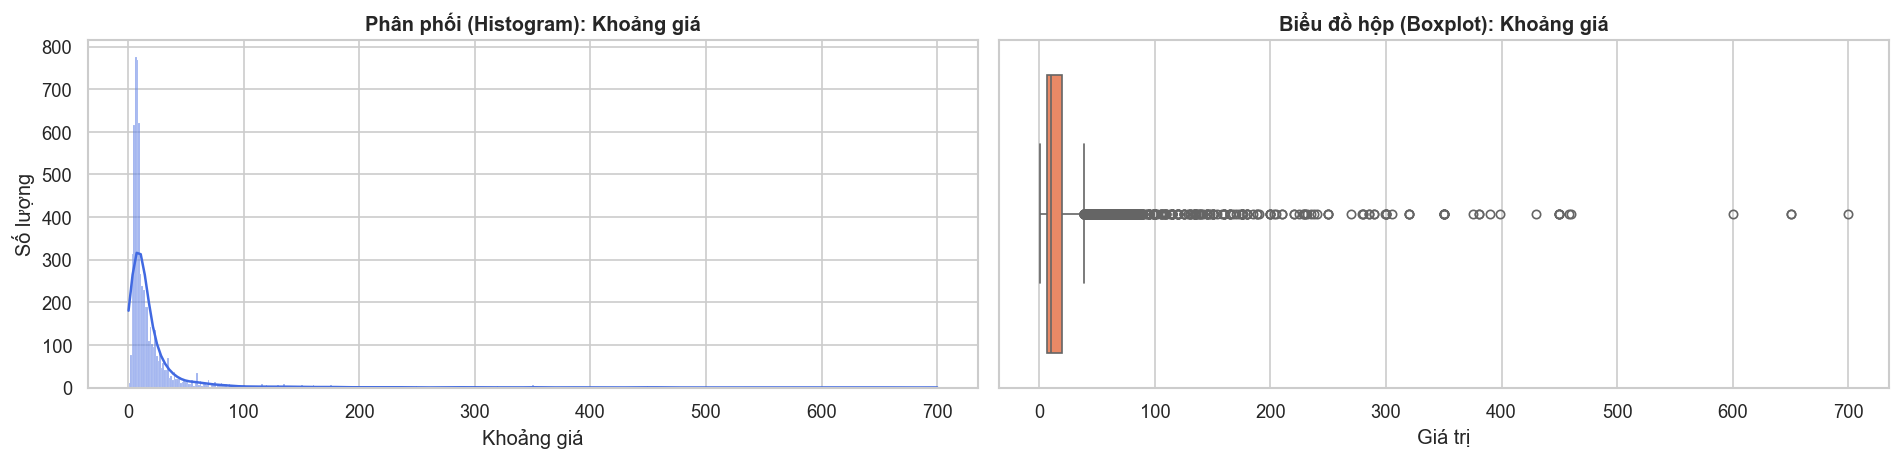

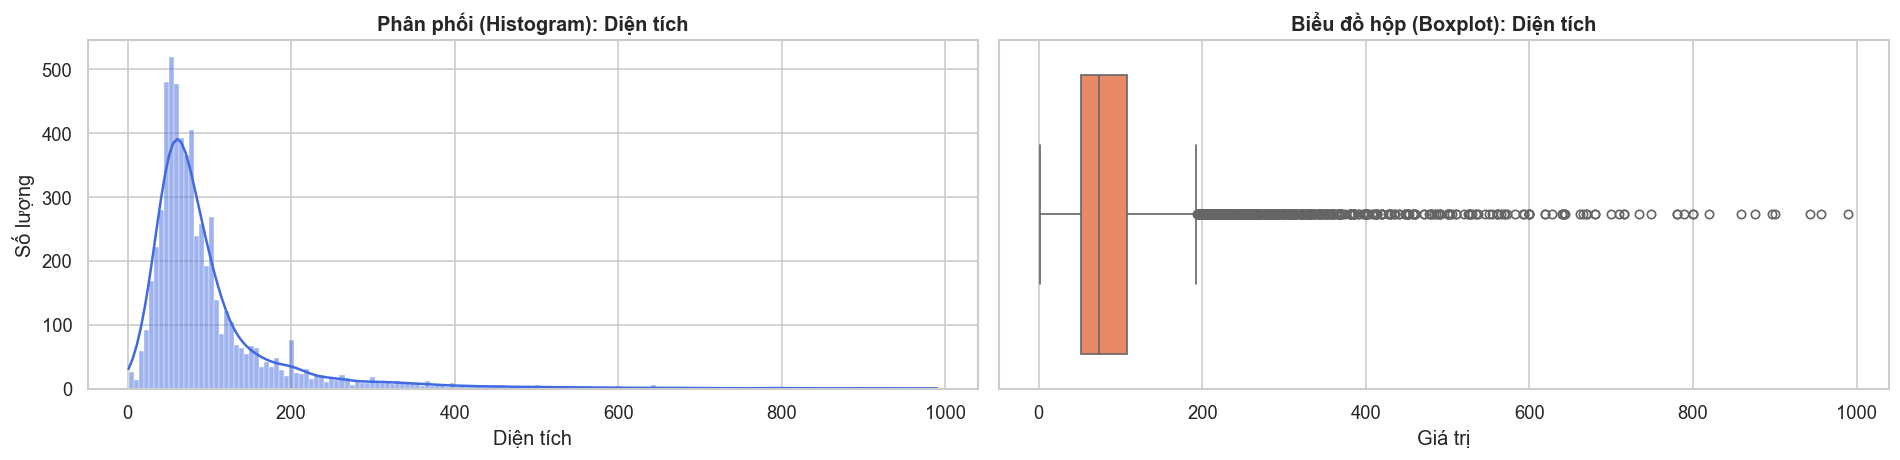

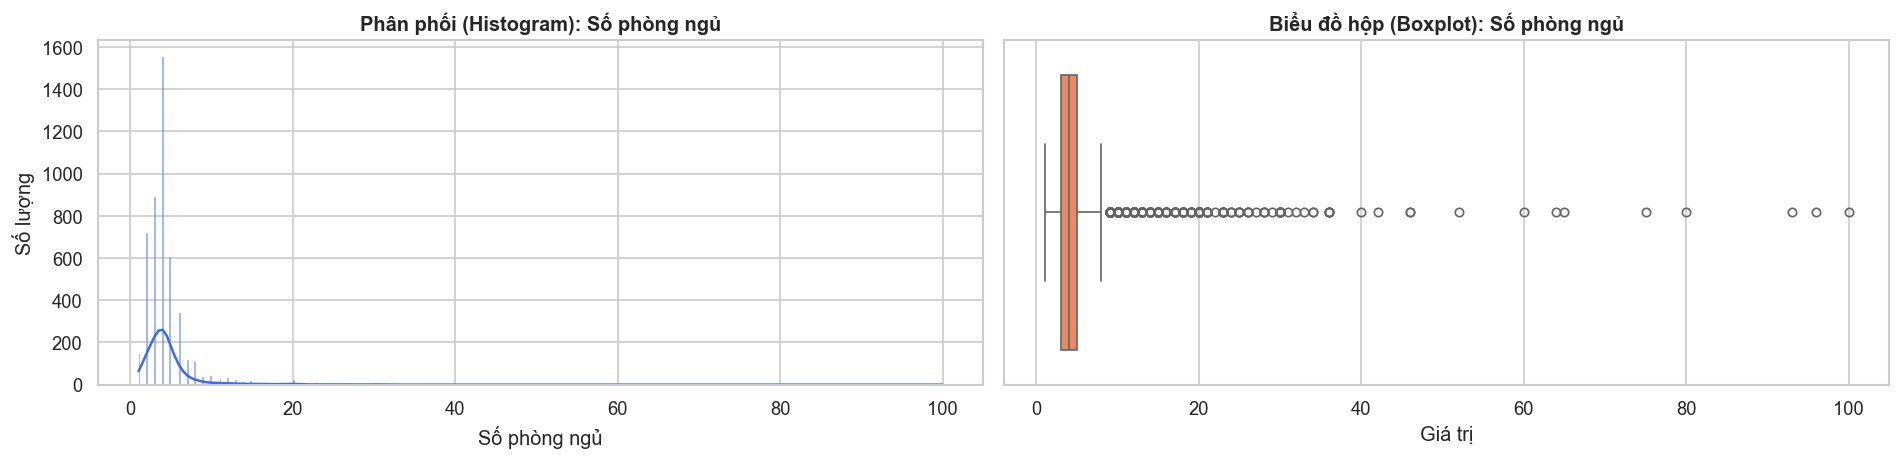

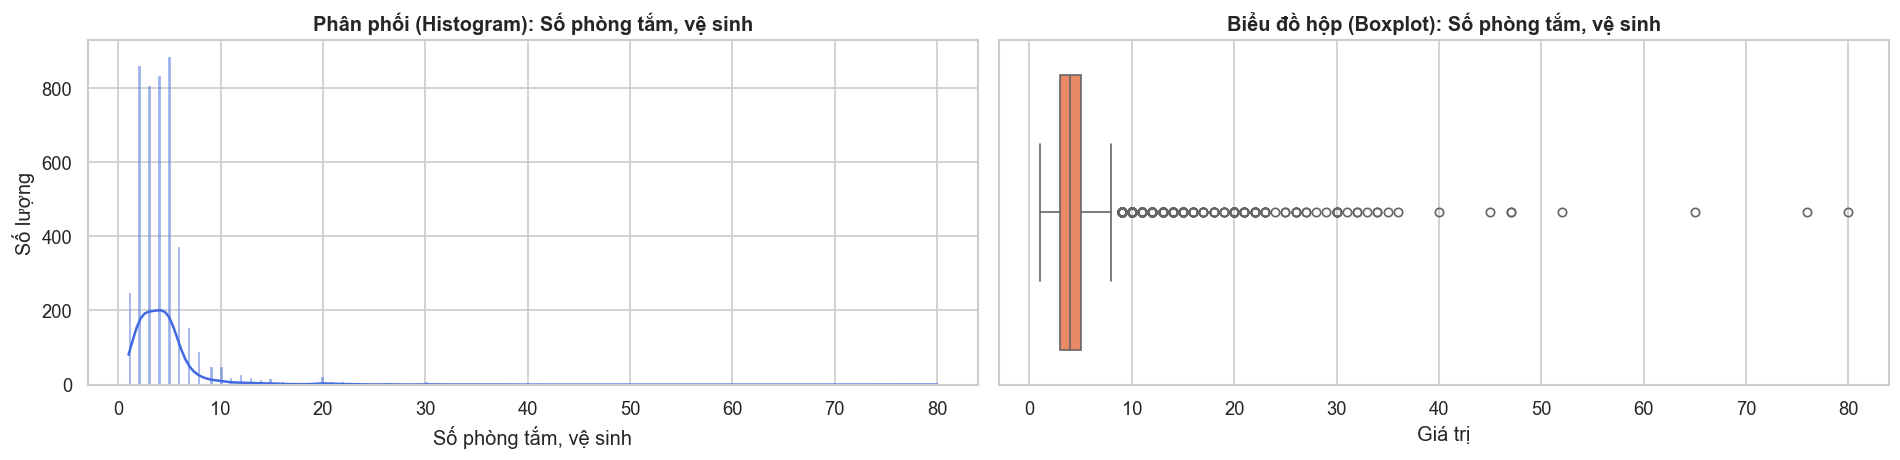

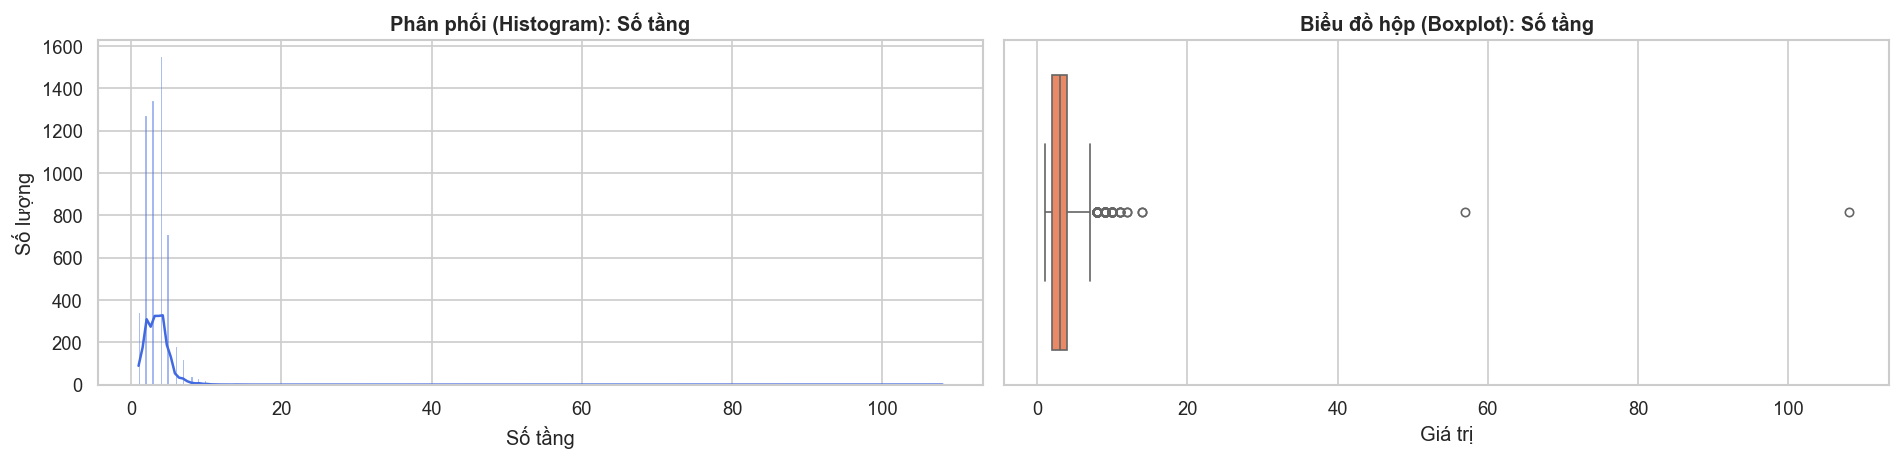

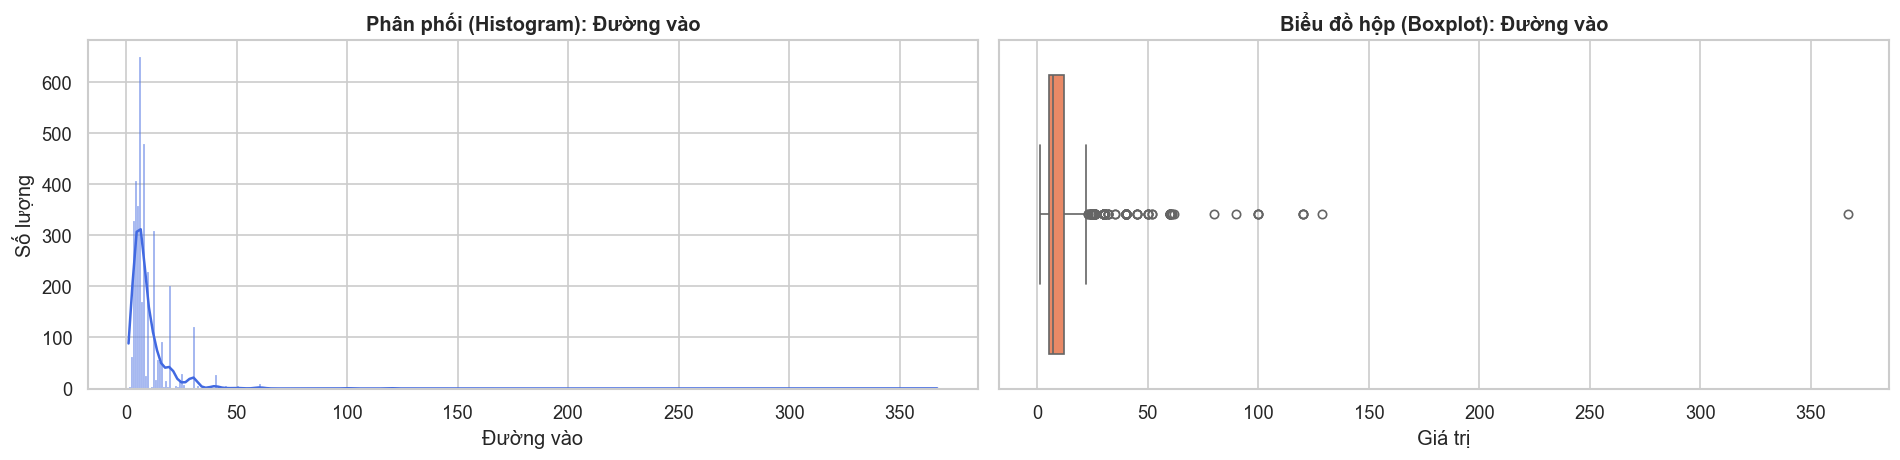

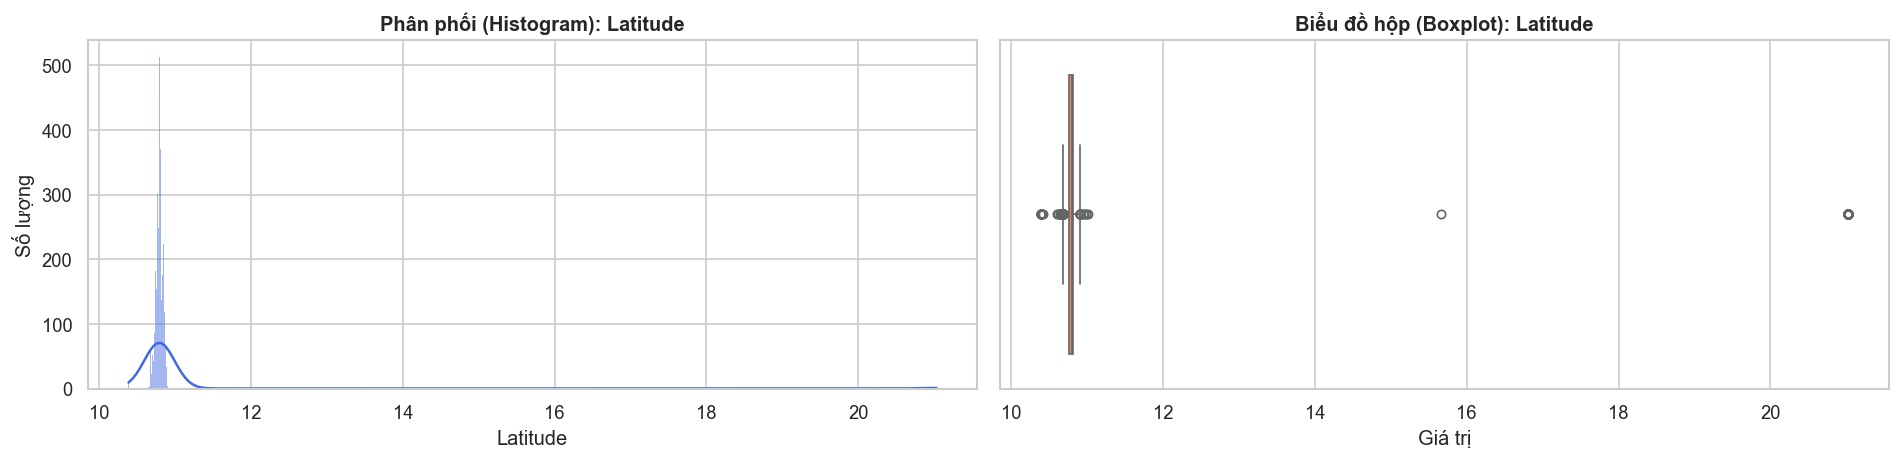

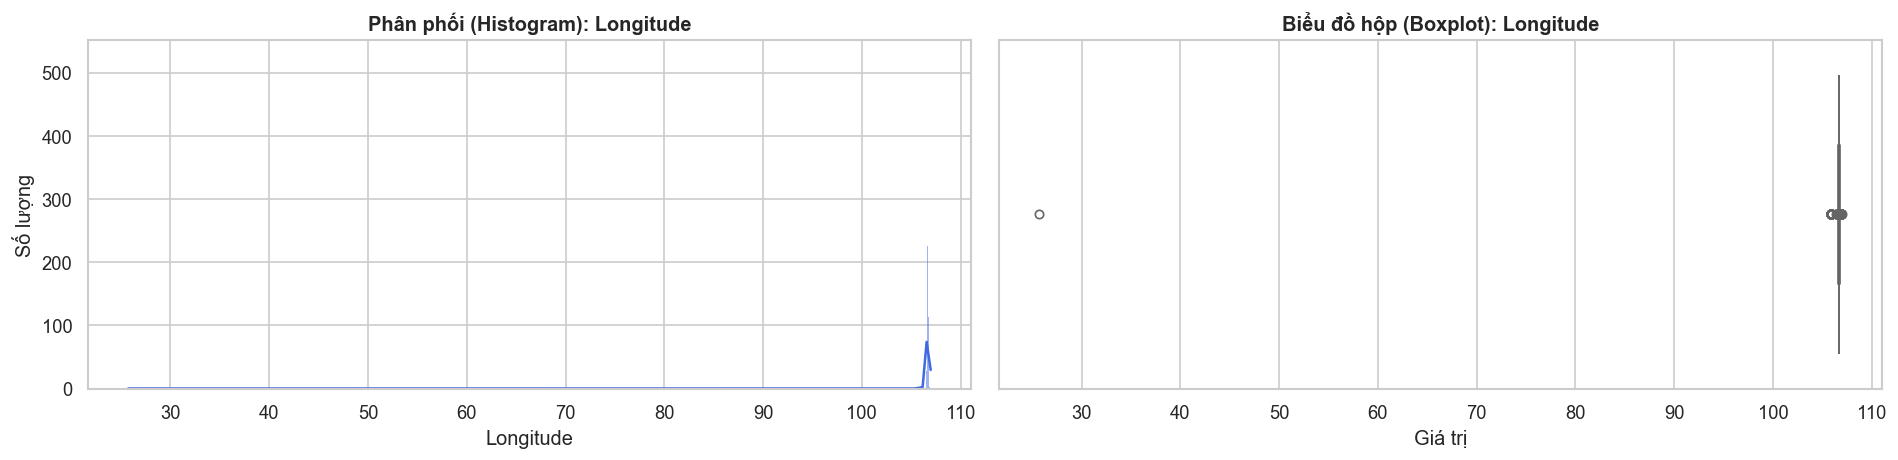

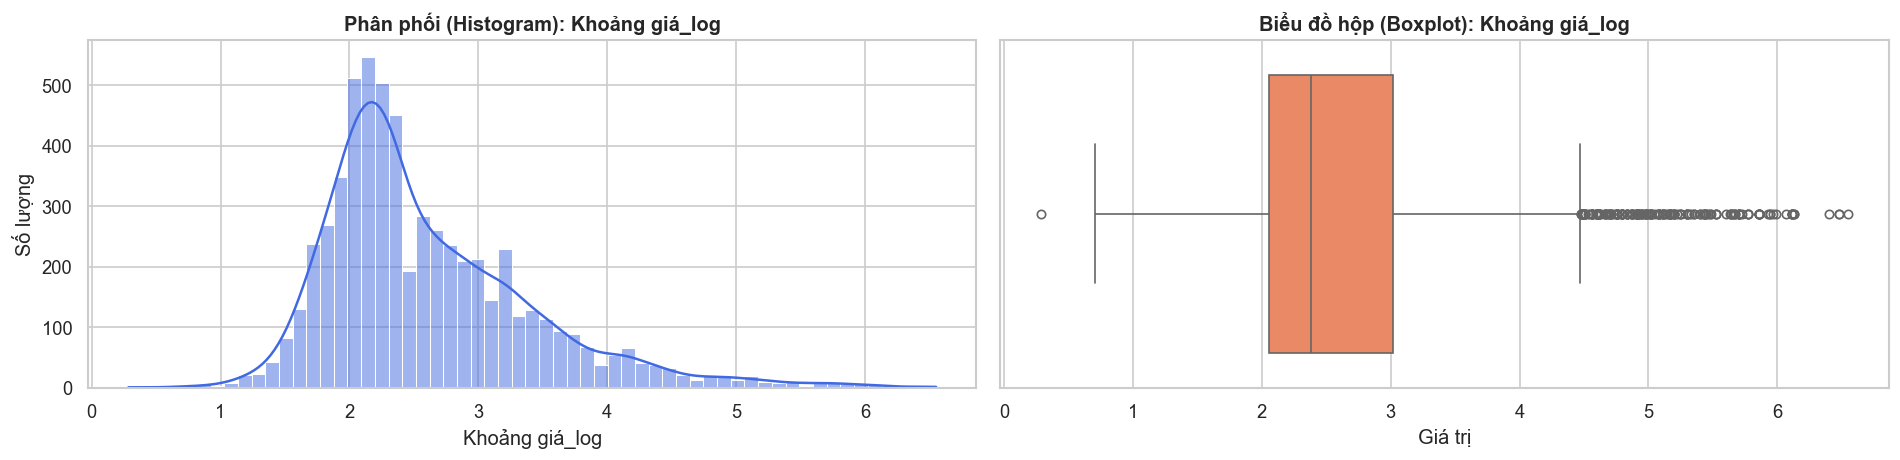

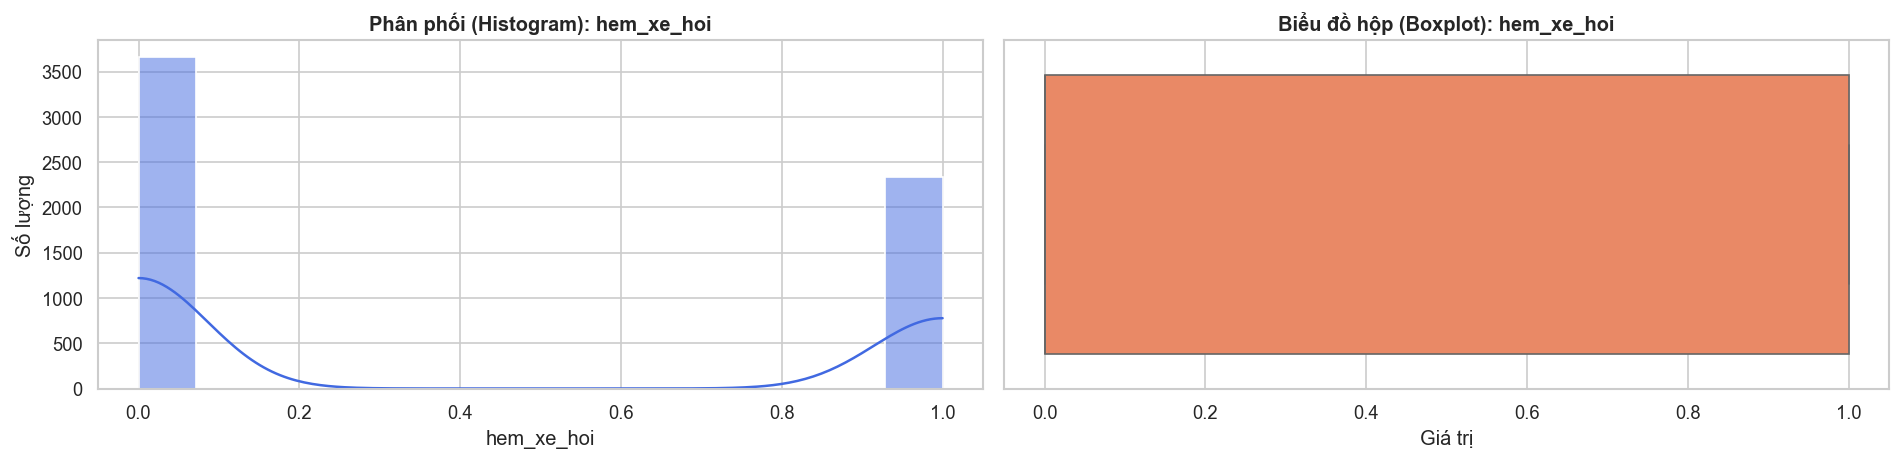

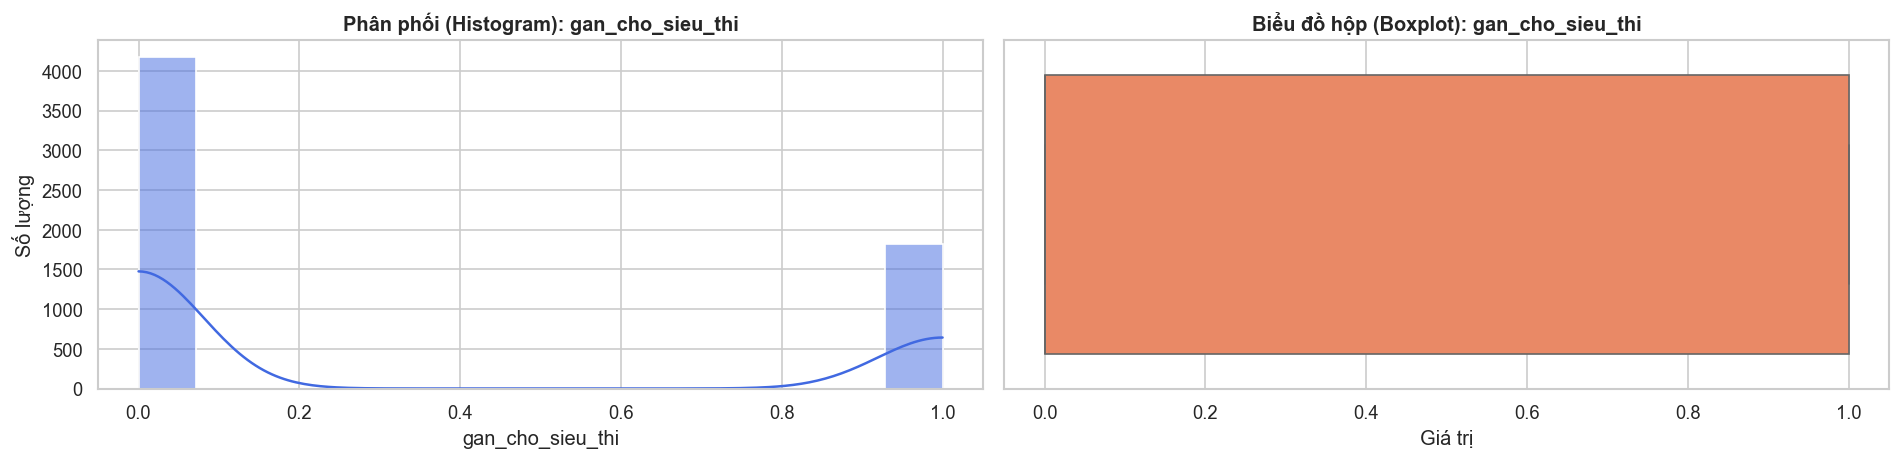

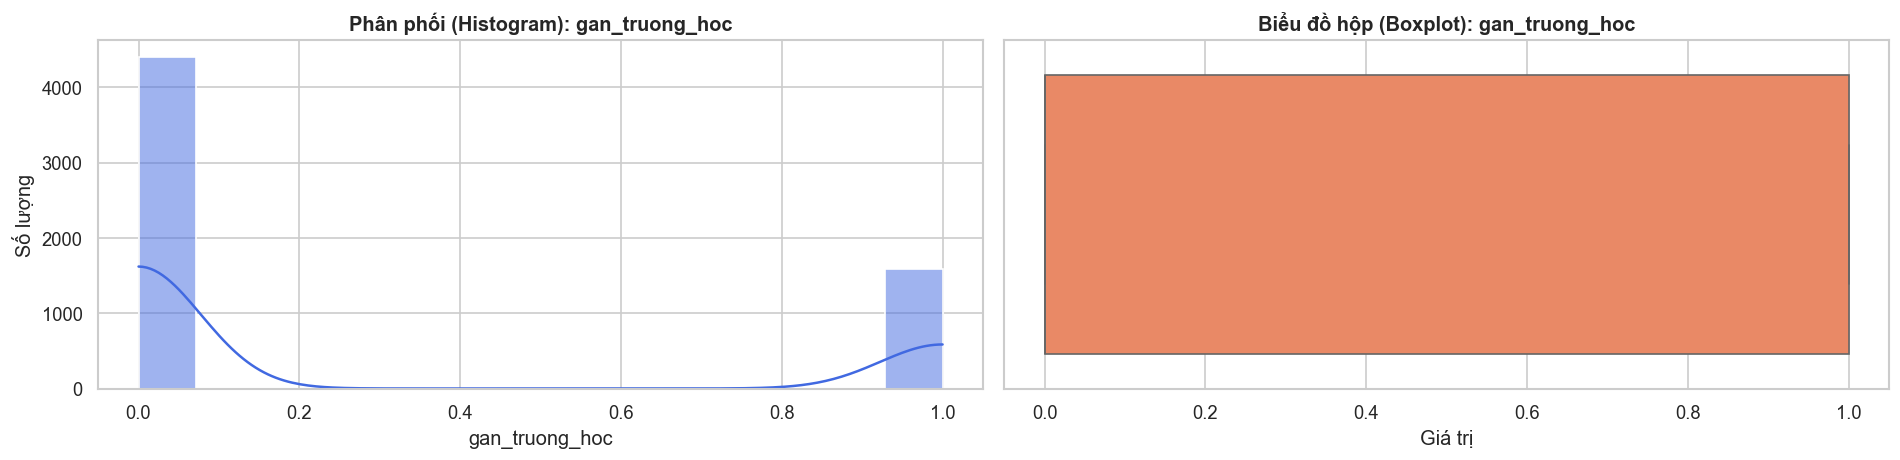

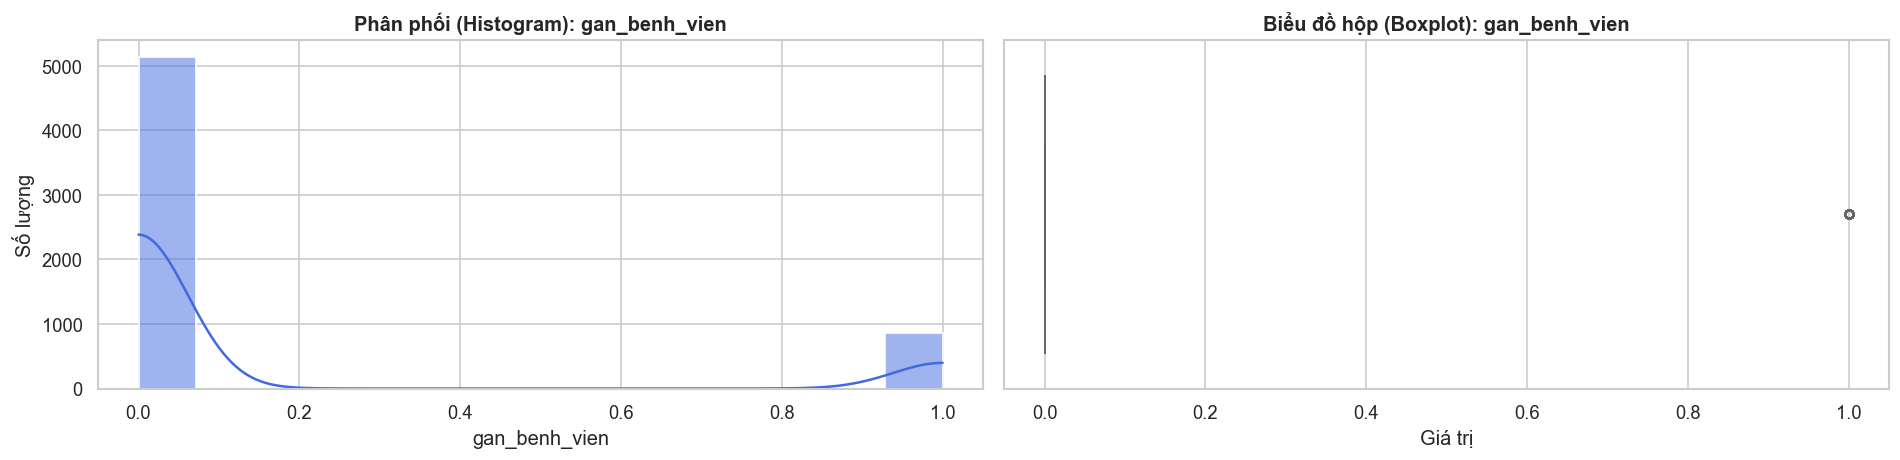

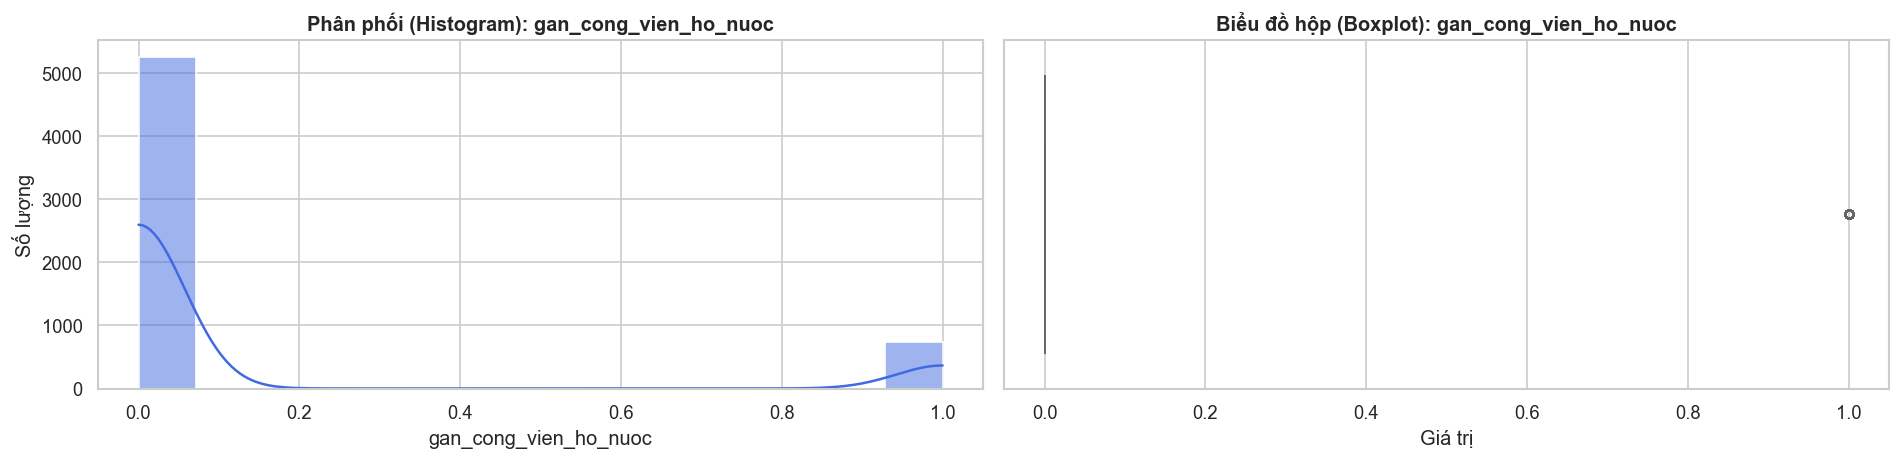

📝 ĐANG VẼ 6 BIẾN PHÂN LOẠI CẦN THIẾT...
------------------------------------------------------------


/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/2238182946.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


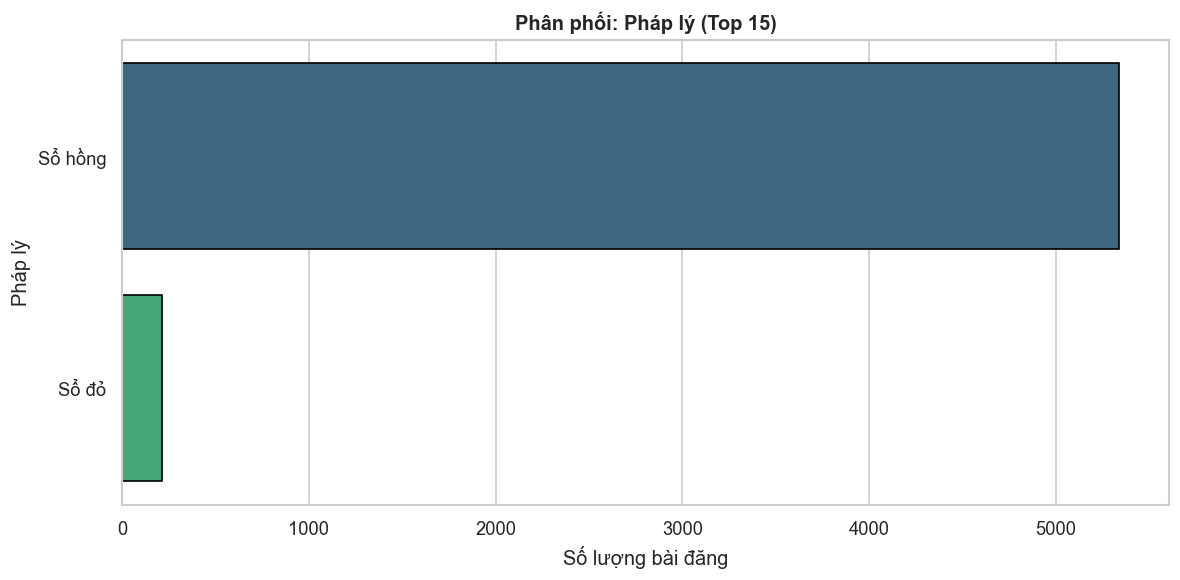

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/2238182946.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


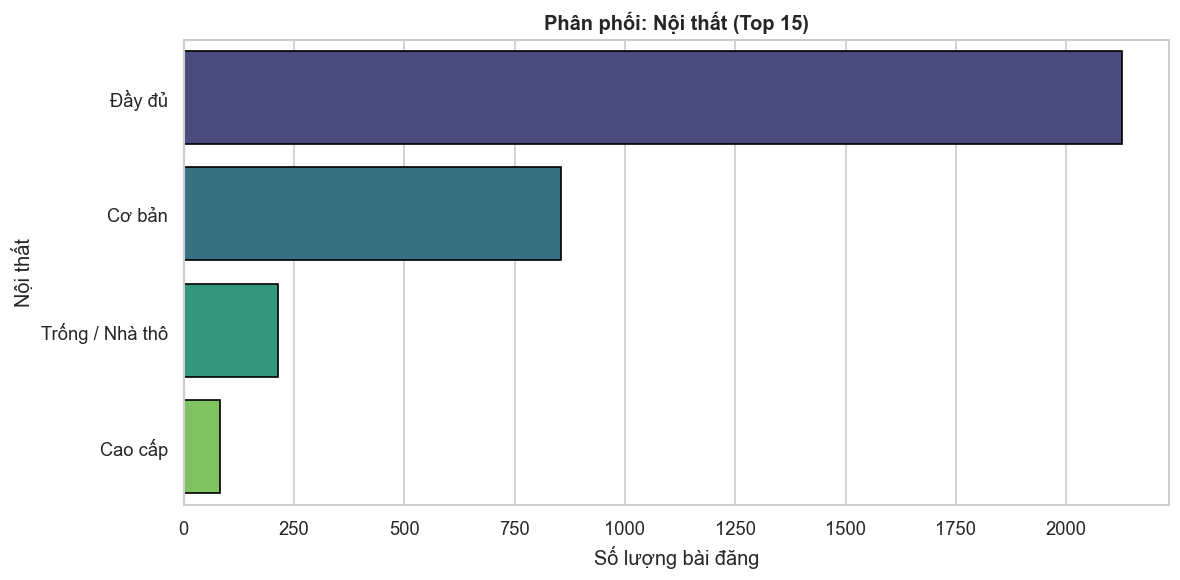

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/2238182946.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


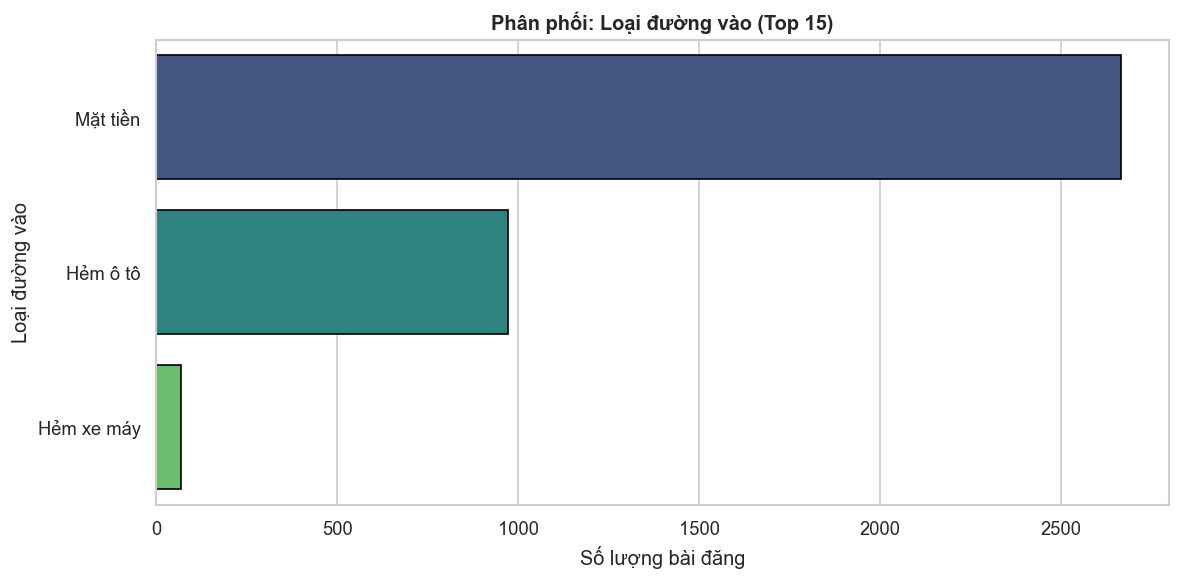

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/2238182946.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


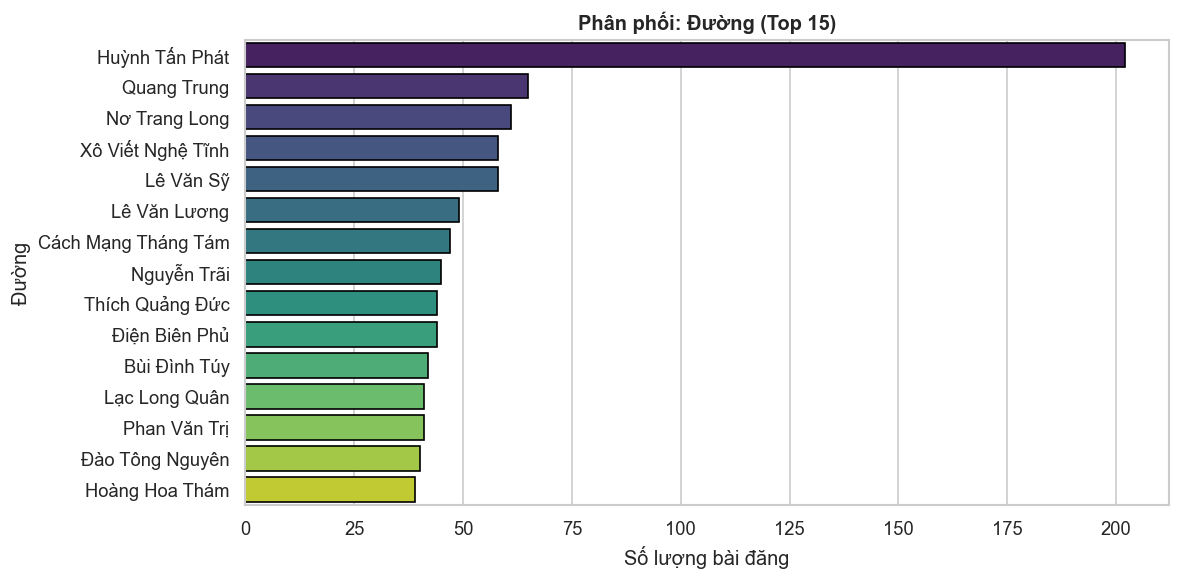

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/2238182946.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


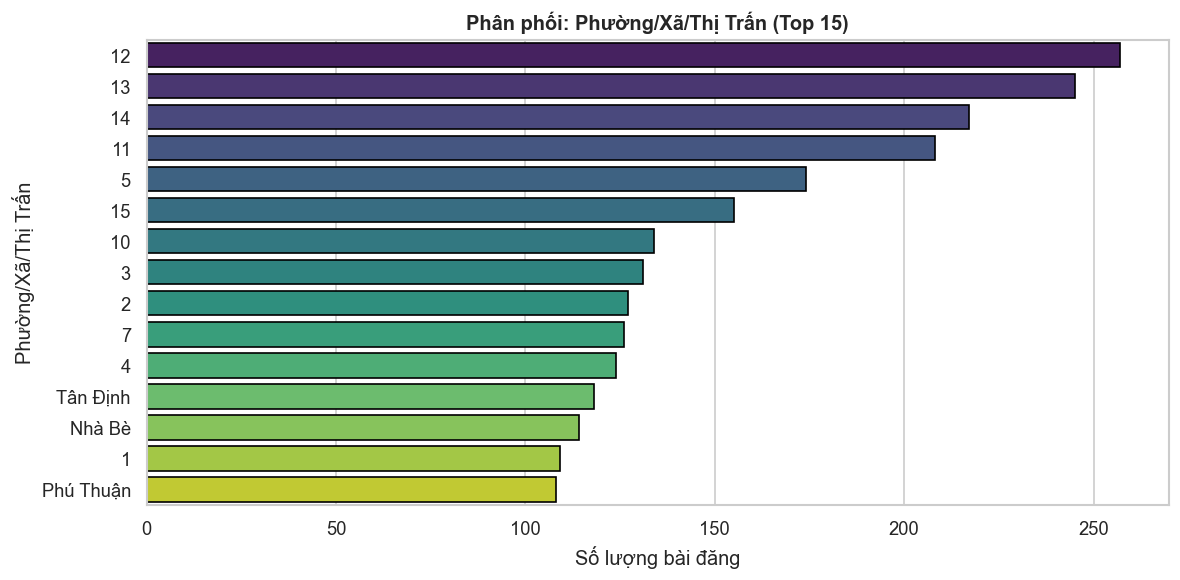

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/2238182946.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


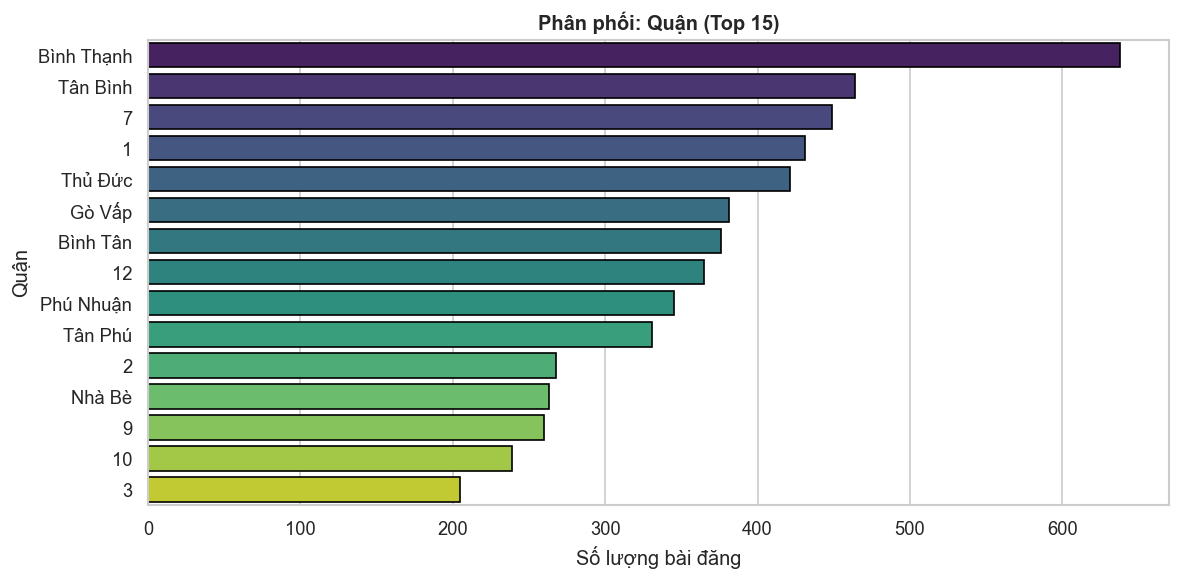

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tách riêng các cột dạng Số và dạng Chữ (Phân loại)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# ---------------------------------------------------------
# PHẦN 1: VẼ CỘT DỮ LIỆU SỐ (NUMERICAL) - Tìm Outliers
# ---------------------------------------------------------
print(f"📊 ĐANG VẼ {len(num_cols)} CỘT DỮ LIỆU DẠNG SỐ (TÌM OUTLIERS)...")
print("-" * 60)

for col in num_cols:
    # Bỏ qua các giá trị NaN khi vẽ để tránh lỗi
    data_clean = df[col].dropna()
    
    # Khởi tạo khung hình với 2 biểu đồ cạnh nhau (Histogram bên trái, Boxplot bên phải)
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    # Biểu đồ 1: Histogram (Xem hình dáng phân phối)
    sns.histplot(data_clean, kde=True, ax=axes[0], color='royalblue', edgecolor='white')
    axes[0].set_title(f'Phân phối (Histogram): {col}', fontweight='bold')
    axes[0].set_ylabel('Số lượng')
    
    # Biểu đồ 2: Boxplot (Chuyên gia soi Outliers)
    sns.boxplot(x=data_clean, ax=axes[1], color='coral', fliersize=5)
    axes[1].set_title(f'Biểu đồ hộp (Boxplot): {col}', fontweight='bold')
    axes[1].set_xlabel('Giá trị')
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# PHẦN 2: VẼ CỘT DỮ LIỆU CHỮ (CATEGORICAL) - Tìm lỗi nhập liệu
# ---------------------------------------------------------
cat_cols_to_plot = ['Pháp lý', 'Nội thất', 'Loại đường vào', 'Đường', 'Phường/Xã/Thị Trấn', 'Quận']  # Chọn các cột phân loại quan trọng để vẽ

# 2. Kiểm tra xem các cột này có thực sự tồn tại trong DataFrame không để tránh lỗi
cols_exist = [col for col in cat_cols_to_plot if col in df.columns]

if len(cols_exist) > 0:
    print(f"📝 ĐANG VẼ {len(cols_exist)} BIẾN PHÂN LOẠI CẦN THIẾT...")
    print("-" * 60)
    
    for col in cols_exist:
        # Bỏ qua NaN để đếm chính xác, nhưng nếu muốn hiện cả số lượng Missing, hãy thay bằng: df[col].fillna('Missing')
        data_clean = df[col].dropna()
        
        if len(data_clean) > 0:
            plt.figure(figsize=(10, 5))
            
            # Chỉ lấy top 15 giá trị phổ biến nhất để biểu đồ sạch sẽ
            top_categories = data_clean.value_counts().nlargest(15).index
            
            sns.countplot(
                y=data_clean, 
                order=top_categories, 
                palette='viridis', 
                edgecolor='black'
            )
            
            plt.title(f'Phân phối: {col} (Top 15)', fontweight='bold')
            plt.xlabel('Số lượng bài đăng')
            plt.ylabel(col)
            
            # Tinh chỉnh lại layout cho đẹp
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️ Cột '{col}' không có dữ liệu hợp lệ để vẽ.")
else:
    print("Không tìm thấy các cột phân loại yêu cầu trong DataFrame.")

In [34]:
print(df.columns)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất',
       'Latitude', 'Longitude', 'Mô tả', 'Loại đường vào', 'Khoảng giá_log',
       'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'Đường', 'Phường/Xã/Thị Trấn', 'Quận'],
      dtype='object')


### Chia train/test (Tránh Data Leakage)

In [35]:
from sklearn.model_selection import train_test_split

target_col = 'Khoảng giá' 

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# In kết quả kiểm tra
print("✅ Đã chia tách dữ liệu thành công!")
print("-" * 50)
print(f"Tập Huấn luyện (Train) : X={X_train.shape}, y={y_train.shape}")
print(f"Tập Kiểm thử (Test)    : X={X_test.shape},  y={y_test.shape}")

✅ Đã chia tách dữ liệu thành công!
--------------------------------------------------
Tập Huấn luyện (Train) : X=(4797, 22), y=(4797,)
Tập Kiểm thử (Test)    : X=(1200, 22),  y=(1200,)


Ma trận tương quan trước khi xử lý

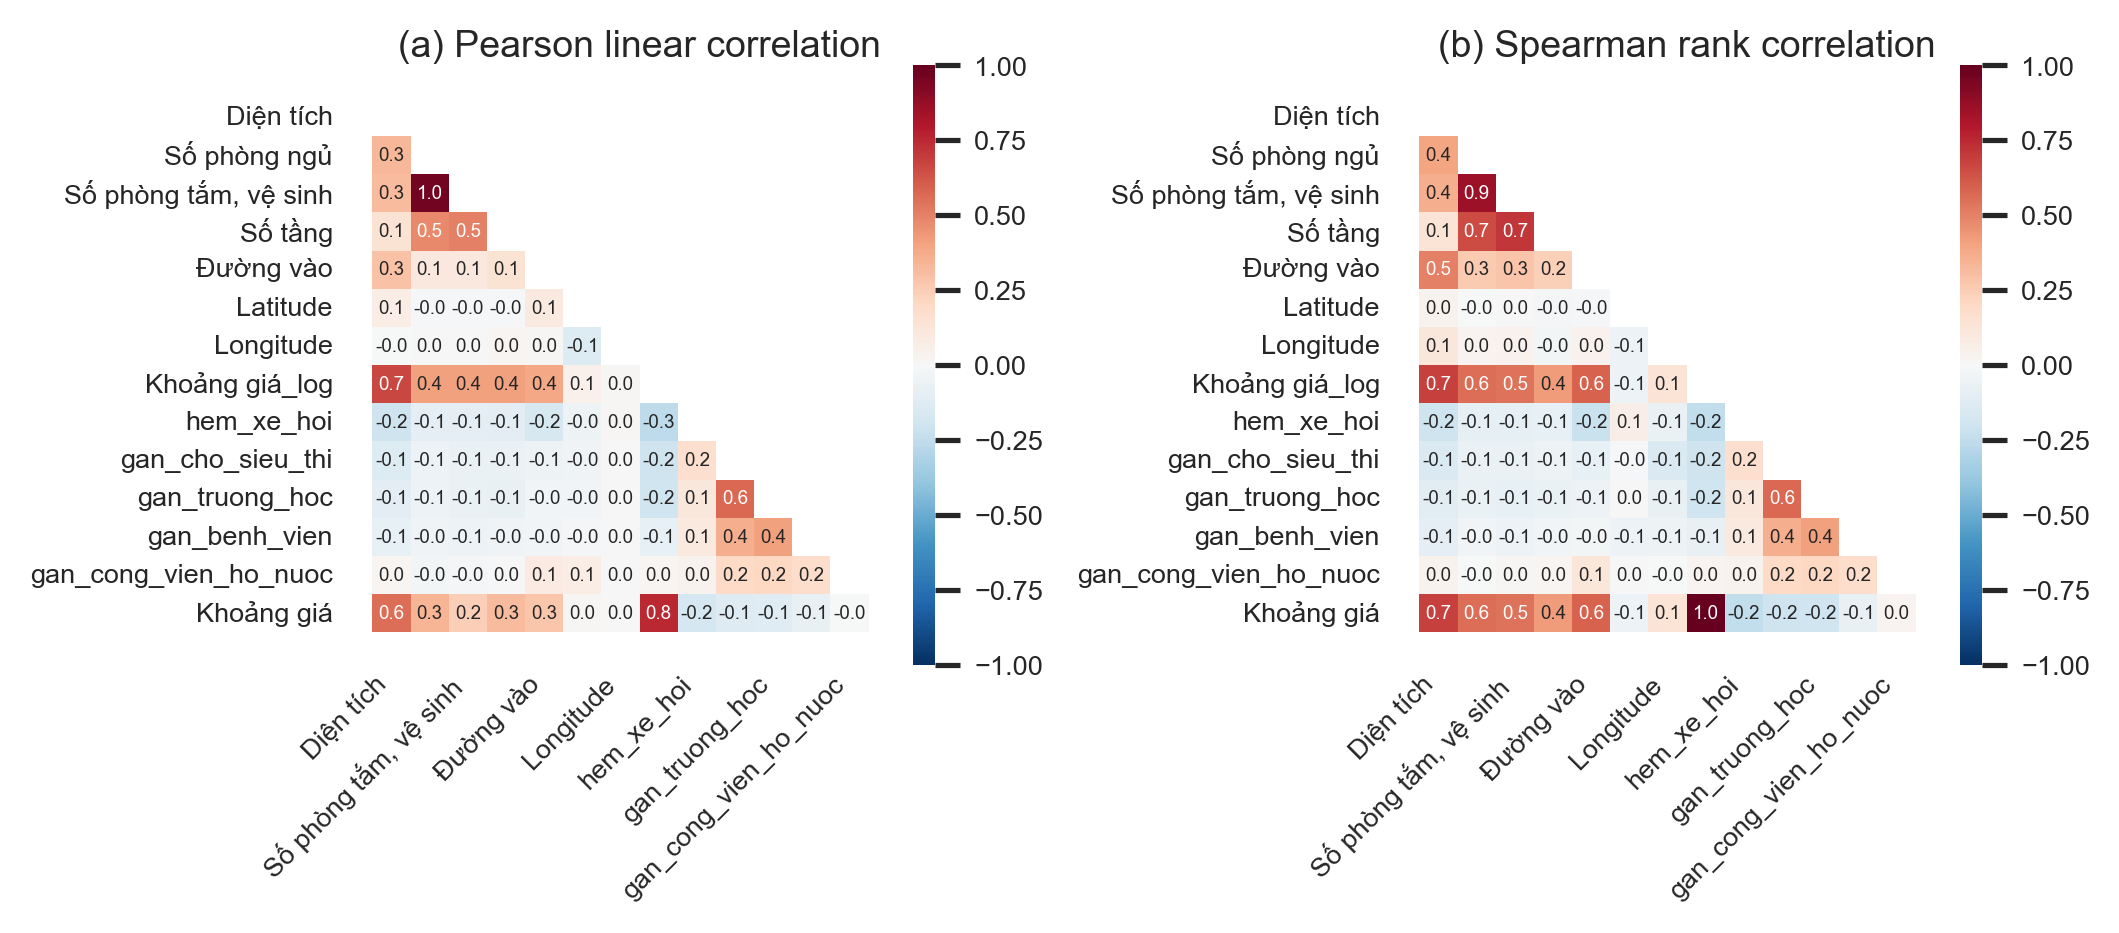

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ghép và chuẩn bị dữ liệu
train_data = pd.concat([X_train, y_train], axis=1)
train_data_numeric = train_data.select_dtypes(include=[np.number])

# 2. Tính toán ma trận tương quan
pearson_corr = train_data_numeric.corr(method='pearson')
spearman_corr = train_data_numeric.corr(method='spearman')

mask_pearson = np.triu(np.ones_like(pearson_corr, dtype=bool))
mask_spearman = np.triu(np.ones_like(spearman_corr, dtype=bool))

# =========================================================
# 3. CẤU HÌNH PHÔNG CHỮ VÀ KÍCH THƯỚC (CHUẨN IEEE)
# =========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Tăng chiều cao lên 4.3 để ma trận vuông có không gian bung to hơn
fig, axes = plt.subplots(1, 2, figsize=(7.16, 4.3), dpi=300)

# CẤU HÌNH HEATMAP
heatmap_kwargs = {
    'cmap': 'RdBu_r', 
    'vmin': -1, 
    'vmax': 1, 
    'square': True, 
    'linewidths': 0, 
    # shrink=0.55 để thanh màu ngắn lại vừa vặn với hình tam giác
    # pad=0.01 để đẩy thanh màu sát vào ma trận, nhường đất cho ma trận to ra
    'cbar_kws': {"shrink": 0.55, "aspect": 28, "pad": 0.01}, 
    'annot': True, 
    'annot_kws': {"size": 4.5}, 
    'fmt': '.1f' 
}

# --- BIỂU ĐỒ (a): Pearson ---
ax_p = sns.heatmap(pearson_corr, mask=mask_pearson, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('(a) Pearson linear correlation', fontsize=9, pad=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=6.5)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=6.5)
axes[0].grid(False)

# THU NHỎ CHỮ SỐ THANH COLORBAR (a)
cbar_p = ax_p.collections[0].colorbar
cbar_p.ax.tick_params(labelsize=6.5) # Hạ xuống 6.5pt cho hài hòa với nhãn trục

# --- BIỂU ĐỒ (b): Spearman ---
ax_s = sns.heatmap(spearman_corr, mask=mask_spearman, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('(b) Spearman rank correlation', fontsize=9, pad=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=6.5)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=6.5)
axes[1].grid(False)

# THU NHỎ CHỮ SỐ THANH COLORBAR (b)
cbar_s = ax_s.collections[0].colorbar
cbar_s.ax.tick_params(labelsize=6.5) # Hạ xuống 6.5pt cho hài hòa với nhãn trục

# Căn chỉnh bố cục tự động
plt.tight_layout()

# 4. XUẤT FILE CHUẨN XUẤT BẢN
#plt.savefig('correlation_matrices_ieee_perfect.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('correlation_matrices_ieee_perfect.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

- Các giá trị trong ma trận Spearman cao hơn hẳn các giá trị Pearson. Do đó dữ liệu này có mối quan hệ phi tuyến. Nếu phải điền khuyết bằng mô hình thì các mô hình hồi quy tuyến tính sẽ không hiệu quả.
- Thay vào đó, các mô hình cây quyết định như Random Forest hoặc XGBoost/LightGBM sẽ phù hợp hơn với bộ dữ liệu này.

Tương quan giữa số lượng missing và các thuộc tính khác.

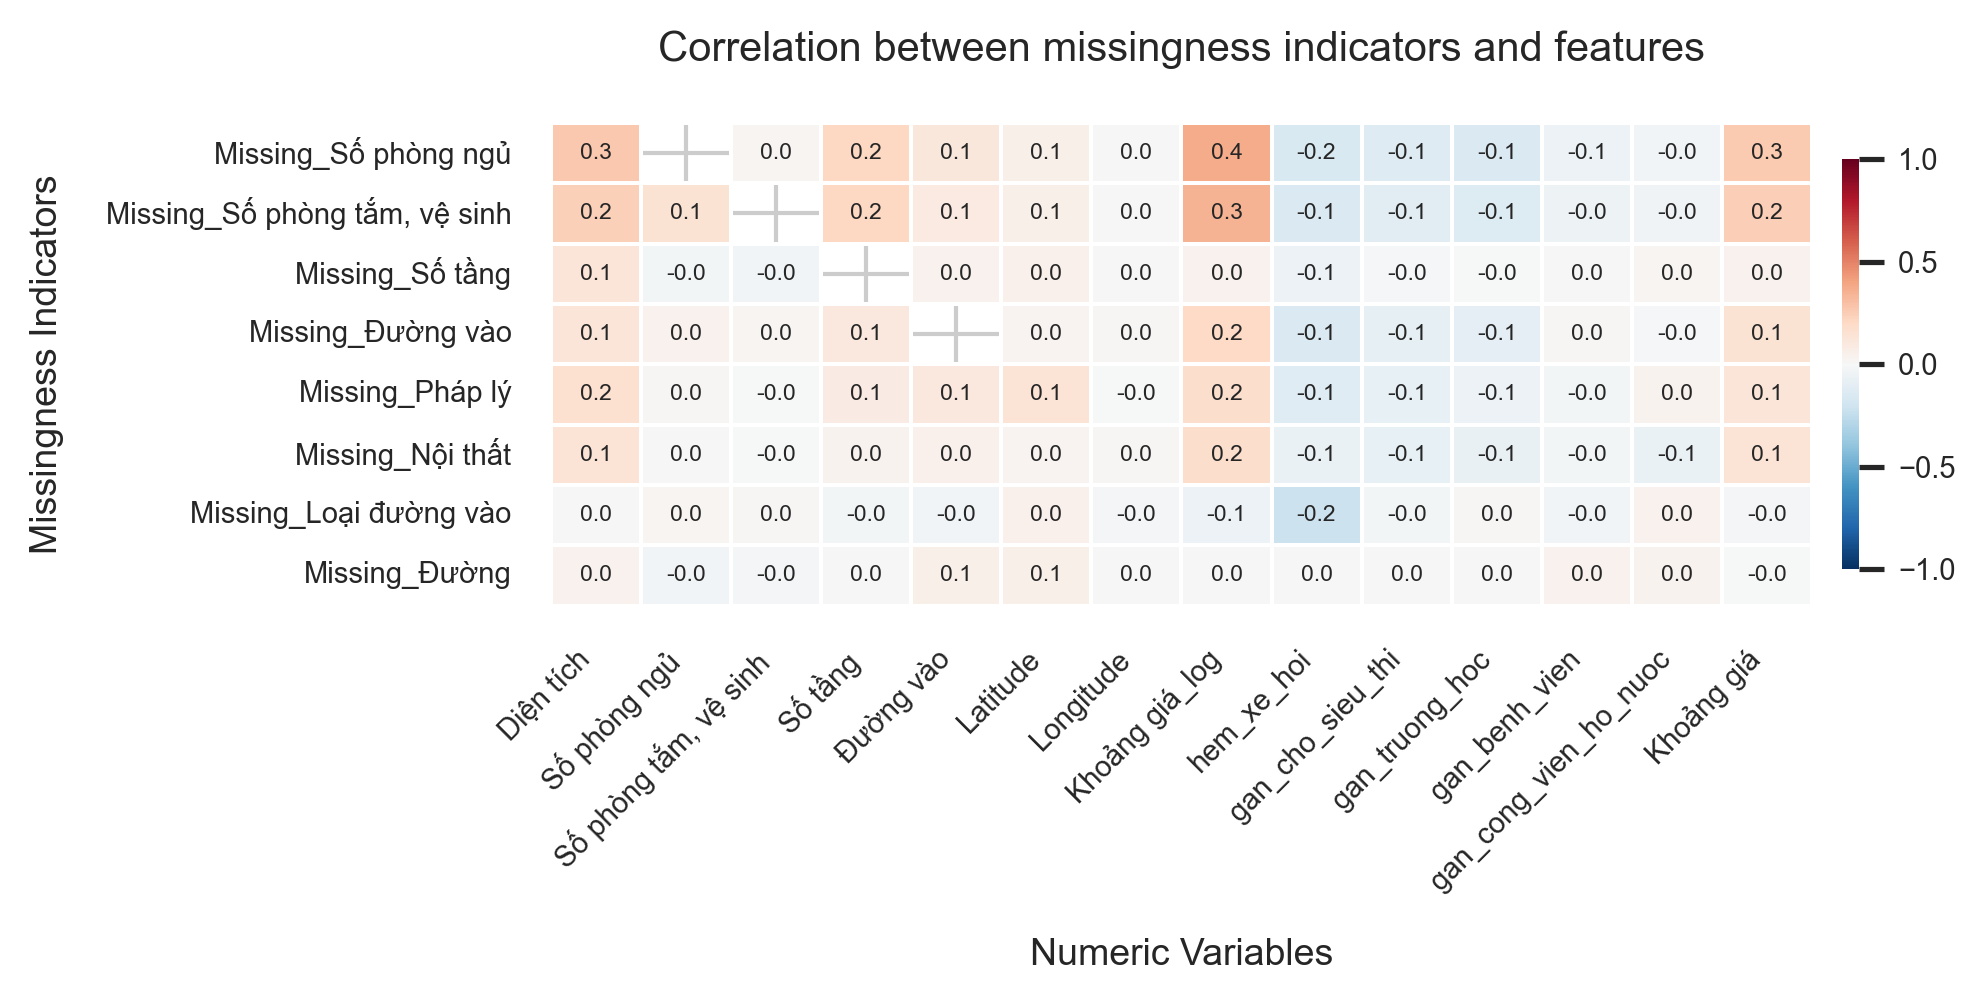

✅ Đã hoàn tất xuất biểu đồ phân tích Missing Data chuẩn IEEE.


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ghép X_train và y_train thành bảng tạm thời để phân tích đồng bộ
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Tìm các cột có chứa dữ liệu thiếu trong tập Train
cols_with_missing = [col for col in train_data.columns if train_data[col].isnull().sum() > 0]

if not cols_with_missing:
    print("✅ Tuyệt vời! Tập Train hiện tại không có dữ liệu khuyết thiếu nào.")
else:
    # Tạo các cột Dummy (Missingness Indicator)
    for col in cols_with_missing:
        train_data[f'Missing_{col}'] = train_data[col].isnull().astype(int)

    # 3. Phân tách danh sách cột
    dummy_cols = [f'Missing_{col}' for col in cols_with_missing]
    numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()
    analysis_cols = [c for c in numeric_cols if c not in dummy_cols]

    # 4. Tính toán ma trận tương quan
    corr_matrix = train_data[dummy_cols + analysis_cols].corr()
    corr_subset = corr_matrix.loc[dummy_cols, analysis_cols]

    # =========================================================
    # 5. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
    # =========================================================
    # Cài đặt phông chữ không chân (Sans-serif) và nhúng font PDF
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    # Kích thước khung hình: Ngang 7.16 inch (chuẩn IEEE 2 cột)
    fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

    # Vẽ Heatmap
    sns.heatmap(
        corr_subset, 
        annot=True, 
        cmap='RdBu_r', 
        vmin=-1, vmax=1,       # Cố định thang màu từ -1 đến 1 cho đồng bộ với hình trước
        fmt=".1f",             # Dùng 1 chữ số thập phân cho gọn gàng
        linewidths=0.5,        # Ở đây giữ lại viền trắng vì ma trận chữ nhật không bị lỗi gạch chéo
        linecolor='#ffffff',   
        annot_kws={"size": 5.5}, 
        cbar_kws={"shrink": 0.85, "aspect": 25, "pad": 0.02}, # Cbar thanh mảnh hơn
        ax=ax
    )
    
    # Tinh chỉnh Tiêu đề và Nhãn trục (LOẠI BỎ IN ĐẬM)
    ax.set_title('Correlation between missingness indicators and features', 
                 fontsize=10, pad=15)
    
    # Chỉnh cỡ chữ của tick labels đồng bộ (7pt)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
    
    # Bổ sung nhãn cho trục (LOẠI BỎ IN ĐẬM)
    ax.set_ylabel('Missingness Indicators', fontsize=9, labelpad=10)
    ax.set_xlabel('Numeric Variables', fontsize=9, labelpad=10)

    # ĐỒNG BỘ: Thu nhỏ chữ số của thanh colorbar
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    
    # 6. Xuất file vector (PDF) và ảnh chất lượng cao (PNG)
    plt.savefig('missing_data_correlation_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
    plt.savefig('missing_data_correlation_ieee.png', format='png', bbox_inches='tight', dpi=600)
    plt.show()

    print("✅ Đã hoàn tất xuất biểu đồ phân tích Missing Data chuẩn IEEE.")

In [46]:
# ════════════════════════════════════════════════
# CELL: KIỂM ĐỊNH LITTLE'S MCAR (CHỈ TRÊN TẬP TRAIN)
# ════════════════════════════════════════════════
import numpy as np
import pandas as pd
from scipy.stats import chi2

def littles_mcar_test(dataset):
    """
    Thực hiện kiểm định Little's MCAR chuẩn xác cho các thuộc tính số học.
    """
    # 1. Chỉ lọc lấy các cột dữ liệu số học và bỏ qua các cột dính NaN hoàn toàn
    data = dataset.select_dtypes(include=[np.number]).copy()
    data = data.dropna(how='all', axis=1)
    
    # 2. Tính toán Vectơ trung bình tổng thể và Ma trận hiệp phương sai tổng thể
    grand_mean = data.mean()
    grand_cov = data.cov()
    
    # Nếu ma trận hiệp phương sai bị khuyết do dữ liệu quá thưa, dùng tạm complete cases
    if grand_cov.isnull().any().any():
        grand_cov = data.dropna().cov()
        grand_mean = data.dropna().mean()

    # 3. Xác định các mô hình khuyết thiếu (Missingness Patterns)
    missing_matrix = data.isnull().astype(int)
    unique_patterns = missing_matrix.drop_duplicates()
    
    chi2_stat = 0
    df_total = 0
    n_var = data.shape[1]
    
    # 4. Duyệt qua từng mô hình khuyết thiếu để tính khoảng cách Mahalanobis
    for _, pattern in unique_patterns.iterrows():
        rows_idx = missing_matrix[(missing_matrix == pattern).all(axis=1)].index
        n_j = len(rows_idx)
        
        # Xác định các cột CÓ dữ liệu (giá trị bằng 0 trong missing_matrix)
        obs_vars = pattern[pattern == 0].index.tolist()
        p_j = len(obs_vars)
        
        if p_j == 0 or p_j == n_var and len(unique_patterns) == 1:
            continue
            
        sample_mean_j = data.loc[rows_idx, obs_vars].mean()
        
        grand_mean_j = grand_mean[obs_vars]
        grand_cov_j = grand_cov.loc[obs_vars, obs_vars]
        
        try:
            inv_cov_j = np.linalg.inv(grand_cov_j)
            diff = sample_mean_j - grand_mean_j
            
            d2 = n_j * np.dot(np.dot(diff, inv_cov_j), diff)
            
            chi2_stat += d2
            df_total += p_j
        except np.linalg.LinAlgError:
            continue
            
    df_total = df_total - n_var
    
    if df_total <= 0:
        return None, None, "Không đủ bậc tự do để tính toán p-value."
        
    p_value = chi2.sf(chi2_stat, df_total)
    
    return chi2_stat, df_total, p_value


# ─── CHẠY KIỂM ĐỊNH TRÊN TẬP TRAIN ───

# 1. Ghép X_train và y_train thành một DataFrame đồng bộ
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Gọi hàm kiểm định trên tập dữ liệu Train vừa tạo
stat, dof, p_val = littles_mcar_test(train_data)

# 3. In kết quả trực quan
print(f"{'='*10} KẾT QUẢ KIỂM ĐỊNH LITTLE'S MCAR (CHỈ TRÊN TẬP TRAIN) {'='*10}\n")
if stat is not None:
    print(f"-> Thống kê Chi-square (độ lệch) : {stat:.4f}")
    print(f"-> Bậc tự do (Degrees of Freedom): {dof}")
    print(f"-> Giá trị P-value               : {p_val:.6f}")
    print("-" * 50)
    print("\n💡 KẾT LUẬN THỐNG KÊ:")
    if p_val > 0.05:
        print("✅ p-value > 0.05: CHẤP NHẬN giả thuyết H0.")
        print("-> Dữ liệu khuyết thiếu của bạn là HOÀN TOÀN NGẪU NHIÊN (MCAR).")
        print("-> Bạn có thể an tâm áp dụng các cách điền khuyết đơn giản như Mean/Median Imputation.")
    else:
        print("⚠️ p-value <= 0.05: BÁO ĐỘNG! BÁO BỎ giả thuyết H0.")
        print("-> Dữ liệu khuyết thiếu KHÔNG NGẪU NHIÊN (MAR hoặc MNAR).")
        print("-> Việc thiếu thông tin tuân theo một quy luật hệ thống nào đó.")
        print("-> CHIẾN LƯỢC: Tuyệt đối không điền bừa bãi bằng Mean/Median tổng thể vì sẽ làm méo mó dữ liệu.")
        print("   Hãy cân nhắc điền khuyết theo phân cụm (Group-by Imputation) hoặc thuật toán dự đoán MICE/KNN.")
else:
    print(f"Không thể thực hiện kiểm định: {p_val}")

========== KẾT QUẢ KIỂM ĐỊNH LITTLE'S MCAR (CHỈ TRÊN TẬP TRAIN) ==========

-> Thống kê Chi-square (độ lệch) : 1541.8140
-> Bậc tự do (Degrees of Freedom): 178
-> Giá trị P-value               : 0.000000
--------------------------------------------------

💡 KẾT LUẬN THỐNG KÊ:
⚠️ p-value <= 0.05: BÁO ĐỘNG! BÁO BỎ giả thuyết H0.
-> Dữ liệu khuyết thiếu KHÔNG NGẪU NHIÊN (MAR hoặc MNAR).
-> Việc thiếu thông tin tuân theo một quy luật hệ thống nào đó.
-> CHIẾN LƯỢC: Tuyệt đối không điền bừa bãi bằng Mean/Median tổng thể vì sẽ làm méo mó dữ liệu.
   Hãy cân nhắc điền khuyết theo phân cụm (Group-by Imputation) hoặc thuật toán dự đoán MICE/KNN.



- phân khúc cao cấp (Giá cao, Diện tích lớn) rất ít nhập "Phòng ngủ" và "Phòng tắm"
    - Dấu hiệu: dòng Missing_Số phòng ngủ và Missing_Số phòng tắm, vệ sinh. Cặp đôi này có hành vi giống hệt nhau và tương quan thuận rất rõ với Khoảng giá (0.25), Diện tích (0.24) và đặc biệt vọt lên mạnh nhất ở Khoảng giá_log (0.31 và 0.32).
    - Lý do: Trong thị trường BĐS, phân khúc giá trị cao thường rơi vào Đất nền dự án, Biệt thự thô biệt lập, hoặc Penthouse bàn giao thô. Người bán thường chỉ đăng diện tích tổng và giá tiền chứ chưa chia phòng, dẫn đến dữ liệu bị trống hai cột này.
    - THuộc loại MAR
- Số tầng", "Đường vào" và "Nội thất": thiếu diện rộng nhưng ít phụ thuộc:
    - Dấu hiệu: Các dòng Missing_Số tầng, Missing_Đường vào và Missing_Nội thất có các ô màu xanh nhạt hoặc xám, hệ số tương quan quanh quẩn từ -0.03 đến 0.16 (khá yếu).
    - Lý do: Có một số loại bds không có đường vào, Số tầng.
    - Có thể là MCAR hoặc MNAR. Tuy nhiên dữ liệu thu thập không phải là đất hay chung cư, hơn nữa cột "Đường vào" (hay độ rộng ngõ/hẻm) chỉ có ý nghĩa sống còn đối với Nhà riêng (để biết ô tô có vào được không). Còn đối với Nhà mặt phố và Shophouse, bản chất chúng đã nằm ngoài mặt tiền đường lớn (thường là lộ giới 15m - 30m). Việc thiếu dữ liệu ở cột "Đường vào" là MNAR.

## 2.2 Xử lý cột "Nội thất", "Pháp lý"

- Dựa vào thông tin từ ma trận tương quan giữa dữ liệu thiếu và các thuộc tính: việc 3 thuộc tính này thấp có tương quan thấp so với các thuộc tính còn lại. Do đó thuộc loại MCAR hoặc MNAR.
- Dựa vào kiến thức nghiệp vụ thì. Người nhập sẽ cố tình giấu các thuộc tính này nếu căn nhà bán không có vì khi có các thuộc tính này sẽ làm cho giá nhà gia tăng và có thêm lợi nhuận. Do đó các thuộc tính này sẽ thuộc loại MCAR.
- 'Nội thất' và 'Pháp lý' điền 'không có'.

In [47]:
imputation_rules = {
    'Nội thất': 'Trống / Nhà thô',
    'Pháp lý': 'không có',
}

# 2. Hàm áp dụng quy tắc điền khuyết để tránh lặp lại code
def apply_imputation(df_target, rules):
    df_copied = df_target.copy()
    for col, value in rules.items():
        if col in df_copied.columns:
            df_copied[col] = df_copied[col].fillna(value)
    return df_copied

# 3. Tiến hành điền khuyết độc lập cho cả 2 tập dữ liệu
X_train = apply_imputation(X_train, imputation_rules)
X_test = apply_imputation(X_test, imputation_rules)

# 4. Kiểm tra lại tỷ lệ Null sau khi xử lý
print("📊 KIỂM TRA SỐ LƯỢNG NULL SAU KHI XỬ LÝ:")
print("-" * 40)
for col in imputation_rules.keys():
    if col in X_train.columns:
        print(f"-> Cột '{col:15s}': Train còn {X_train[col].isnull().sum()} null | Test còn {X_test[col].isnull().sum()} null")

📊 KIỂM TRA SỐ LƯỢNG NULL SAU KHI XỬ LÝ:
----------------------------------------
-> Cột 'Nội thất       ': Train còn 0 null | Test còn 0 null
-> Cột 'Pháp lý        ': Train còn 0 null | Test còn 0 null


## 2.3 Xử lý missing ở cột 'Bathroom' và 'Bedroom'

1. Bathroom

- Số lượng missing >5%

Vẽ phân phối của 2 cột này.

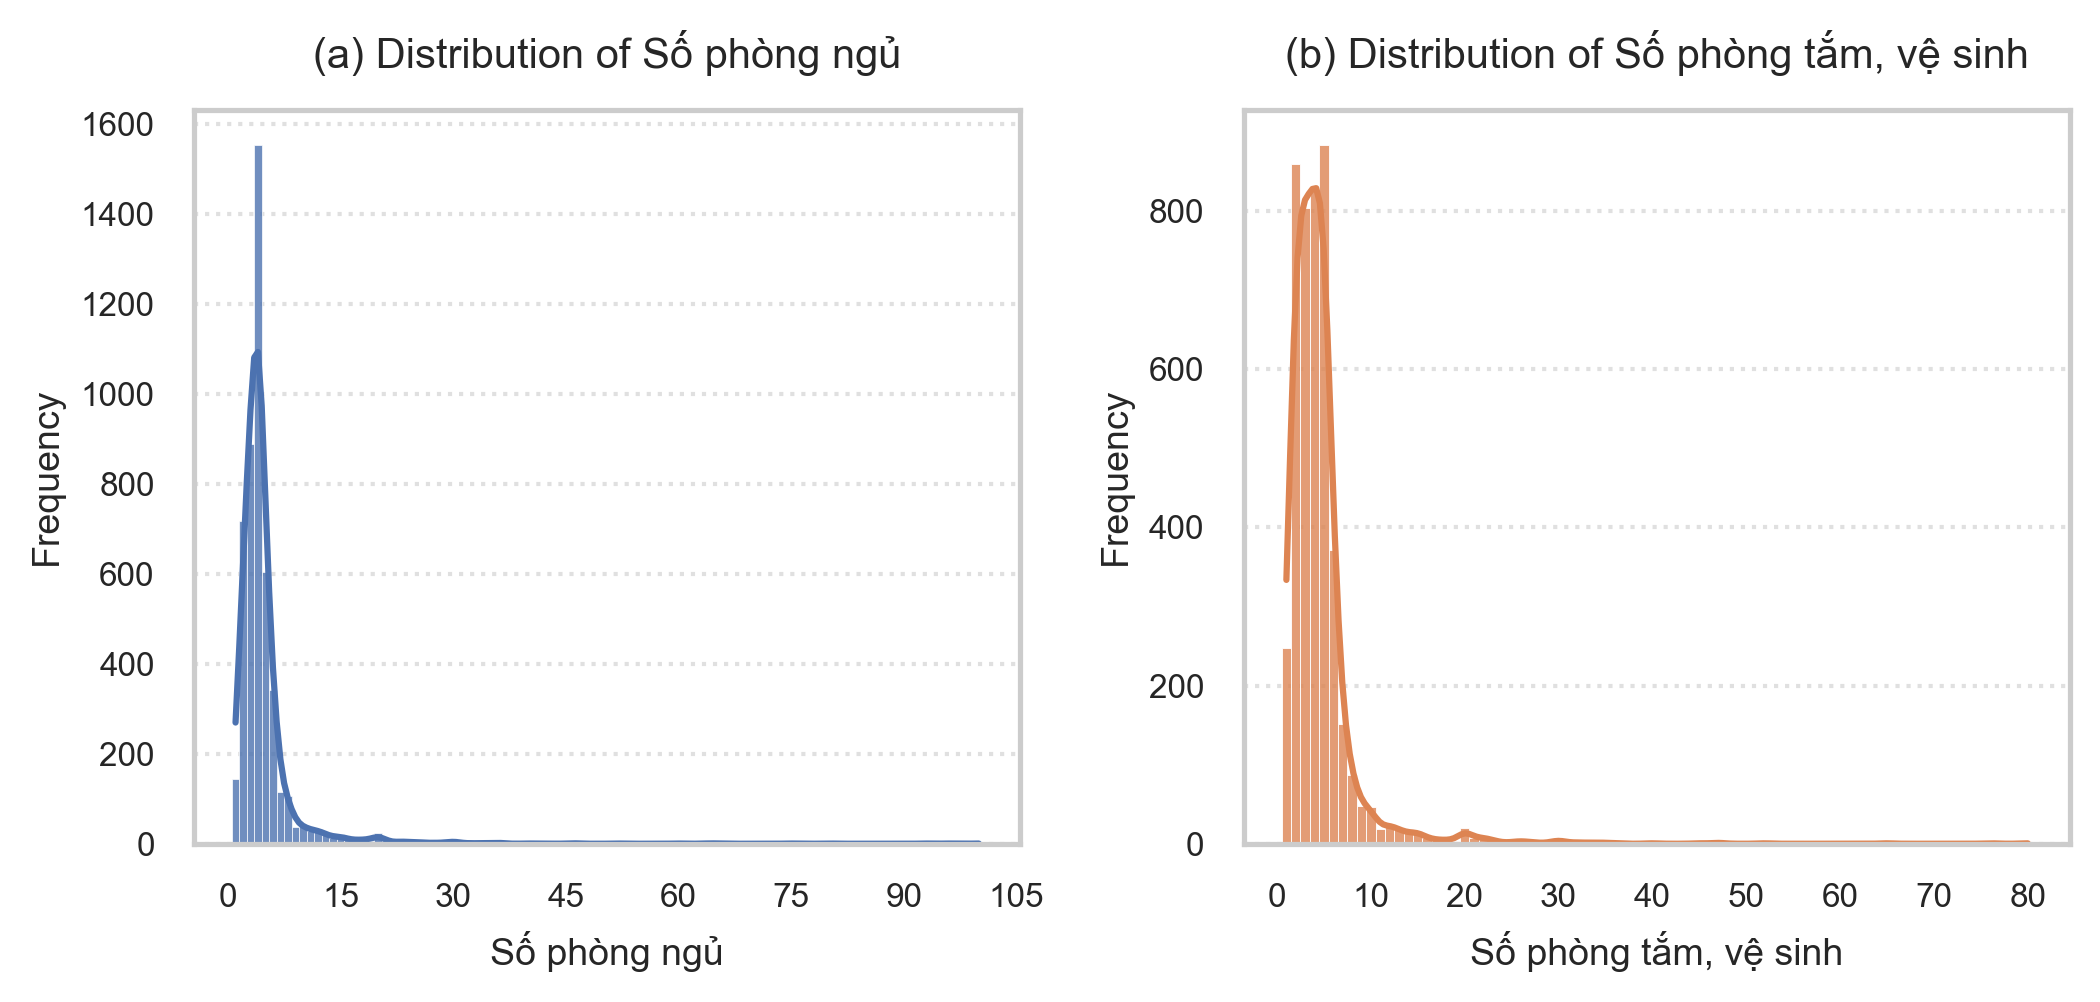

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# =========================================================
# 1. CẤU HÌNH PHÔNG CHỮ VÀ KÍCH THƯỚC (CHUẨN IEEE)
# =========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình: Ngang 7.16 inch (tràn 2 cột), Cao 3.5 inch
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

# --- BIỂU ĐỒ (a): Phân phối biến "Số phòng ngủ" ---
so_phong_ngu_clean = df['Số phòng ngủ'].dropna()

sns.histplot(
    so_phong_ngu_clean, 
    discrete=True, 
    kde=True, 
    color='#4C72B0', 
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)
# Sử dụng chính xác tên biến gốc theo yêu cầu
axes[0].set_title('(a) Distribution of Số phòng ngủ', fontsize=10, pad=10) 
axes[0].set_xlabel('Số phòng ngủ', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)

# Tự động chia số mốc hiển thị (tối đa ~10 mốc), chỉ lấy số nguyên
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10)) 
axes[0].tick_params(axis='both', labelsize=8)

# Chỉnh lưới nền
axes[0].grid(axis='y', linestyle=':', alpha=0.6) 
axes[0].grid(axis='x', visible=False) 

# --- BIỂU ĐỒ (b): Phân phối biến "Số phòng tắm, vệ sinh" ---
so_phong_tam_clean = df['Số phòng tắm, vệ sinh'].dropna()

sns.histplot(
    so_phong_tam_clean, 
    discrete=True, 
    kde=True, 
    color='#DD8452', 
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)
# Sử dụng chính xác tên biến gốc theo yêu cầu
axes[1].set_title('(b) Distribution of Số phòng tắm, vệ sinh', fontsize=10, pad=10) 
axes[1].set_xlabel('Số phòng tắm, vệ sinh', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)

# Xử lý trục X
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[1].tick_params(axis='both', labelsize=8)

axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

# Tinh chỉnh khoảng cách an toàn
plt.tight_layout()

# 2. XUẤT FILE CHUẨN XUẤT BẢN
#plt.savefig('distribution_histograms_ieee_vars.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('distribution_histograms_ieee_vars.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

Phát hiện outlier nghiêm trọng

In ra các outlier

In [366]:
# 1. Đặt lại ngưỡng như lúc nãy (bạn có thể thay đổi số này nếu muốn)
MAX_ROOMS = 15

# 2. Tạo điều kiện lọc (Filter):
# Lấy những dòng có Số phòng ngủ LỚN HƠN 15 HOẶC Số phòng tắm LỚN HƠN 15
condition = (df['Số phòng ngủ'] > MAX_ROOMS) | (df['Số phòng tắm, vệ sinh'] > MAX_ROOMS)

# Lọc ra tập dữ liệu chứa toàn outliers
outliers_df = df[condition]

# 3. Chọn các cột quan trọng để hiển thị cho đỡ rối mắt
# (Chỉ chọn những cột nào thực sự tồn tại trong DataFrame của bạn)
cols_to_show = [
    'Link', 'Diện tích', 'Khoảng giá', 'Số tầng', 
    'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Nội thất', 'Pháp lý'
]
cols_to_show = [col for col in cols_to_show if col in outliers_df.columns]

# 4. Sắp xếp dữ liệu giảm dần theo "Số phòng ngủ" để xem các giá trị cực đoan nhất
outliers_df_sorted = outliers_df.sort_values(by='Số phòng ngủ', ascending=False)

# 5. In kết quả ra màn hình
print(f"🚨 TỔNG SỐ MẪU NGOẠI LAI TÌM THẤY: {len(outliers_df_sorted)} bài đăng\n")
print("-" * 50)

# Dùng display() nếu bạn đang dùng Jupyter Notebook / Google Colab để bảng hiện ra đẹp hơn
# Nếu dùng IDE bình thường (VSCode, PyCharm), bạn có thể đổi thành print()
try:
    display(outliers_df_sorted[cols_to_show].head(50)) # In 50 dòng đầu tiên
except NameError:
    print(outliers_df_sorted[cols_to_show].head(50))

🚨 TỔNG SỐ MẪU NGOẠI LAI TÌM THẤY: 125 bài đăng

--------------------------------------------------


,Link,Diện tích,Khoảng giá,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh",Nội thất,Pháp lý
3415,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,228.000,75.00,10.0,100.0,NaN,Đầy đủ,Sổ hồng
3383,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,1.144,140.00,NaN,96.0,NaN,NaN,Sổ hồng
1882,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,592.000,135.00,8.0,93.0,NaN,Đầy đủ,Sổ hồng
2778,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,300.000,48.00,5.0,80.0,80.0,NaN,Sổ hồng
1831,https://batdongsan.com.vn/ban-nha-rieng-duong-...,198.000,50.00,8.0,75.0,76.0,Đầy đủ,Sổ hồng
1636,https://batdongsan.com.vn/ban-nha-rieng-duong-...,309.000,35.00,7.0,65.0,65.0,NaN,Sổ hồng
5443,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,240.000,450.00,12.0,64.0,NaN,Đầy đủ,Sổ hồng
115,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,337.000,600.00,11.0,60.0,NaN,NaN,Sổ hồng
1369,https://batdongsan.com.vn/ban-nha-rieng-duong-...,182.000,33.90,7.0,52.0,52.0,NaN,Sổ hồng
5893,https://batdongsan.com.vn/ban-nha-rieng-duong-...,734.000,28.50,6.0,46.0,47.0,Đầy đủ,Sổ hồng


Các outlier này là một giá trị quan trọng chứ không phải lỗi nhập liệu. Đó là các tin đăng rao bán cả toà nhà gần 10 tầng nên có thể lên đến 100 phòng ngủ

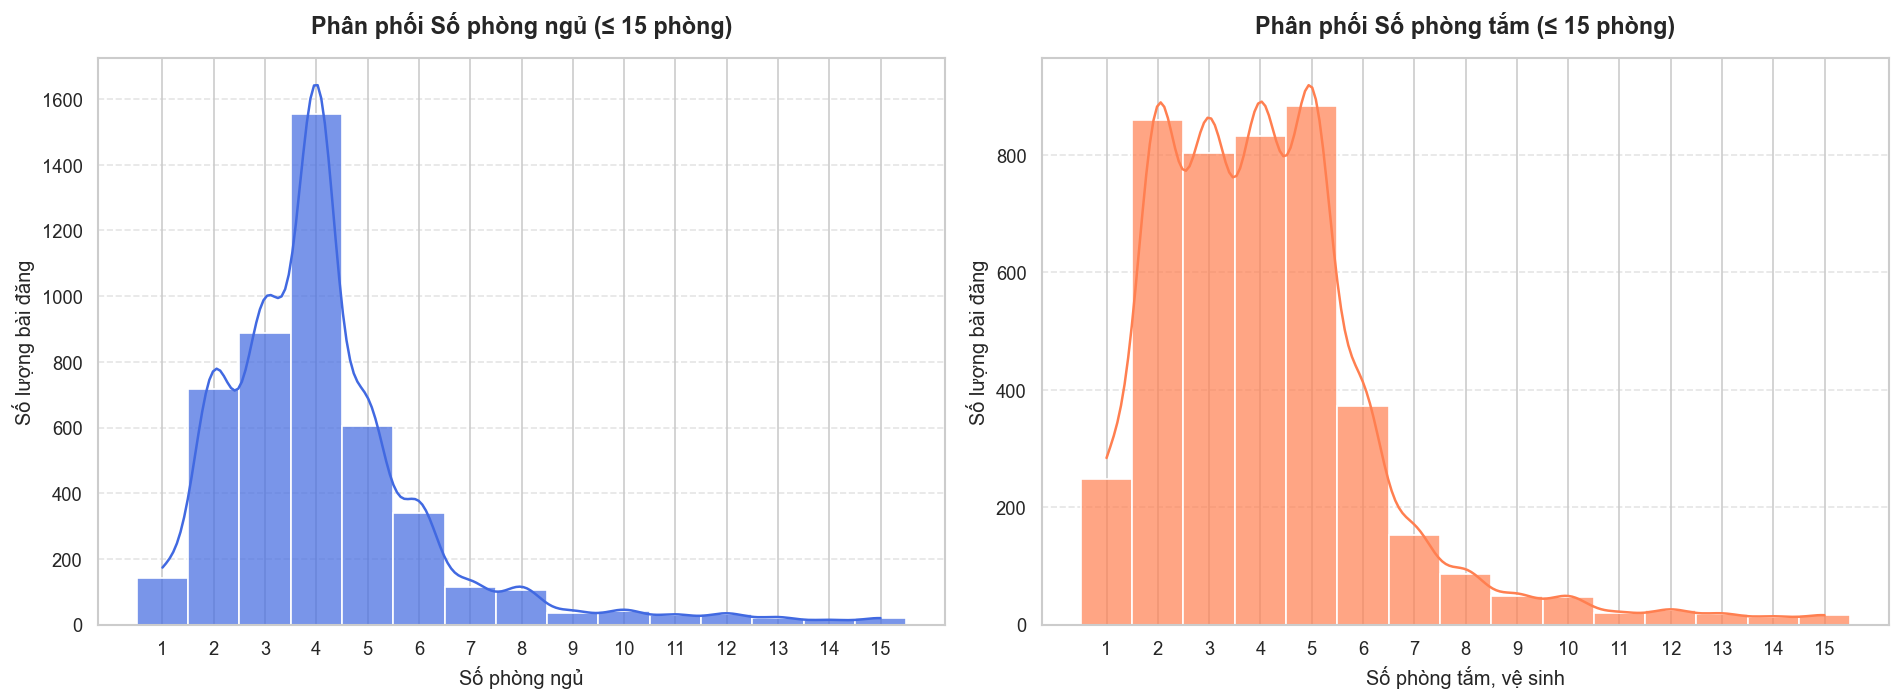

Cảnh báo: Có 118 bài đăng có số phòng ngủ lớn hơn 15.
Cảnh báo: Có 94 bài đăng có số phòng tắm lớn hơn 15.


In [367]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo khung hình
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đặt ngưỡng tối đa để loại bỏ nhiễu hiển thị (outliers) - ví dụ: 15 phòng
MAX_ROOMS = 15

# --- BIỂU ĐỒ 1: Phân phối Số phòng ngủ ---
# Chỉ lấy những căn có số phòng <= MAX_ROOMS để vẽ
so_phong_ngu_clean = df[df['Số phòng ngủ'] <= MAX_ROOMS]['Số phòng ngủ'].dropna()

sns.histplot(
    so_phong_ngu_clean, 
    discrete=True, 
    kde=True, 
    color='royalblue', 
    edgecolor='white',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title(f'Phân phối Số phòng ngủ (≤ {MAX_ROOMS} phòng)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Số phòng ngủ', fontsize=12)
axes[0].set_ylabel('Số lượng bài đăng', fontsize=12)
axes[0].set_xticks(range(int(so_phong_ngu_clean.min()), int(so_phong_ngu_clean.max()) + 1))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: Phân phối Số phòng tắm, vệ sinh ---
# Chỉ lấy những căn có số phòng <= MAX_ROOMS để vẽ
so_phong_tam_clean = df[df['Số phòng tắm, vệ sinh'] <= MAX_ROOMS]['Số phòng tắm, vệ sinh'].dropna()

sns.histplot(
    so_phong_tam_clean, 
    discrete=True, 
    kde=True, 
    color='coral', 
    edgecolor='white',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title(f'Phân phối Số phòng tắm (≤ {MAX_ROOMS} phòng)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Số phòng tắm, vệ sinh', fontsize=12)
axes[1].set_ylabel('Số lượng bài đăng', fontsize=12)
axes[1].set_xticks(range(int(so_phong_tam_clean.min()), int(so_phong_tam_clean.max()) + 1))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# In ra màn hình cảnh báo số lượng các dòng dữ liệu bị nghi ngờ là lỗi
outliers_ngu = df[df['Số phòng ngủ'] > MAX_ROOMS].shape[0]
outliers_tam = df[df['Số phòng tắm, vệ sinh'] > MAX_ROOMS].shape[0]
print(f"Cảnh báo: Có {outliers_ngu} bài đăng có số phòng ngủ lớn hơn {MAX_ROOMS}.")
print(f"Cảnh báo: Có {outliers_tam} bài đăng có số phòng tắm lớn hơn {MAX_ROOMS}.")

In [368]:
import pandas as pd

# 1. Chọn 2 cột cần thống kê
cols_to_describe = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']

# Kiểm tra các cột tồn tại để tránh lỗi
cols_exist = [col for col in cols_to_describe if col in df.columns]

if len(cols_exist) > 0:
    # 2. Sử dụng describe() với các mốc phân vị để xem phần "đuôi" dữ liệu
    stats_df = df[cols_exist].describe(percentiles=[.25, .50, .75, .90, .95, .99])
    
    # 3. Tính Median (Trung vị) tường minh
    median_df = df[cols_exist].median()
    median_df.name = 'median'
    
    # 4. Tính Mode (Giá trị xuất hiện nhiều nhất)
    mode_df = df[cols_exist].mode().iloc[0]
    mode_df.name = 'mode'
    
    # 5. Gộp cả Median và Mode vào cuối bảng thống kê
    stats_df = pd.concat([stats_df, median_df.to_frame().T, mode_df.to_frame().T])
    
    # 6. Hiển thị bảng kết quả
    print("BẢNG THỐNG KÊ MÔ TẢ CHI TIẾT:\n" + "-"*40)
    
    try:
        display(stats_df.round(2))
    except NameError:
        print(stats_df.round(2))
else:
    print("Không tìm thấy các cột yêu cầu trong DataFrame.")

BẢNG THỐNG KÊ MÔ TẢ CHI TIẾT:
----------------------------------------


,Số phòng ngủ,"Số phòng tắm, vệ sinh"
count,4782.00,4519.00
mean,4.72,4.55
std,4.84,4.09
min,1.00,1.00
25%,3.00,3.00
50%,4.00,4.00
75%,5.00,5.00
90%,7.00,7.00
95%,10.00,10.00
99%,23.00,21.82


- Tỉ lệ bản ghi bị thiếu cao (15-20%).

- Tuộc tính này tương quan cao với các thuôc tính như: 'Khoảng giá' và 'Diện tích' -> MAR.

- Số lượng missing ở cột này cũng có tương quan cao với các cột khác.

- Sử dụng các mô hình học máy để điền khuyết. 'Khoảng giá' và 'Diện tích' là 2 biến liên tục nên có thể dùng KNN hoặc MICE để điền.

- Đặc biệt: Việc missing 'Số tầng' không tương quan tới các thuộc tính khác -> MCAR, nhưng giá trị của số tầng lại tương quan mạnh với 'Số phòng ngủ' và 'Số phòng tắm, vệ sinh'. Vì vậy việc dự đoán 2 cột này trước sẽ làm tiền đề để sự đoán cột số tầng về sau.


### 2.2.1 Xử lý thuộc tính 'Số phòng ngủ'

#### 2.2.1.1 Phương án 1: điền khuyết bằng KNN.

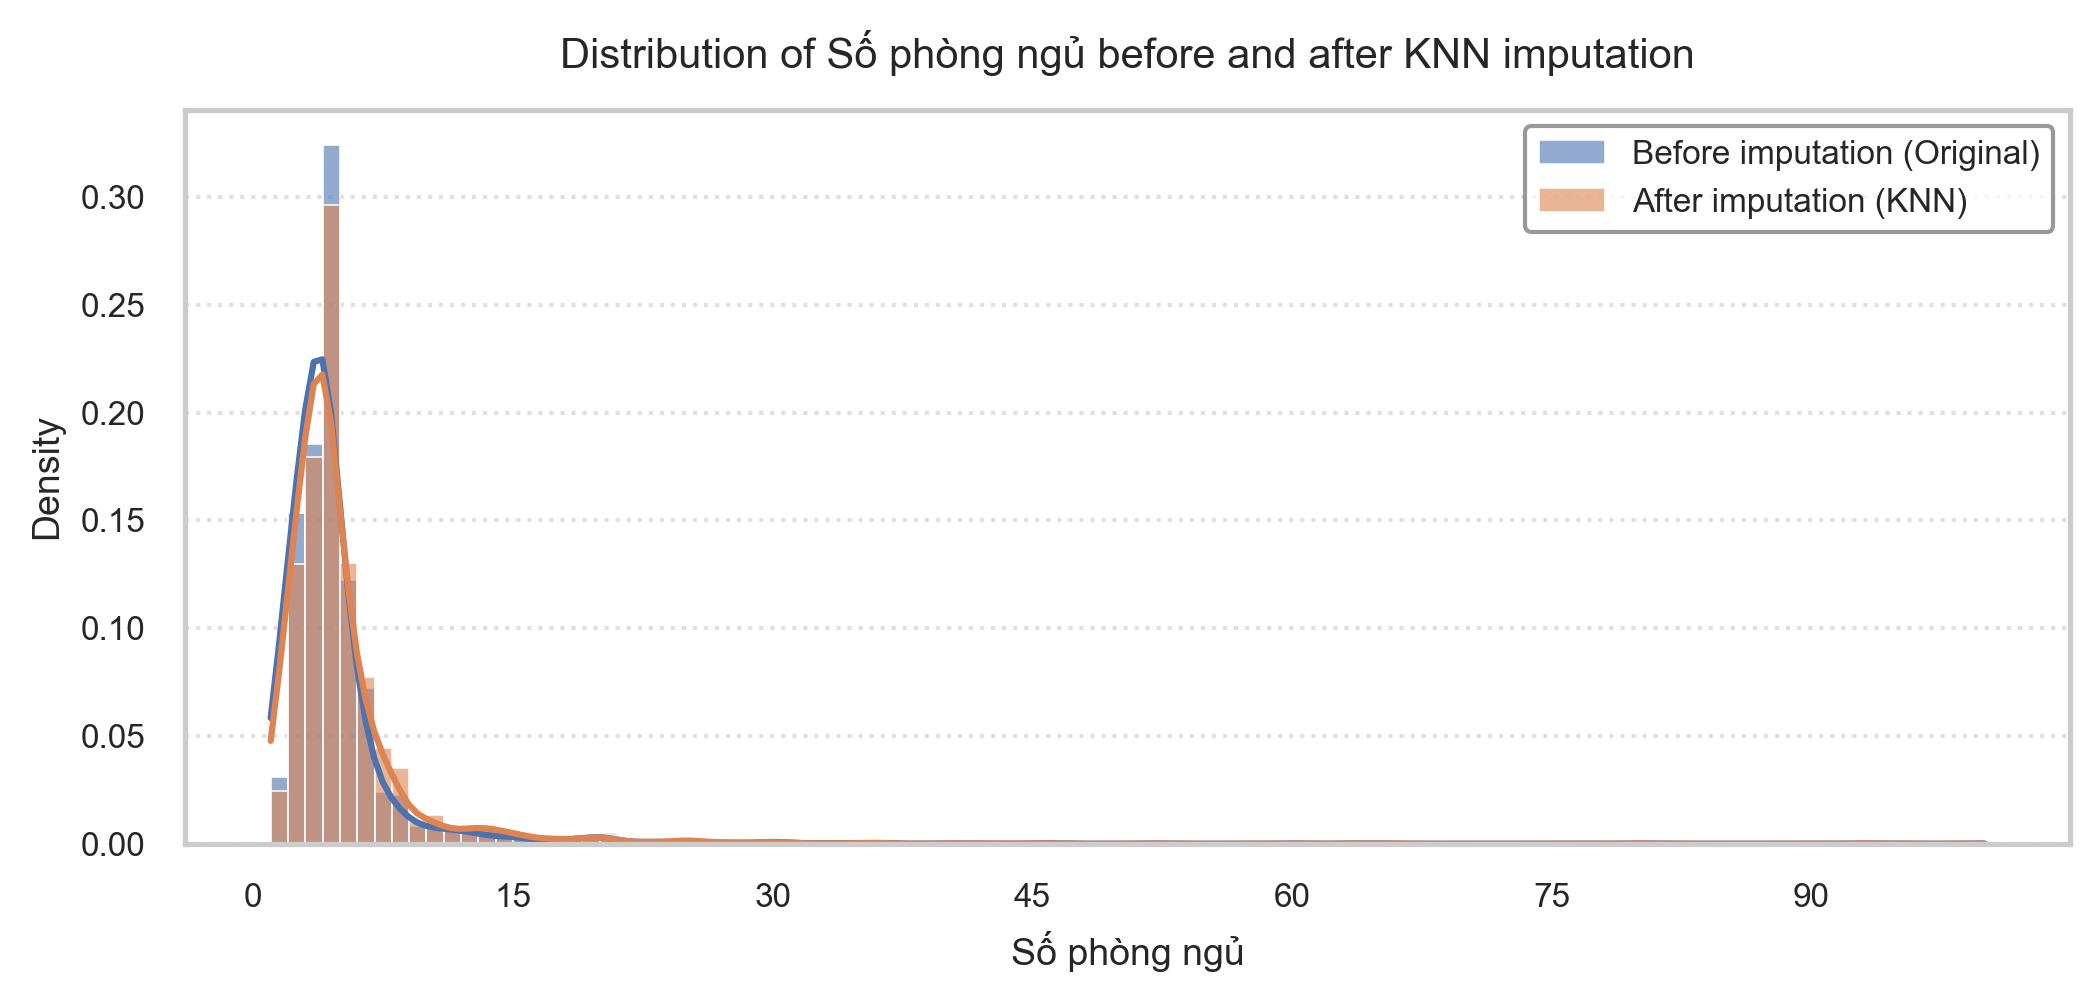

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import MaxNLocator # Thêm công cụ sửa lỗi trùng nhãn trục X

# 1. Giả sử bạn đã chia tập train (X_train)
features_to_use = ['Diện tích', 'Số phòng ngủ']
X_train_sub = X_train[features_to_use].copy()

# 2. Scale dữ liệu
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sub), columns=features_to_use)

# 3. Điền khuyết bằng KNN
knn_imputer = KNNImputer(n_neighbors=5)
X_train_imputed_scaled = knn_imputer.fit_transform(X_train_scaled)

# 4. Nghịch đảo scale để lấy lại đơn vị gốc
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed_scaled), columns=features_to_use, index=X_train.index)

# 5. Làm tròn cột Số phòng ngủ về số nguyên và LƯU TẠM (Chưa ghi đè lên X_train)
phong_ngu_sau_khi_dien_knn = np.round(X_train_imputed['Số phòng ngủ']).astype(int)

# =========================================================
# 6. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Vẽ dữ liệu GỐC (Original - Bỏ qua NaN) - Màu xanh học thuật dịu mắt
sns.histplot(
    X_train['Số phòng ngủ'].dropna(), 
    color='#4C72B0', 
    label='Before imputation (Original)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Vẽ dữ liệu SAU KHI ĐIỀN (KNN Imputed) - Màu cam học thuật đồng bộ
sns.histplot(
    phong_ngu_sau_khi_dien_knn, 
    color='#DD8452', 
    label='After imputation (KNN)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Tinh chỉnh Tiêu đề và Nhãn trục (Tiếng Anh cấu trúc, giữ tên biến gốc, KHÔNG IN ĐẬM)
ax.set_title('Distribution of Số phòng ngủ before and after KNN imputation', fontsize=10, pad=10)
ax.set_xlabel('Số phòng ngủ', fontsize=9)
ax.set_ylabel('Density', fontsize=9)

# SỬA LỖI TRỤC X: Tự động tính toán số mốc hiển thị hợp lý (tối đa ~10 mốc nguyên)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis='both', labelsize=8)

# Định dạng khung chú thích (Legend) gọn gàng
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')

# Lưới nền (Chỉ hiển thị các đường ngang nét đứt siêu mờ để tránh rối mắt)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

# 7. XUẤT FILE VECTOR CHẤT LƯỢNG CAO CHO BÁO CÁO KHOA HỌC
#plt.savefig('imputation_bedrooms_distribution_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('imputation_bedrooms_distribution_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

# ==========================================
# 8. QUYẾT ĐỊNH ÁP DỤNG
# ==========================================
# X_train['Số phòng ngủ'] = phong_ngu_sau_khi_dien_knn

- Phân phối dữ liệu sau khi dự đoán bằng KNN trùng khớp với phân phối trước khi điền khuyết. Mô hình KNN cho kết qủa tốt.

#### 2.2.1.2 Phương án 2: dùng MICE (dùng Random Forest) điền khuyết

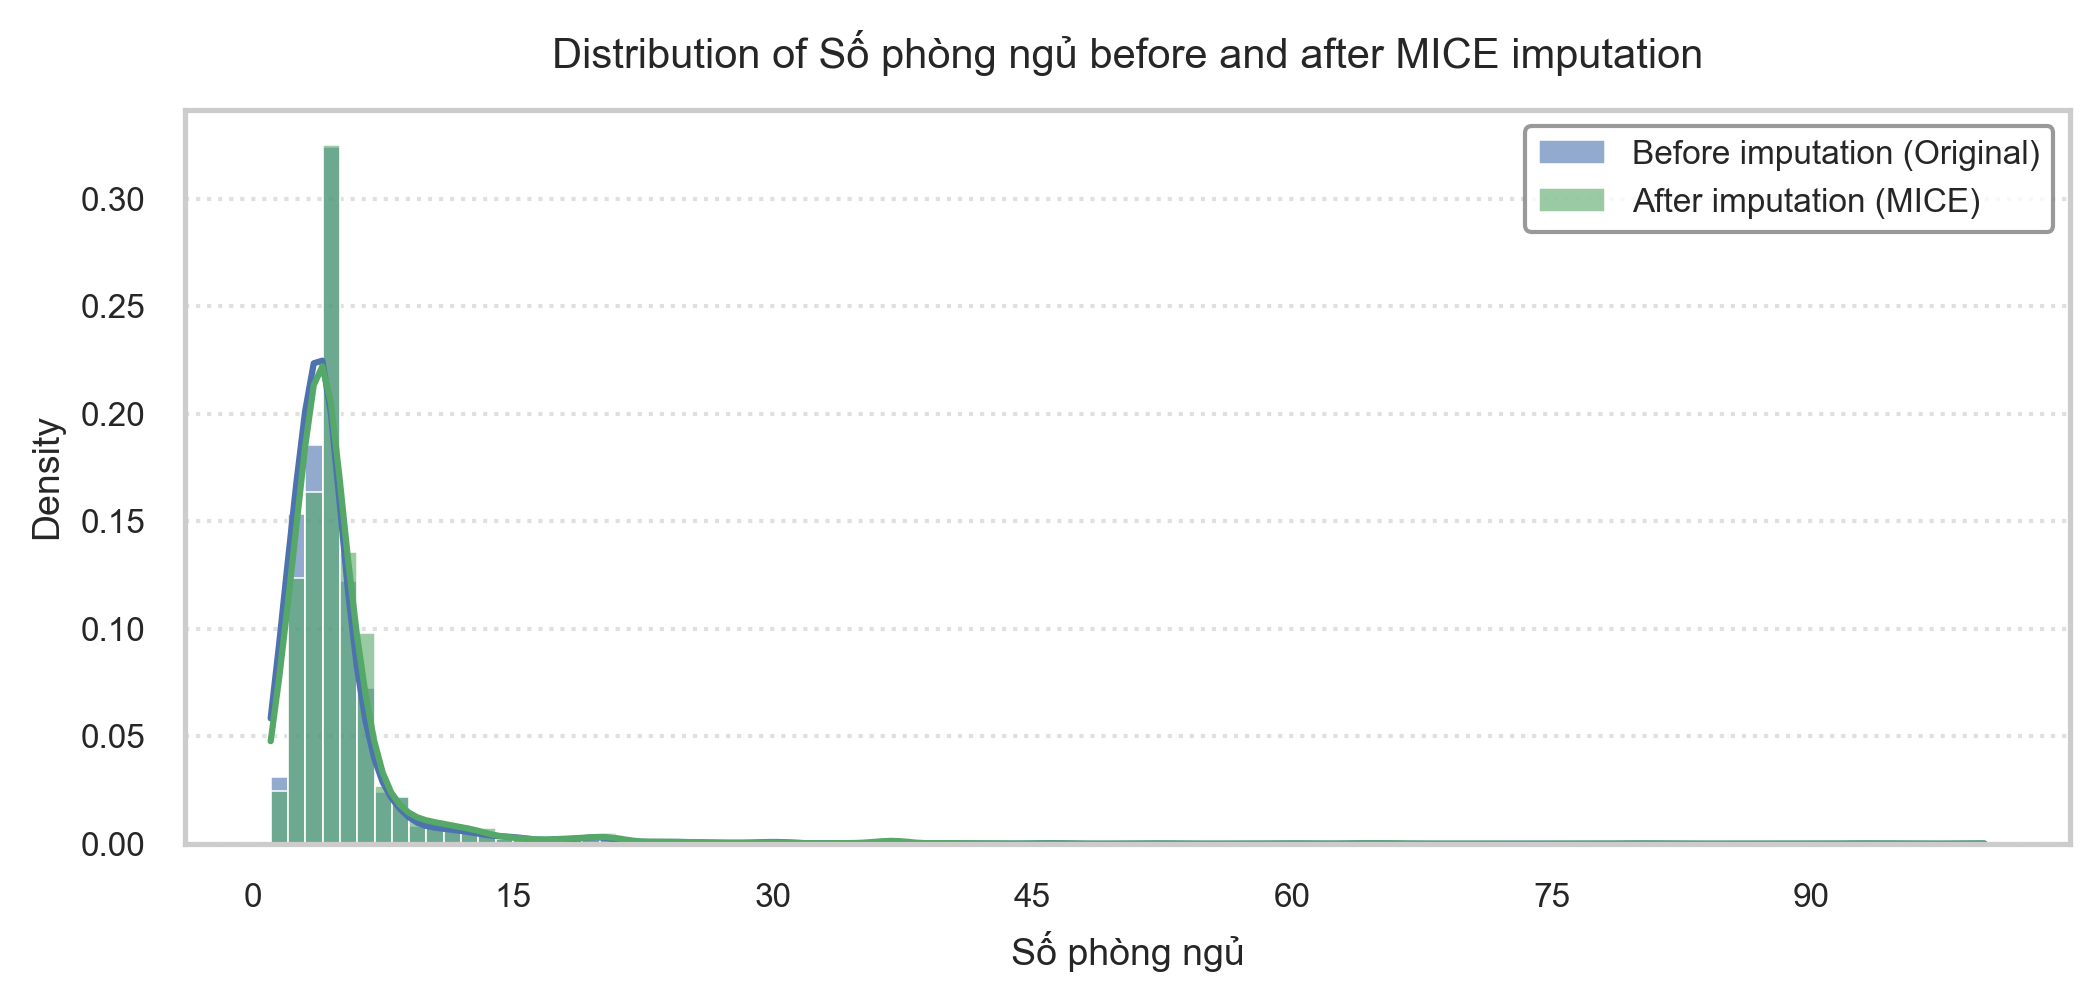

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import bắt buộc cho MICE trong sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from matplotlib.ticker import MaxNLocator # Thêm công cụ xử lý trục X

# 1. Chọn các cột liên quan
features_to_use = ['Diện tích', 'Số phòng ngủ']
X_train_sub = X_train[features_to_use].copy()

# 2. Khởi tạo MICE imputer với Random Forest
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
    max_iter=10,
    random_state=42 
)

# Điền khuyết 
X_train_imputed = pd.DataFrame(mice_imputer.fit_transform(X_train_sub), columns=features_to_use, index=X_train.index)

# 3. Làm tròn kết quả về số nguyên và LƯU TẠM
phong_ngu_sau_khi_dien_mice = np.round(X_train_imputed['Số phòng ngủ']).astype(int)

# =========================================================
# 4. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE (MICE)
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Vẽ dữ liệu GỐC (Original - Bỏ qua NaN) - Màu xanh học thuật thống nhất
sns.histplot(
    X_train['Số phòng ngủ'].dropna(), 
    color='#4C72B0', 
    label='Before imputation (Original)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Vẽ dữ liệu SAU KHI ĐIỀN bằng MICE - Sử dụng tone xanh lá cây học thuật dịu mắt
sns.histplot(
    phong_ngu_sau_khi_dien_mice, 
    color='#55A868', 
    label='After imputation (MICE)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Tinh chỉnh Tiêu đề và Nhãn trục (Cấu trúc tiếng Anh, giữ tên biến gốc, KHÔNG IN ĐẬM)
ax.set_title('Distribution of Số phòng ngủ before and after MICE imputation', fontsize=10, pad=10)
ax.set_xlabel('Số phòng ngủ', fontsize=9)
ax.set_ylabel('Density', fontsize=9)

# SỬA LỖI TRỤC X: Tự động chia khoảng cách mốc hiển thị hợp lý (tối đa ~10 mốc nguyên)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis='both', labelsize=8)

# Định dạng khung chú thích (Legend) gọn gàng
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')

# Lưới nền (Chỉ hiển thị các đường lưới ngang nét đứt mờ)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

# 5. XUẤT FILE VECTOR CHẤT LƯỢNG CAO CHO BÁO CÁO KHOA HỌC
#plt.savefig('imputation_mice_distribution_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('imputation_mice_distribution_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

# ==========================================
# 6. QUYẾT ĐỊNH ÁP DỤNG
# ==========================================
# X_train['Số phòng ngủ'] = phong_ngu_sau_khi_dien_mice

- Phân phối dữ liệu sau khi dự đoán bằng MICE(dùng Random Forest) trùng khớp với phân phối trước khi điền khuyết. Mô hình MICE cho kết qủa tốt.

Điền bằng MICE (2 phương pháp có hiệu suất như nhau)

In [56]:
X_train['Số phòng ngủ'] = phong_ngu_sau_khi_dien_mice

Áp dụng lên test

In [57]:
# 1. Chọn 3 cột tương ứng trên tập Test
features_to_use_pn = ['Diện tích', 'Số phòng ngủ']
X_test_sub = X_test[features_to_use_pn].copy()

# 2. Dùng TRANSFORM (không dùng fit_transform) với mice_imputer
X_test_imputed = pd.DataFrame(
    mice_imputer.transform(X_test_sub), 
    columns=features_to_use_pn, 
    index=X_test.index
)

# 3. Chốt kết quả vào X_test
X_test['Số phòng ngủ'] = np.round(X_test_imputed['Số phòng ngủ']).astype(int)

In [58]:
print("=== KIỂM TRA SỐ PHÒNG NGỦ SAU KHI ĐIỀN BẰNG MICE (X_test) ===")
print(f"Số lượng giá trị NaN còn lại trong cột Số phòng ngủ: {X_test['Số phòng ngủ'].isnull().sum()}")
print("\n5 dòng đầu tiên của các biến liên quan trong X_test:")
display(X_test[['Diện tích', 'Khoảng giá_log', 'Số phòng ngủ']].head())

=== KIỂM TRA SỐ PHÒNG NGỦ SAU KHI ĐIỀN BẰNG MICE (X_test) ===
Số lượng giá trị NaN còn lại trong cột Số phòng ngủ: 0

5 dòng đầu tiên của các biến liên quan trong X_test:


,Diện tích,Khoảng giá_log,Số phòng ngủ
84,50.0,1.294727,1
5875,64.0,2.939162,4
787,61.0,2.134166,4
4375,54.0,2.151762,5
79,73.0,2.708050,4


### 2.2.2 Xử lý thuộc tính 'Số phòng tắm/vệ sinh'

Tận dụng thuộc tính 'Số phòng ngủ' đã được dự đoán ở bước trước để nội suy 'Số phòng tắm, vệ sinh'.

#### 2.2.2.1 Phương án 1: điền khuyết bằng KNN.

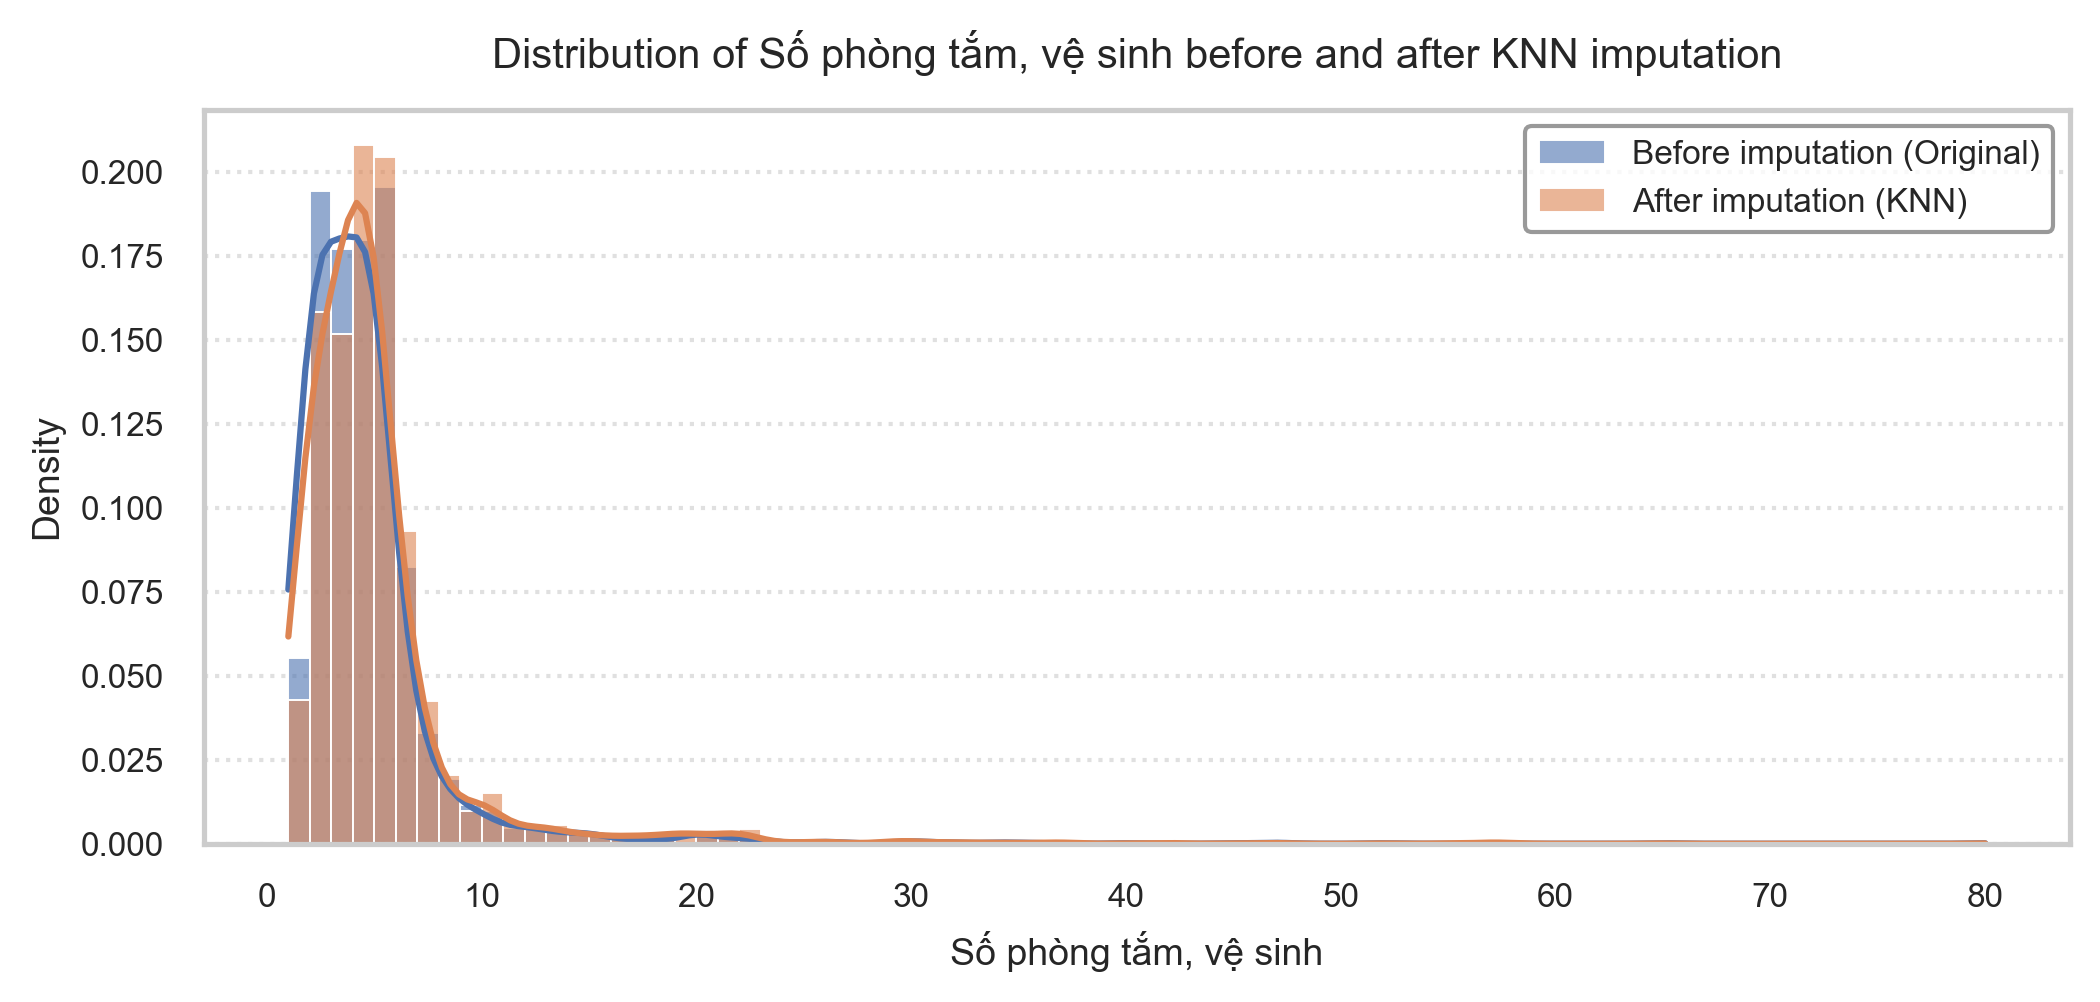

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import MaxNLocator # Thêm công cụ xử lý trục X

# 1. Chọn các cột liên quan
features_to_use = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_train_sub = X_train[features_to_use].copy()

# 2. Scale dữ liệu
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sub), columns=features_to_use)

# 3. Điền khuyết bằng KNN
knn_imputer = KNNImputer(n_neighbors=5)
X_train_imputed_scaled = knn_imputer.fit_transform(X_train_scaled)

# 4. Nghịch đảo scale để lấy lại đơn vị gốc
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed_scaled), 
                               columns=features_to_use, index=X_train.index)

# 5. Làm tròn cột Số phòng tắm, vệ sinh về số nguyên và LƯU TẠM
phong_tam_sau_khi_dien_knn = np.round(X_train_imputed['Số phòng tắm, vệ sinh']).astype(int)

# =========================================================
# 6. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và nhúng font PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn (7.16 inch), Cao 3.5 inch
fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Vẽ dữ liệu GỐC (Original - Bỏ qua NaN)
sns.histplot(
    X_train['Số phòng tắm, vệ sinh'].dropna(), 
    color='#4C72B0', # Xanh học thuật
    label='Before imputation (Original)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Vẽ dữ liệu SAU KHI ĐIỀN (KNN Imputed)
sns.histplot(
    phong_tam_sau_khi_dien_knn, 
    color='#DD8452', # Cam học thuật
    label='After imputation (KNN)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Tinh chỉnh Tiêu đề và Nhãn trục (Tiếng Anh, giữ nguyên tên biến gốc)
ax.set_title('Distribution of Số phòng tắm, vệ sinh before and after KNN imputation', fontsize=10, pad=10)
ax.set_xlabel('Số phòng tắm, vệ sinh', fontsize=9)
ax.set_ylabel('Density', fontsize=9)

# SỬA LỖI TRỤC X: Tự động chia số mốc hiển thị, tránh đè chữ
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis='both', labelsize=8)

# Tinh chỉnh chú thích (Legend)
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')

# Lưới nền (Chỉ dùng lưới ngang nét đứt mờ)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

# 7. XUẤT FILE CHUẨN XUẤT BẢN
#plt.savefig('imputation_knn_distribution_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('imputation_knn_distribution_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

#### 2.2.2.2 Phương án 2: dùng MICE (dùng Random Forest) điền khuyết

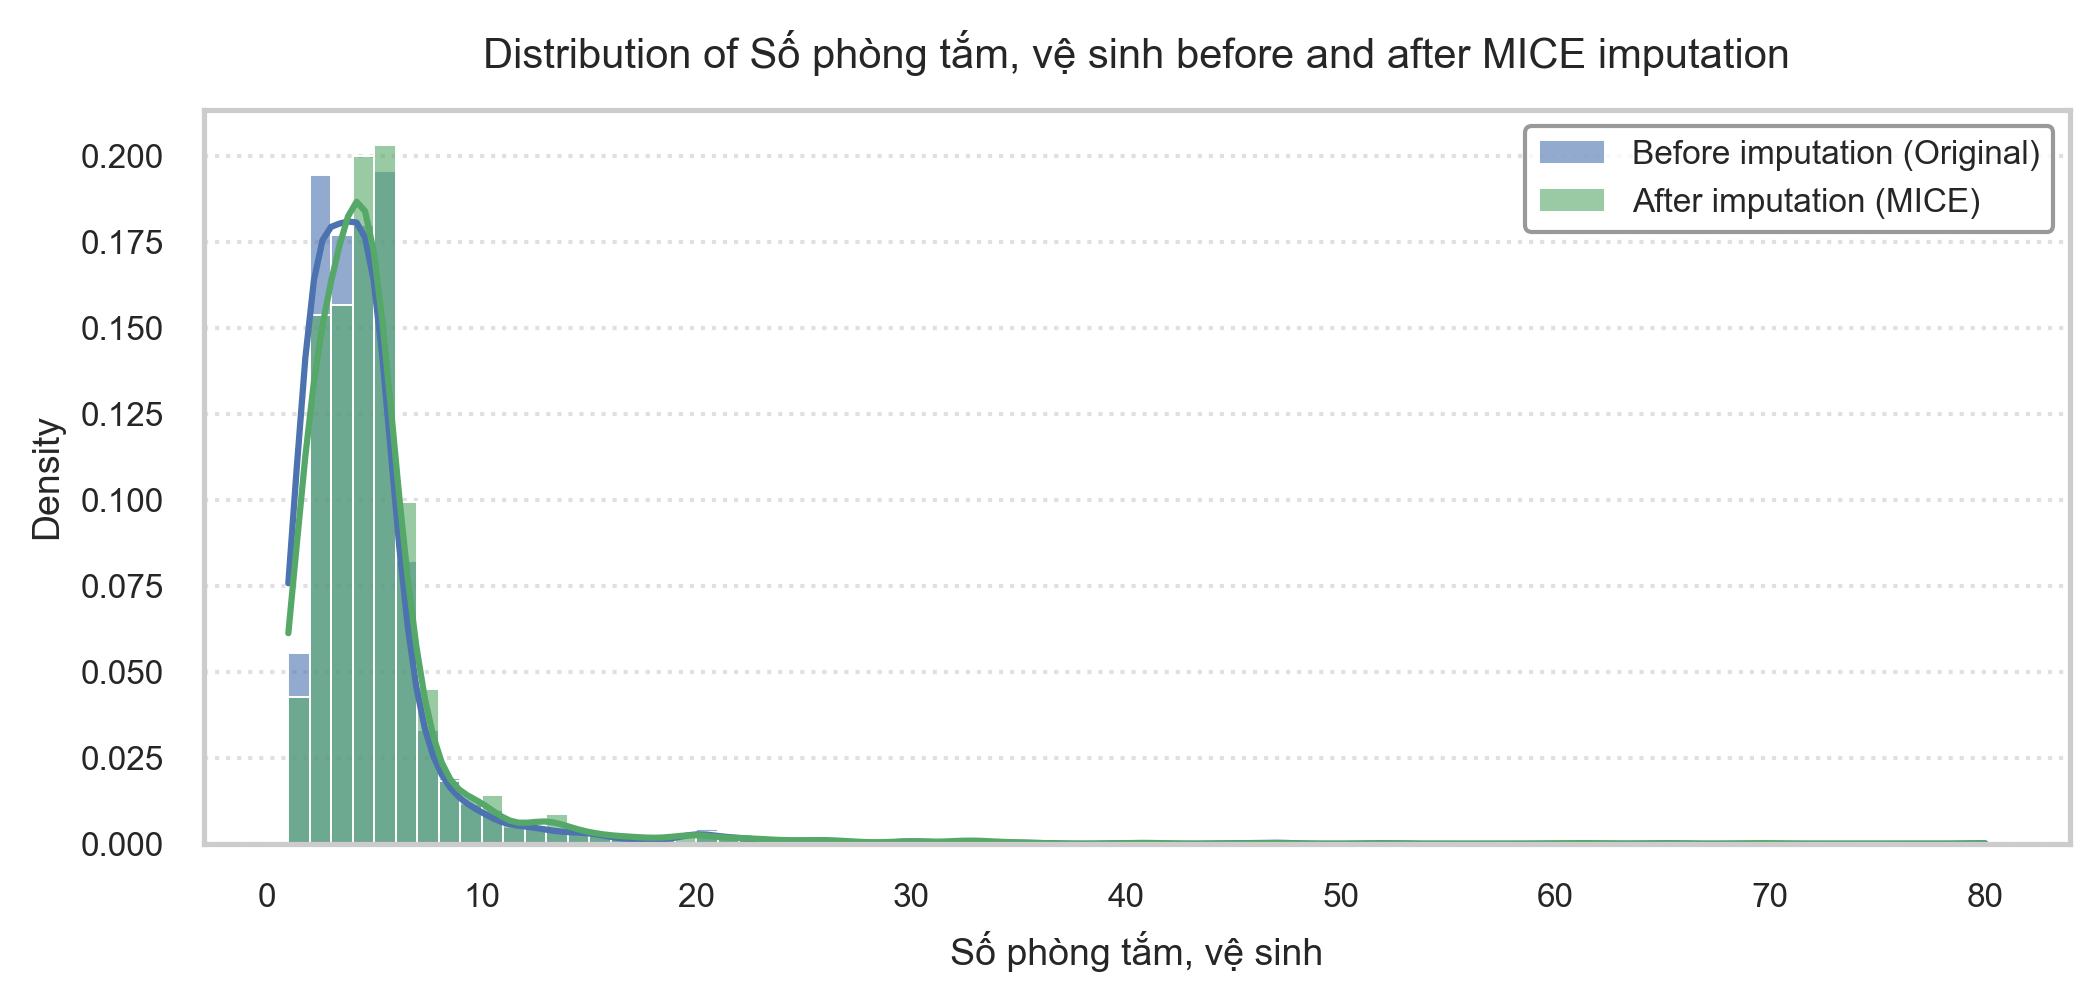

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import bắt buộc cho MICE trong sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from matplotlib.ticker import MaxNLocator # Thêm công cụ xử lý trục X hiển thị thông thoáng

# 1. Chọn các cột liên quan
features_to_use = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_train_sub = X_train[features_to_use].copy()

# 2. Khởi tạo MICE imputer với Random Forest
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
    max_iter=10,
    random_state=42 
)

# Điền khuyết 
X_train_imputed = pd.DataFrame(mice_imputer.fit_transform(X_train_sub), columns=features_to_use, index=X_train.index)

# 3. Làm tròn kết quả về số nguyên và LƯU TẠM
phong_tam_sau_khi_dien_mice = np.round(X_train_imputed['Số phòng tắm, vệ sinh']).astype(int)

# =========================================================
# 4. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE (MICE)
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Vẽ dữ liệu GỐC (Original - Bỏ qua NaN) - Màu xanh học thuật thống nhất
sns.histplot(
    X_train['Số phòng tắm, vệ sinh'].dropna(), 
    color='#4C72B0', 
    label='Before imputation (Original)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Vẽ dữ liệu SAU KHI ĐIỀN bằng MICE - Sử dụng tone xanh lá cây học thuật dịu mắt
sns.histplot(
    phong_tam_sau_khi_dien_mice, 
    color='#55A868', 
    label='After imputation (MICE)', 
    stat='density', 
    alpha=0.6, 
    binwidth=1, 
    kde=True,
    edgecolor='white',
    ax=ax
)

# Tinh chỉnh Tiêu đề và Nhãn trục (Cấu trúc tiếng Anh, giữ tên biến gốc, KHÔNG IN ĐẬM)
ax.set_title('Distribution of Số phòng tắm, vệ sinh before and after MICE imputation', fontsize=10, pad=10)
ax.set_xlabel('Số phòng tắm, vệ sinh', fontsize=9)
ax.set_ylabel('Density', fontsize=9)

# SỬA LỖI TRỤC X: Tự động chia khoảng cách mốc hiển thị hợp lý (tối đa ~10 mốc nguyên)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis='both', labelsize=8)

# Định dạng khung chú thích (Legend) gọn gàng
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')

# Lưới nền (Chỉ hiển thị các đường lưới ngang nét đứt mờ, tắt lưới dọc)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

# 5. XUẤT FILE CHUẨN XUẤT BẢN ĐỒNG BỘ
#plt.savefig('imputation_mice_bathrooms_density_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('imputation_mice_bathrooms_density_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

2 phương pháp điền khuyết có hiệu suất tương đương nhau.

In [61]:
X_train['Số phòng tắm, vệ sinh'] = phong_tam_sau_khi_dien_knn

Áp dụng lên tập test

In [62]:
# 1. Chọn 4 cột trên tập Test (Lúc này 'Số phòng ngủ' trên X_test đã được điền đầy đủ từ Cell Mới Số 1)
features_to_use_pt = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_test_sub = X_test[features_to_use_pt].copy()

# 2. Scale bằng scaler đã fit ở Cell 4 (Dùng transform)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_sub), 
    columns=features_to_use_pt, 
    index=X_test.index
)

# 3. Điền khuyết bằng knn_imputer đã fit ở Cell 4 (Dùng transform)
X_test_imputed_scaled = knn_imputer.transform(X_test_scaled)

# 4. Nghịch đảo scale
X_test_imputed = pd.DataFrame(
    scaler.inverse_transform(X_test_imputed_scaled), 
    columns=features_to_use_pt, 
    index=X_test.index
)

# 5. Chốt kết quả vào X_test
X_test['Số phòng tắm, vệ sinh'] = np.round(X_test_imputed['Số phòng tắm, vệ sinh']).astype(int)

In [63]:
print("=== KIỂM TRA SỐ PHÒNG TẮM SAU KHI ĐIỀN BẰNG KNN (X_test) ===")
print(f"Số lượng giá trị NaN còn lại trong cột Số phòng tắm, vệ sinh: {X_test['Số phòng tắm, vệ sinh'].isnull().sum()}")
print("\n5 dòng đầu tiên của Số phòng ngủ & Số phòng tắm trong X_test:")
display(X_test[['Số phòng ngủ', 'Số phòng tắm, vệ sinh']].head())

=== KIỂM TRA SỐ PHÒNG TẮM SAU KHI ĐIỀN BẰNG KNN (X_test) ===
Số lượng giá trị NaN còn lại trong cột Số phòng tắm, vệ sinh: 0

5 dòng đầu tiên của Số phòng ngủ & Số phòng tắm trong X_test:


,Số phòng ngủ,"Số phòng tắm, vệ sinh"
84,1,1
5875,4,6
787,4,5
4375,5,5
79,4,4


#### 2.2.3 Kiểm tra lại mối quan hệ tương quan sau khi điền khuyết.

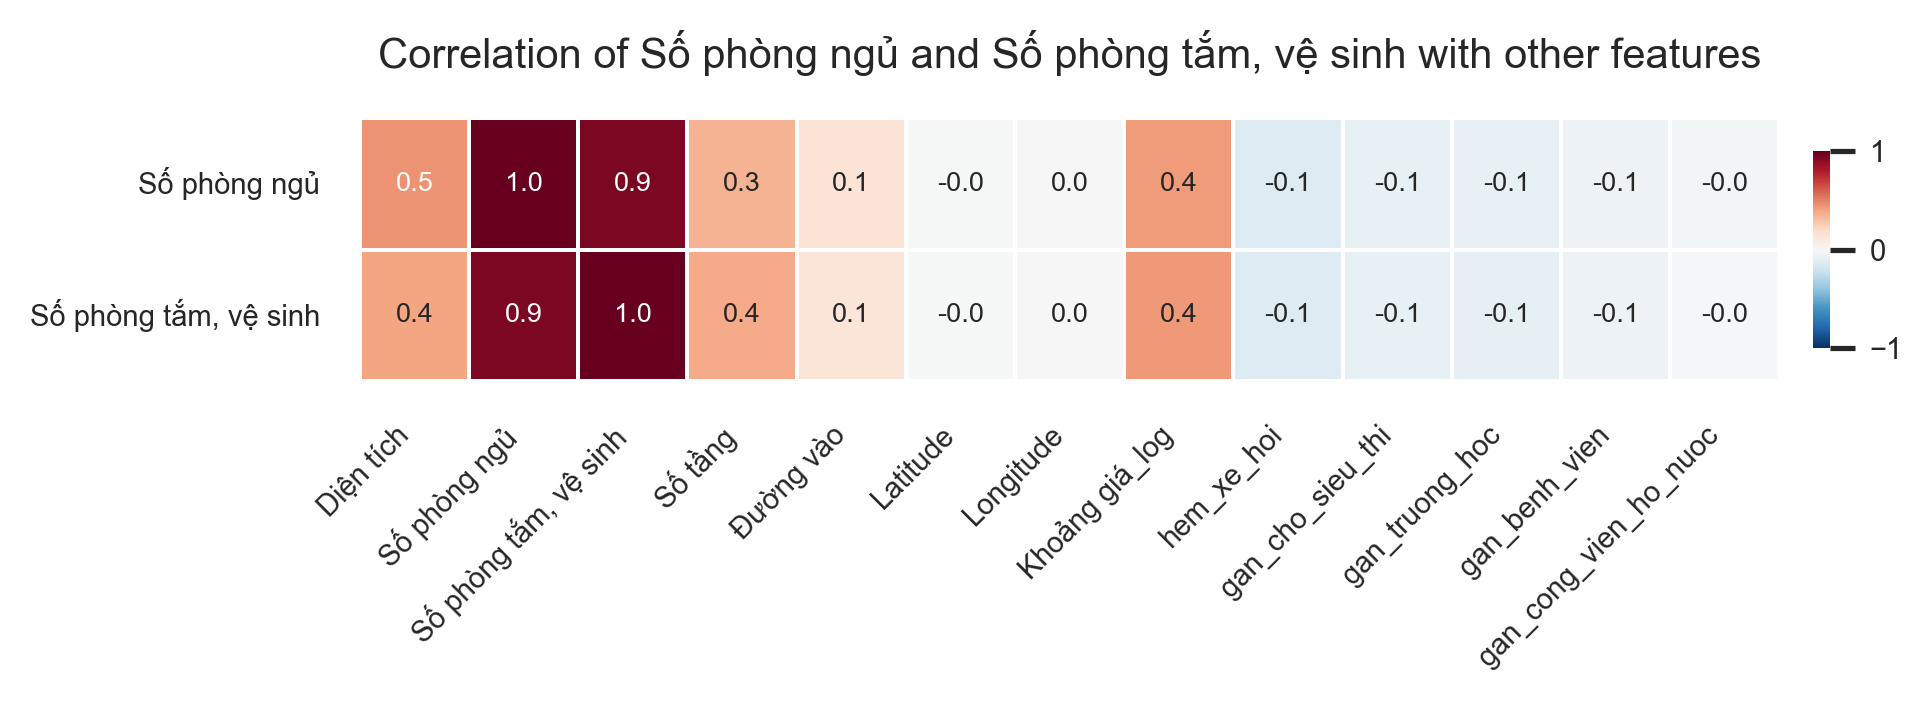

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lọc ra các cột dạng số (Numerical) bằng np.number cho ngắn gọn và chính xác
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# 2. Tính ma trận tương quan (Pearson) cho các biến số
correlation_matrix = X_train[numeric_cols].corr()

# 3. Lọc riêng phần tương quan của 2 biến quan tâm với các biến còn lại
target_vars = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']
target_vars = [col for col in target_vars if col in correlation_matrix.columns]

if target_vars:
    target_corr = correlation_matrix.loc[target_vars, :]

    # =========================================================
    # 4. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
    # =========================================================
    # Cài đặt phông chữ không chân (Sans-serif) và nhúng font vector PDF
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    # Chiều ngang chuẩn 7.16 inch, chiều cao 2.5 inch (vừa vặn tuyệt đối cho ma trận 2 hàng)
    fig, ax = plt.subplots(figsize=(7.16, 2.5), dpi=300)

    # Vẽ Heatmap
    sns.heatmap(
        target_corr, 
        annot=True,       
        cmap='RdBu_r',               # Đồng bộ bảng màu tương quan phân kỳ
        vmin=-1, vmax=1,             # Cố định thang đo từ -1 đến 1
        fmt=".1f",                   # Làm tròn 1 chữ số thập phân cho thoáng ô số
        linewidths=0.5, 
        linecolor='#ffffff',         # Đường viền trắng mảnh phân tách các ô
        annot_kws={"size": 6.5},     # Cỡ chữ số bên trong ô phù hợp khung hình nhỏ
        cbar_kws={"shrink": 0.75, "aspect": 12, "pad": 0.02}, # Thanh màu thanh mảnh, đẩy sát hình
        ax=ax
    )
    
    # Tiêu đề tiếng Anh, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
    ax.set_title('Correlation of Số phòng ngủ and Số phòng tắm, vệ sinh with other features', 
                 fontsize=10, pad=12)
    
    # Đồng bộ cỡ chữ nhãn trục trục (7pt)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
    
    # ĐỒNG BỘ: Thu nhỏ chữ số của thanh colorbar bên phải
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    
    # 5. XUẤT FILE VECTOR VÀ ẢNH CHẤT LƯỢNG CAO CHUẨN IN ẤN
    #plt.savefig('target_correlation_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
    #plt.savefig('target_correlation_ieee.png', format='png', bbox_inches='tight', dpi=600)
    plt.show()
else:
    print("Vui lòng đảm bảo 'Số phòng ngủ' và 'Số phòng tắm, vệ sinh' đang ở định dạng số (int/float).")

Ma trận tương quan có sự tương đồng lớn với ma trận tương quan ban đầu. Dữ liệu điền khuyết đã không phá hỏng mối quan hệ giữa các thuộc tính. Nhà to hơn đắt tiền hơn thường có nhiều phòng hơn.

- Nhận xét: Sự sụt giảm tỷ trọng tại đỉnh phân phối sau khi điền khuyết không phải là sai số của mô hình, mà phản ánh chính xác bản chất khuyết dữ liệu có quy luật (cơ chế MAR). Do các ô trống tập trung chủ yếu ở phân khúc bất động sản diện tích lớn hoặc tòa nhà nguyên căn, mô hình dự báo đã tính toán và lấp đầy bằng các giá trị lớn tương ứng (nhiều phòng tắm). Việc này làm tăng khối lượng dữ liệu ở phần đuôi đồ thị, dẫn đến hiệu ứng toán học tự nhiên là kéo giảm tỷ trọng tương đối (density) tại phần đỉnh. Kết quả này chứng minh thuật toán đã nắm bắt đúng logic thực tế của thị trường thay vì điền khuyết một cách máy móc theo số đông.

## 2.3 Xử lý missing value ở cột 'Số tầng'

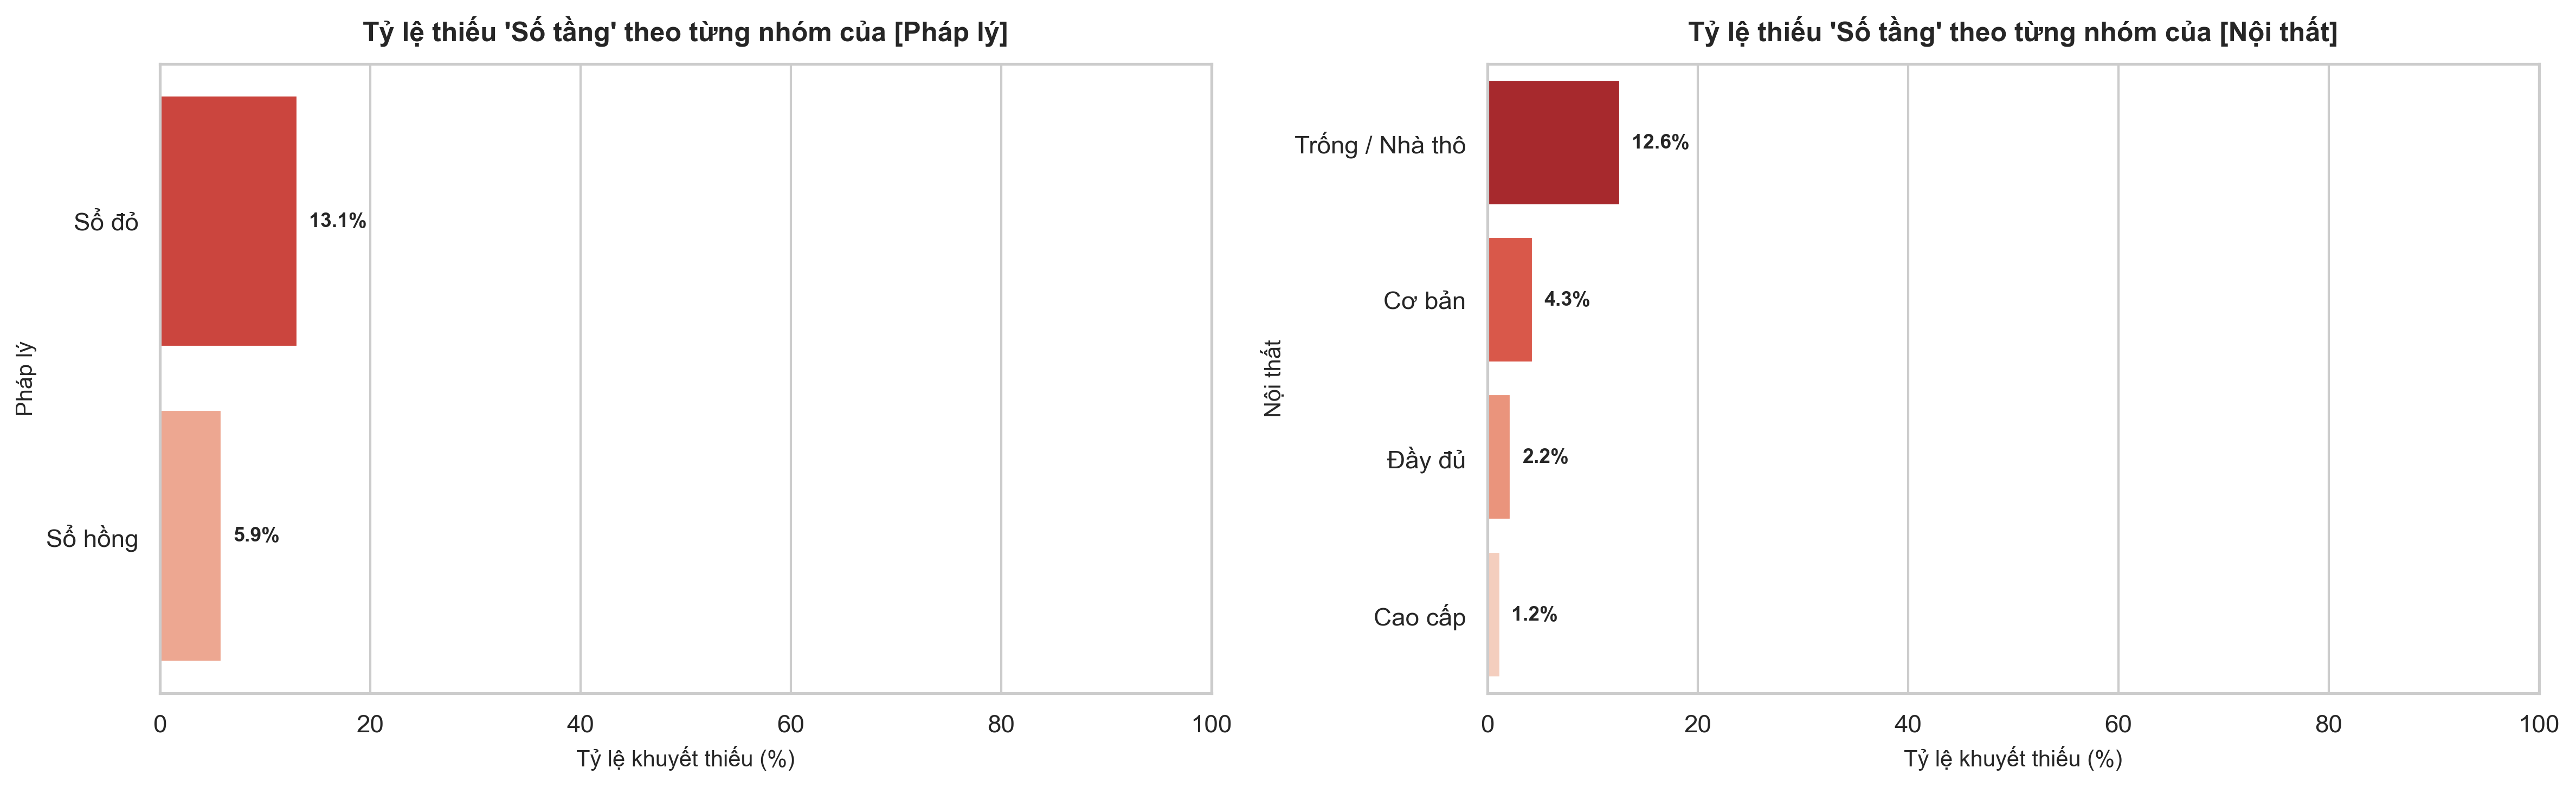

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đồ họa nét cao và hiển thị lưới nền
plt.rcParams['figure.dpi'] = 300
sns.set_theme(style="whitegrid")

# 1. Tạo một cột tạm thời: True nếu 'Số tầng' bị trống (NaN), False nếu có dữ liệu
df['_Is_So_Tang_Missing'] = df['Số tầng'].isnull()

# 2. Lựa chọn các cột danh mục tiêu biểu trong df của bạn để làm trục nhóm
# (Bỏ qua các cột định danh độc nhất như Link, hoặc quá chi tiết như Phường xã để tránh rối biểu đồ)
group_columns = ['Quan_Huyen', 'Pháp lý', 'Nội thất', 'Hướng nhà']
group_columns = [col for col in group_columns if col in df.columns]

# 3. Khởi tạo khung lưới chứa các biểu đồ con (Subplots)
n_plots = len(group_columns)
if n_plots > 0:
    # Bố trí tối đa 2 biểu đồ trên một hàng
    nrows = (n_plots + 1) // 2
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(16, 5 * nrows))
    axes = axes.flatten()  # Biến mảng 2 chiều thành 1 chiều để lặp dễ dàng

    for i, col in enumerate(group_columns):
        # Tính tỷ lệ thiếu (%) của 'Số tầng' theo từng nhóm trong cột hiện tại
        # Hàm .mean() trên cột Boolean sẽ tự động tính: (Số lượng True / Tổng số lượng) * 100
        missing_rate = df.groupby(col)['_Is_So_Tang_Missing'].mean().reset_index()
        missing_rate['_Is_So_Tang_Missing'] *= 100  # Đổi sang đơn vị %
        
        # Sắp xếp giảm dần để phân khúc nào thiếu nhiều nhất sẽ nhảy lên đầu
        missing_rate = missing_rate.sort_values(by='_Is_So_Tang_Missing', ascending=False)

        # Vẽ biểu đồ cột ngang (Barplot)
        sns.barplot(
            data=missing_rate,
            y=col,
            x='_Is_So_Tang_Missing',
            ax=axes[i],
            palette='Reds_r',  # Màu đỏ cảnh báo mức độ thiếu dữ liệu
            hue=col,
            legend=False
        )
        
        # Tinh chỉnh tiêu đề và nhãn hiển thị
        axes[i].set_title(f"Tỷ lệ thiếu 'Số tầng' theo từng nhóm của [{col}]", fontsize=12, fontweight='bold', pad=10)
        axes[i].set_xlabel("Tỷ lệ khuyết thiếu (%)", fontsize=10)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].set_xlim(0, 100)  # Thước đo luôn chạy từ 0% đến 100% để hiển thị khách quan

        # Điền số phần trăm trực tiếp lên cạnh mỗi cột cho dễ đọc
        for p in axes[i].patches:
            width = p.get_width()
            if width > 0:  # Chỉ hiển thị nhãn nếu nhóm đó có tỷ lệ thiếu lớn hơn 0%
                axes[i].annotate(f'{width:.1f}%', 
                                 (width, p.get_y() + p.get_height() / 2.),
                                 ha='left', va='center', 
                                 xytext=(5, 0), textcoords='offset points', fontsize=9, fontweight='bold')

    # Nếu số lượng cột là số lẻ, xóa ô đồ thị trống cuối cùng đi cho đẹp đội hình
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 4. Dọn dẹp: Xóa cột tạm thời vừa tạo để trả lại DataFrame nguyên bản sạch sẽ
df.drop(columns=['_Is_So_Tang_Missing'], inplace=True)

Cột 'Số tầng' đang thuộc loại MNAR:
- Đầy đủ" (37.73%): Chiếm đa số.
- "Trống / Nhà thô" (3.63%): Chiếm tỷ lệ rất thấp.
Mặc dù nhóm "Trống / Nhà thô" chỉ chiếm 3.63% tổng số mẫu, nhưng trước đó chúng ta đã thấy nó lại là nhóm có tỷ lệ thiếu Số tầng cao nhất (14.4%).

### 2.3.1 Thống kê phân phối và tìm outlier

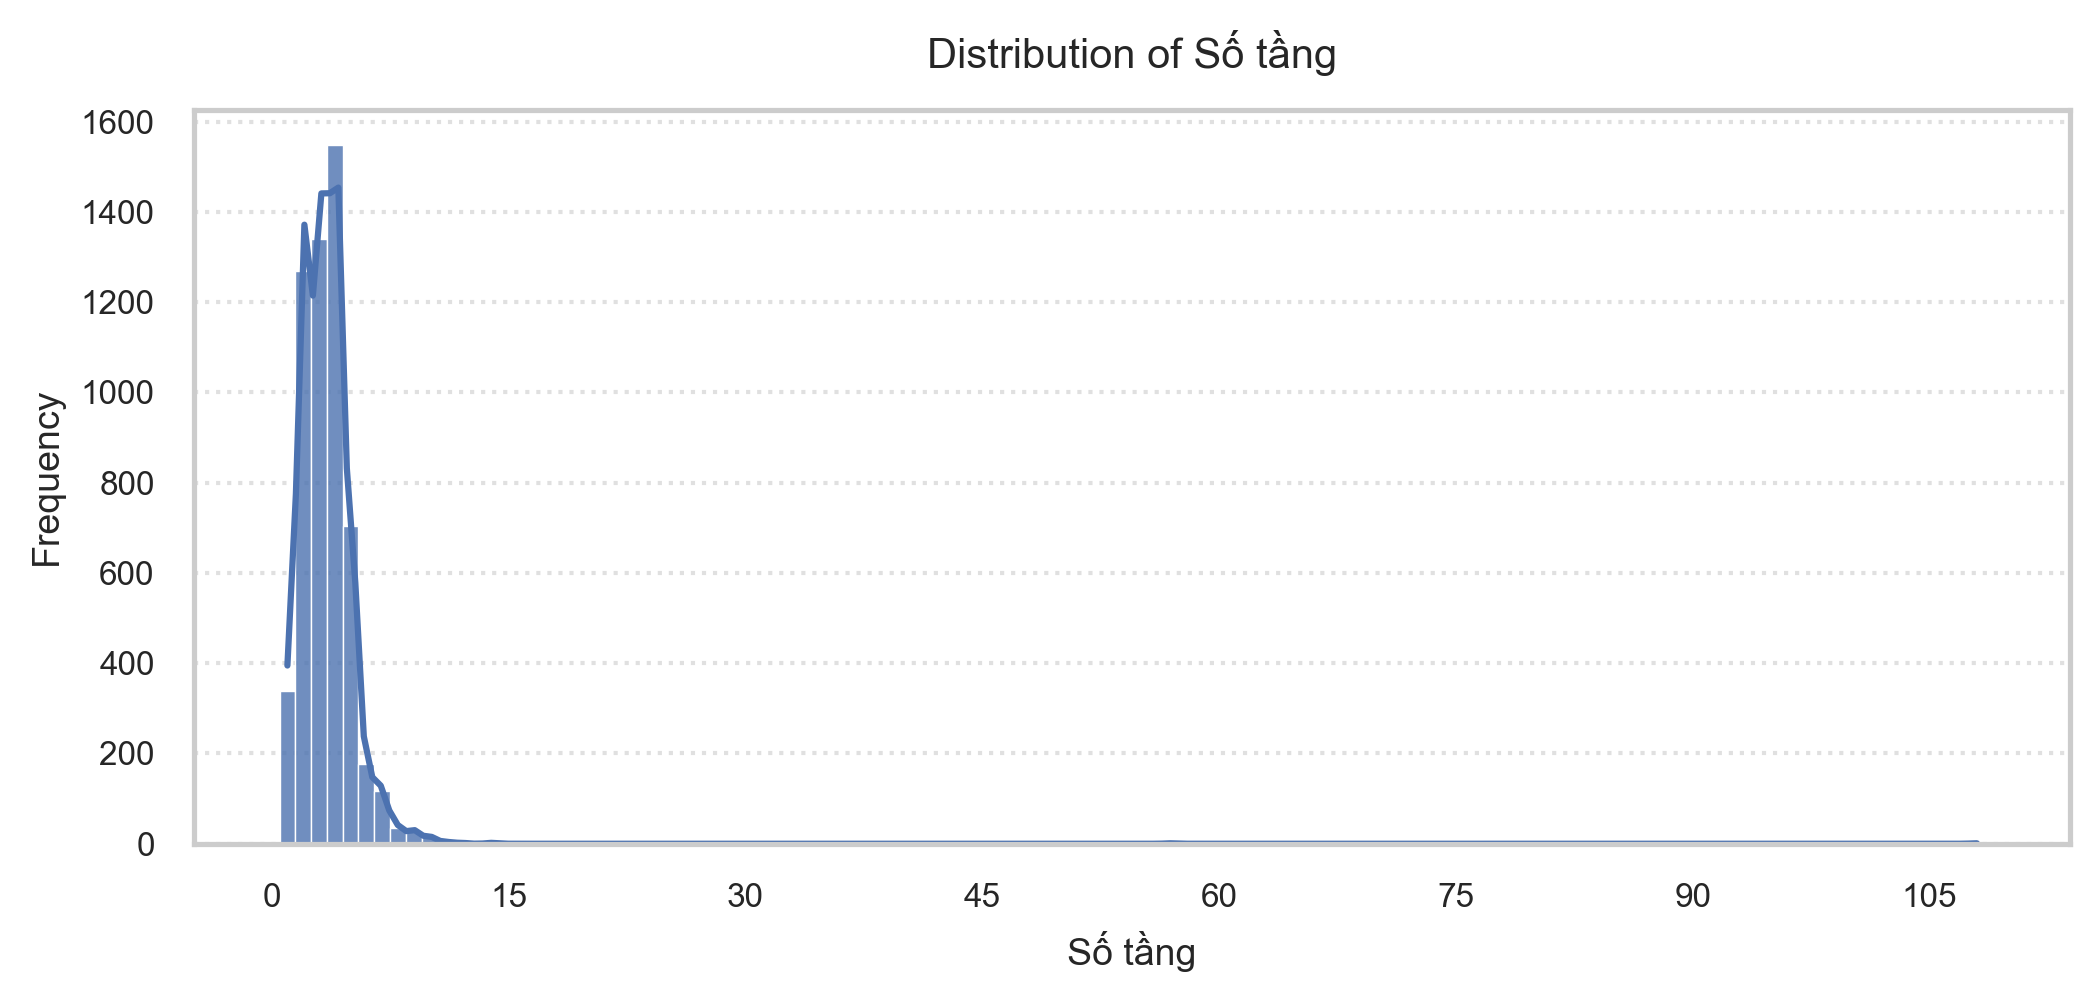

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator # Thêm công cụ sửa lỗi trùng nhãn trục X

# 1. Chuẩn bị dữ liệu: Loại bỏ NaN để biểu đồ không bị lỗi hiển thị
so_tang_clean = df['Số tầng'].dropna()

# =========================================================
# 2. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Vẽ histogram kết hợp đường KDE để xem xu hướng phân phối
sns.histplot(
    so_tang_clean, 
    discrete=True, 
    kde=True, 
    color='#4C72B0',      # Đồng bộ tone xanh học thuật từ các hình trước
    edgecolor='white',
    alpha=0.8,
    ax=ax
)

# Tinh chỉnh Tiêu đề và Nhãn trục (Tiếng Anh cấu trúc, giữ tên biến gốc, KHÔNG IN ĐẬM)
ax.set_title('Distribution of Số tầng', fontsize=10, pad=10)
ax.set_xlabel('Số tầng', fontsize=9)
ax.set_ylabel('Frequency', fontsize=9)

# SỬA LỖI TRỤC X: Tự động tính toán số mốc hiển thị hợp lý (tối đa ~10 mốc nguyên)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis='both', labelsize=8)

# Lưới nền (Chỉ hiển thị các đường ngang nét đứt siêu mờ để tránh rối mắt)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

# =========================================================
# 3. XUẤT FILE VECTOR CHẤT LƯỢNG CAO CHO BÁO CÁO KHOA HỌC
# =========================================================
#plt.savefig('distribution_so_tang_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('distribution_so_tang_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

In [66]:
import numpy as np
import pandas as pd

# Đảm bảo cột Số tầng không chứa giá trị khuyết khi tính toán boundaries
so_tang_clean = X_train['Số tầng'].dropna()

# =========================================================================
# PHƯƠNG PHÁP 1: Sử dụng IQR (Interquartile Range) - Tiêu chuẩn thống kê
# =========================================================================
Q1 = so_tang_clean.quantile(0.25)
Q3 = so_tang_clean.quantile(0.75)
IQR = Q3 - Q1
upper_bound_iqr = Q3 + 1.5 * IQR

# Lọc các hàng là outlier theo IQR
outliers_iqr = X_train[X_train['Số tầng'] > upper_bound_iqr]

print("--- PHÁT HIỆN BẰNG PHƯƠNG PHÁP IQR ---")
print(f"Giới hạn trên về số tầng (Thống kê): {upper_bound_iqr} tầng")
print(f"Số lượng bản ghi bị coi là outlier: {len(outliers_iqr)} / {len(X_train)}")


# =========================================================================
# PHƯƠNG PHÁP 2: Sử dụng Phân vị cao (99th Percentile) để tìm "Siêu Outlier"
# =========================================================================
# Phương pháp này giúp bạn tìm ra top 1% các tòa nhà cao nhất tập dữ liệu
threshold_99 = so_tang_clean.quantile(0.99)
outliers_extreme = X_train[X_train['Số tầng'] > threshold_99]

print("\n--- PHÁT HIỆN BẰNG PHÂN VỊ 99% ---")
print(f"Ngưỡng 99% của tập dữ liệu rơi vào: {threshold_99} tầng")
print(f"Số lượng siêu tòa nhà vượt ngưỡng 99%: {len(outliers_extreme)}")


# =========================================================================
# IN RA ĐỂ KIỂM TRA THỰC TẾ (BUSINESS LOGIC)
# =========================================================================
# Sắp xếp các bất động sản có số tầng từ cao nhất xuống thấp nhất để check xem 
# diện tích và giá của chúng có tương xứng với số tầng khổng lồ đó không.

print("\n=== TOP 10 BẢN GHI CÓ SỐ TẦNG CAO NHẤT ĐỂ KIỂM TRA ===")
cols_to_check = ['Link', 'Diện tích', 'Khoảng giá_log', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
# Lọc các cột có sẵn trong dữ liệu của bạn để tránh lỗi
cols_to_display = [col for col in cols_to_check if col in X_train.columns]

display(X_train.sort_values(by='Số tầng', ascending=False)[cols_to_display].head(10))

--- PHÁT HIỆN BẰNG PHƯƠNG PHÁP IQR ---
Giới hạn trên về số tầng (Thống kê): 7.0 tầng
Số lượng bản ghi bị coi là outlier: 70 / 4797

--- PHÁT HIỆN BẰNG PHÂN VỊ 99% ---
Ngưỡng 99% của tập dữ liệu rơi vào: 8.0 tầng
Số lượng siêu tòa nhà vượt ngưỡng 99%: 42

=== TOP 10 BẢN GHI CÓ SỐ TẦNG CAO NHẤT ĐỂ KIỂM TRA ===


,Link,Diện tích,Khoảng giá_log,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh"
5735,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,105.0,3.198673,57.0,5,4
116,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,368.0,6.478510,14.0,6,7
1372,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,368.0,6.552508,14.0,6,7
5443,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,240.0,6.111467,12.0,64,57
5000,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,600.0,5.634790,12.0,20,20
2715,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,204.0,5.476464,11.0,9,8
4314,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,780.0,4.488636,11.0,37,22
115,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,337.0,6.398595,11.0,60,57
4399,https://batdongsan.com.vn/ban-nha-mat-pho-phuo...,510.0,5.017280,11.0,5,5
3415,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,228.0,4.330733,10.0,100,57


Outlier này là lỗi trong quá trình thu thập dữ liệu. Xoá.

In [67]:
# 1. Định nghĩa link của bản ghi outlier cần xóa
target_link = "https://batdongsan.com.vn/ban-nha-biet-thu-lien-ke-vinhomes-green-paradise-xa-can-gio-tp-ho-chi-minh/50-dau-tien-suat-noi-bo-dac-ck-20-np-bt-mat-bien-gia-tu-4-ty-lh-pr44024453?vrs=1"

# 2. Lấy ra bộ chỉ mục (Index) của bản ghi đó từ df gốc
outlier_index = df[df['Link'] == target_link].index

# 3. Tiến hành xóa nếu tìm thấy
if not outlier_index.empty:
    print(f"📍 Tìm thấy bản ghi outlier tại index: {list(outlier_index)}")
    
    # Xóa trong df gốc
    df = df.drop(index=outlier_index)
    
    # Xóa đồng bộ trong tập Train (nếu bản ghi này lọt vào tập Train)
    X_train = X_train.drop(index=outlier_index, errors='ignore')
    y_train = y_train.drop(index=outlier_index, errors='ignore')
    
    # Xóa đồng bộ trong tập Test (nếu bản ghi này lọt vào tập Test)
    X_test = X_test.drop(index=outlier_index, errors='ignore')
    y_test = y_test.drop(index=outlier_index, errors='ignore')
    
    print("✅ Đã xóa thành công outlier khỏi df, X_train, y_train, X_test, và y_test!")
    
    # Kiểm tra lại kích thước tập dữ liệu để chắc chắn
    print(f"Kích thước X_train hiện tại: {X_train.shape}")
    print(f"Kích thước X_test hiện tại: {X_test.shape}")
else:
    print("❌ Không tìm thấy bản ghi nào trùng khớp với đường Link trên. Hãy kiểm tra lại khoảng trắng hoặc ký tự!")

❌ Không tìm thấy bản ghi nào trùng khớp với đường Link trên. Hãy kiểm tra lại khoảng trắng hoặc ký tự!


In [68]:
# 1. Tìm tất cả các chỉ mục (Index) của các bản ghi có Số tầng > 20
outlier_indices = df[df['Số tầng'] > 20].index

# 2. Tiến hành xóa nếu tìm thấy bất kỳ bản ghi nào thỏa mãn
if not outlier_indices.empty:
    print(f"📍 Tìm thấy {len(outlier_indices)} bản ghi outlier có số tầng > 20.")
    
    # Xóa trong df gốc
    df = df.drop(index=outlier_indices)
    
    # Xóa đồng bộ trong tập Train (errors='ignore' để bỏ qua nếu index đó nằm bên tập Test)
    X_train = X_train.drop(index=outlier_indices, errors='ignore')
    y_train = y_train.drop(index=outlier_indices, errors='ignore')
    
    # Xóa đồng bộ trong tập Test (errors='ignore' để bỏ qua nếu index đó nằm bên tập Train)
    X_test = X_test.drop(index=outlier_indices, errors='ignore')
    y_test = y_test.drop(index=outlier_indices, errors='ignore')
    
    print("✅ Đã xóa thành công toàn bộ outlier > 20 tầng khỏi df, X_train, y_train, X_test, và y_test!")
    
    # Kiểm tra lại kích thước tập dữ liệu sau khi xử lý
    print(f"-> Kích thước X_train hiện tại: {X_train.shape}")
    print(f"-> Kích thước X_test hiện tại: {X_test.shape}")
else:
    print("❌ Không tìm thấy bản ghi nào có số tầng lớn hơn 20 tầng trong dữ liệu!")

📍 Tìm thấy 2 bản ghi outlier có số tầng > 20.
✅ Đã xóa thành công toàn bộ outlier > 20 tầng khỏi df, X_train, y_train, X_test, và y_test!
-> Kích thước X_train hiện tại: (4796, 22)
-> Kích thước X_test hiện tại: (1199, 22)


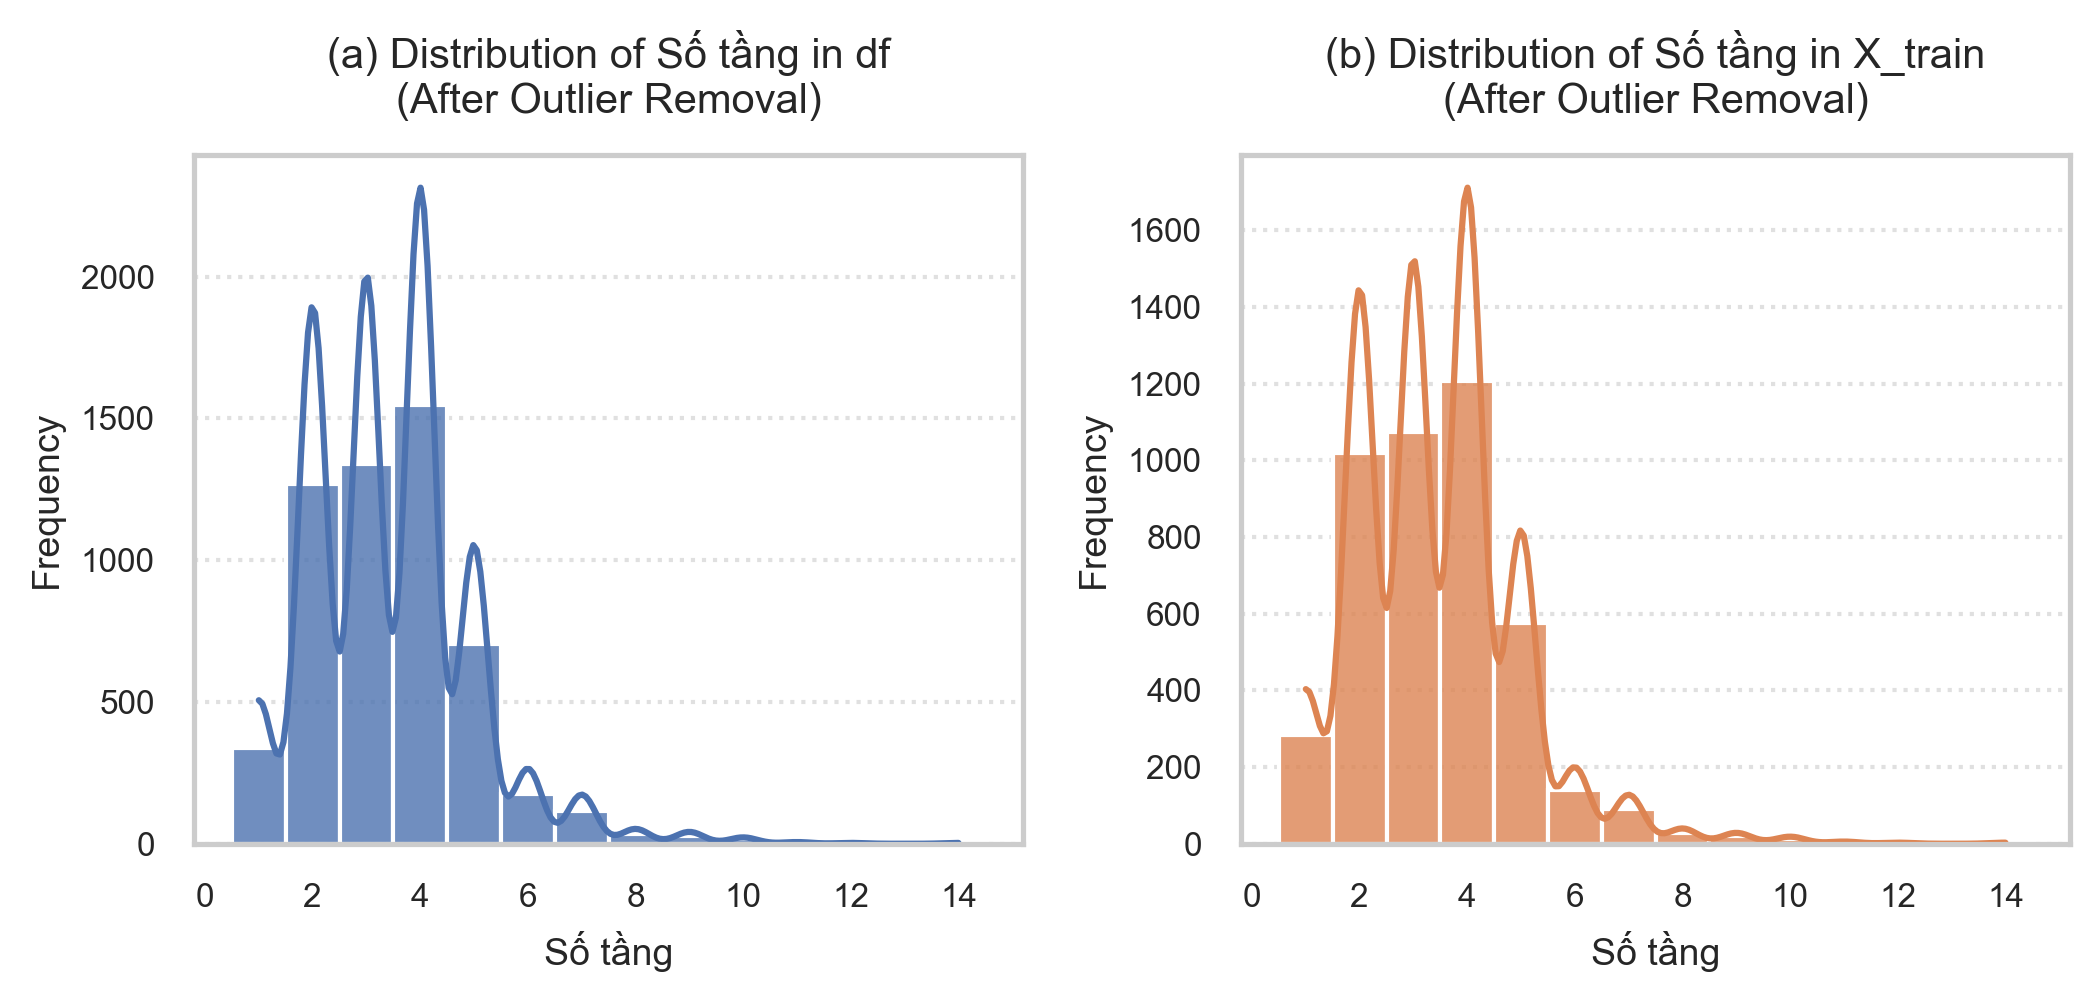

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator # Thêm công cụ sửa lỗi trùng nhãn trục X

# 1. Chuẩn bị dữ liệu sạch (Loại bỏ NaN để seaborn vẽ mượt mà hơn)
so_tang_df_clean = df['Số tầng'].dropna()
so_tang_train_clean = X_train['Số tầng'].dropna()

# =========================================================
# 2. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

# --- BIỂU ĐỒ (a): PHÂN PHỐI TRÊN DF GỐC ---
sns.histplot(
    so_tang_df_clean, 
    discrete=True, 
    kde=True, 
    color='#4C72B0', # Tone xanh dương học thuật
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)
# Cấu trúc tiếng Anh, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
axes[0].set_title('(a) Distribution of Số tầng in df\n(After Outlier Removal)', fontsize=10, pad=10)
axes[0].set_xlabel('Số tầng', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)

# SỬA LỖI TRỤC X: Tự động tính toán số mốc hiển thị hợp lý (tối đa ~10 mốc nguyên)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[0].tick_params(axis='both', labelsize=8)

# Lưới nền mờ (Tắt lưới dọc)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].grid(axis='x', visible=False)


# --- BIỂU ĐỒ (b): PHÂN PHỐI TRÊN TẬP X_TRAIN ---
sns.histplot(
    so_tang_train_clean, 
    discrete=True, 
    kde=True, 
    color='#DD8452', # Tone cam học thuật để phân biệt trực quan với df gốc
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)
# Cấu trúc tiếng Anh, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
axes[1].set_title('(b) Distribution of Số tầng in X_train\n(After Outlier Removal)', fontsize=10, pad=10)
axes[1].set_xlabel('Số tầng', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)

# SỬA LỖI TRỤC X
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[1].tick_params(axis='both', labelsize=8)

# Lưới nền mờ (Tắt lưới dọc)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

# Tinh chỉnh khoảng cách an toàn giữa các subplots
plt.tight_layout()

# =========================================================
# 3. XUẤT FILE VECTOR CHẤT LƯỢNG CAO CHO BÁO CÁO KHOA HỌC
# =========================================================
#plt.savefig('distribution_so_tang_comparison_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('distribution_so_tang_comparison_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

- Trong thị trường nhà phố tại các đô thị lớn như TP.HCM, phân phối số tầng thường không phải là đường cong hình chuông đều mà luôn bị chia cắt bởi 2 nhóm khách hàng/đối tượng chính:
    - Nhóm "Nhà nhỏ / Nhà hẻm" (Đỉnh ở 2 - 3 tầng): Đây thường là các căn nhà xây dựng từ lâu, nhà diện tích nhỏ (dưới 40m²), hoặc nằm sâu trong các hẻm nhỏ. Quy định xây dựng tại các hẻm này thường hạn chế chiều cao (chỉ được phép xây 2-3 tầng).
    - Nhóm "Nhà phố hiện đại" (Đỉnh ở 4 - 5 tầng): Đây là "tiêu chuẩn vàng" của nhà phố hiện nay. Thiết kế phổ biến là: 1 trệt + 1 lửng + 2 lầu + 1 sân thượng (tương đương 4-5 tầng). Những căn nhà ở mặt tiền hoặc hẻm lớn thường được phép xây dựng tối đa đến mức này để tối ưu hóa không gian.


- Ma trận tương quan của các biến cũng là một bằng chứng cho thấy số tầng chịu tác động mạnh của giá nhà, số phòng tắm và số phòng ngủ.

- Dựa vào ma trận tương quan của số lượng missing thì "Số tầng" missing không tương quan mạnh với các cột khác nên khả năng cao "Số tầng" là MCAR.

- Số lượng bản ghi bị thiếu không quá thấp (>5%)

- Với phân phối này không thể điền mean hay median vì sẽ làm mất hình dạng phân phối của dữ liệu (phân phối 2 đỉnh). Các mối tương quan cho thấy dùng mô hình nội suy đa biến sẽ có thể suy luận chính xác hơn.

- Kết luận: Sử dụng các mô hình để nội suy đa biến. 

- Chọn mô hình:
    - Dữ liệu rời rạc (số phòng tắm, số phòng ngủ), 
    - số phòng bị chia thành 2 nhóm. 
    - Dữ liệu lệch phải (do vẫn tồn tại các outlier 14 vốn là những outlier hợp lý).
- Các mô hình dựa trên nền tảng cây quyết định sẽ hiệu quả để dự đoán các mẫu này.


### 2.3.2 huấn luyện mô hình trên tập test và kiểm định 

📊 1. Trực quan hóa dữ liệu gốc bằng biểu đồ cột


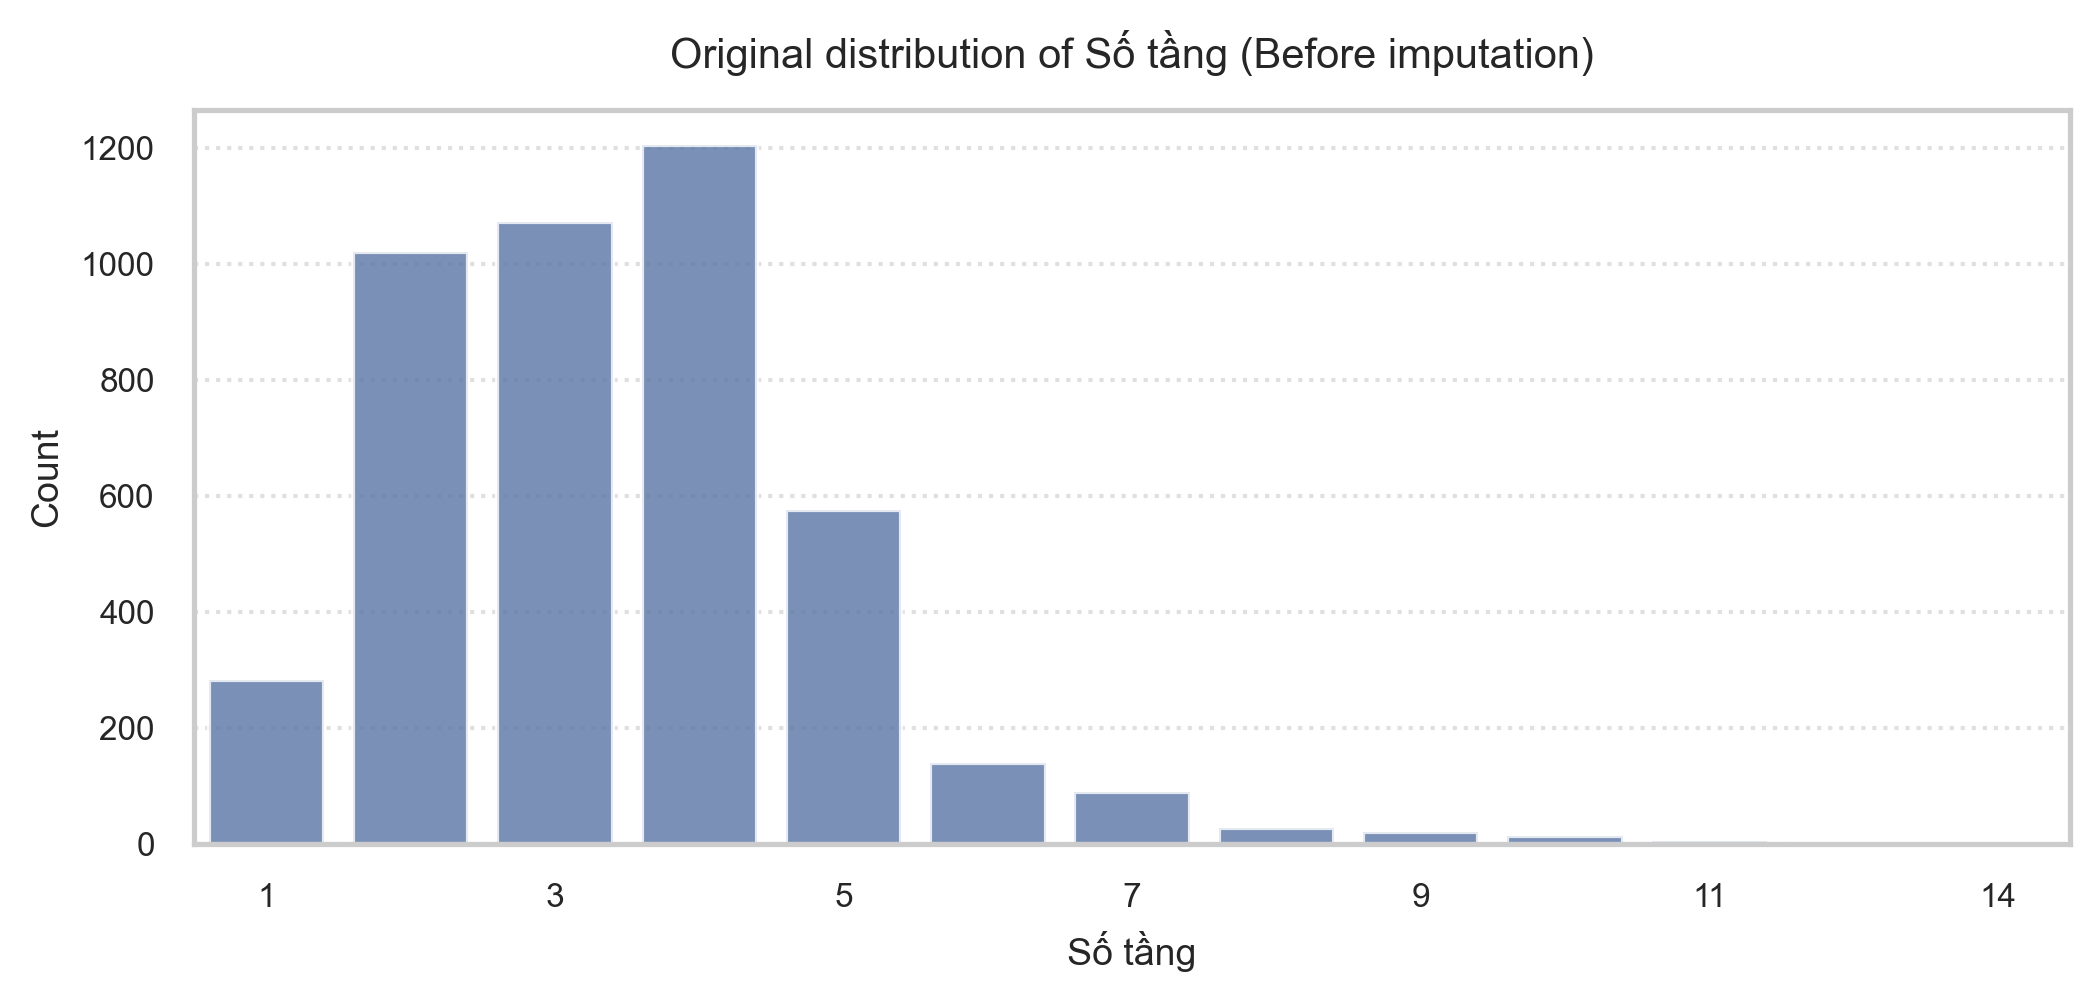


⏳ 2. Đang tiến hành chạy Random Forest Imputer. Vui lòng đợi...
✅ Hoàn tất điền khuyết! Số lượng NaN hiện tại: 0

📊 3. Đối chiếu phân phối Trước và Sau bằng Biểu đồ cột ghép (Grouped Bar Chart)


/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_91907/759639945.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')


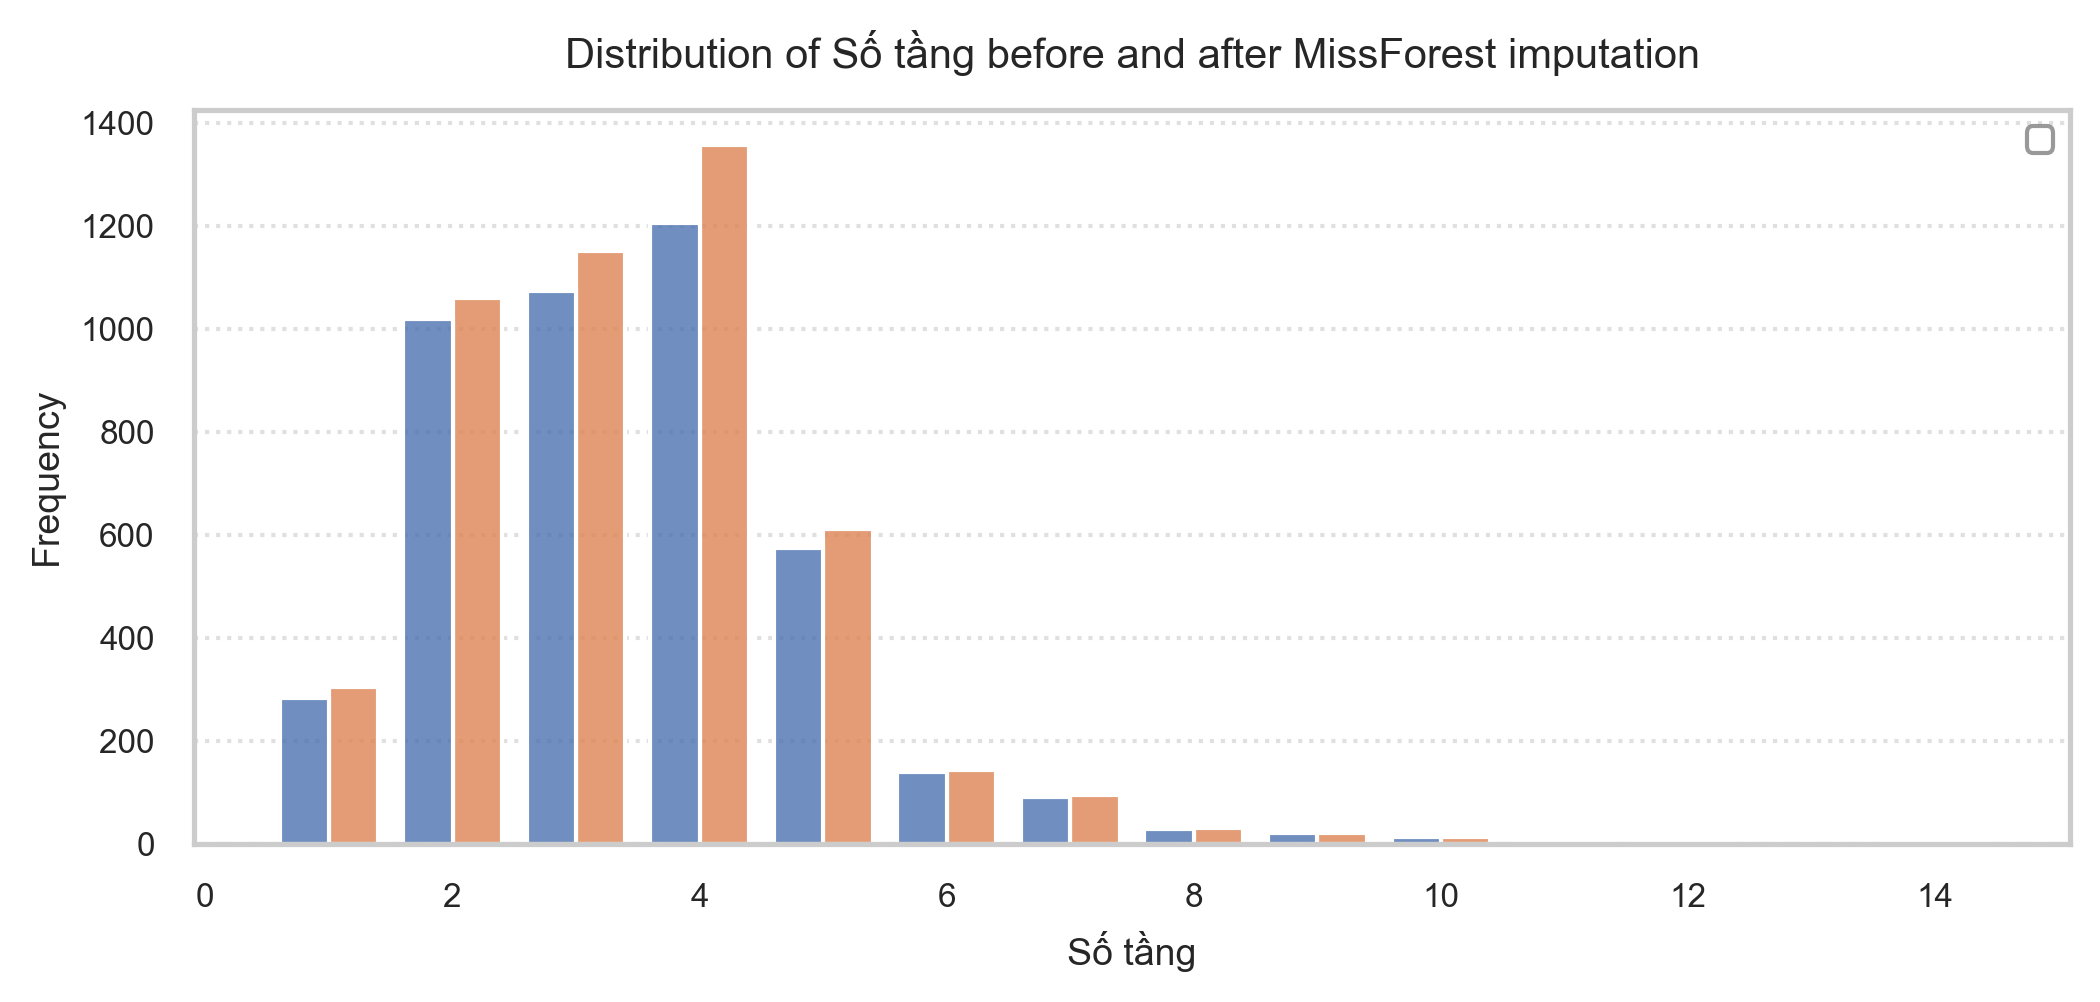

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import thư viện cần thiết cho MissForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from matplotlib.ticker import MaxNLocator # Thêm công cụ sửa lỗi trùng nhãn trục X

# Cấu hình phông chữ hệ thống và nhúng font vector PDF chuẩn IEEE
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# =========================================================================
# BƯỚC 1: VẼ BIỂU ĐỒ CỘT DỮ LIỆU GỐC (CHUẨN XUẤT BẢN)
# =========================================================================
print("📊 1. Trực quan hóa dữ liệu gốc bằng biểu đồ cột")
fig, ax1 = plt.subplots(figsize=(7.16, 3.5), dpi=300)

sns.countplot(
    x=X_train['Số tầng'].dropna().astype(int), 
    color='#4C72B0', 
    alpha=0.8,
    edgecolor='white',
    ax=ax1
)
# Định dạng chuẩn tiếng Anh học thuật, giữ tên biến gốc, KHÔNG IN ĐẬM
ax1.set_title('Original distribution of Số tầng (Before imputation)', fontsize=10, pad=10)
ax1.set_xlabel('Số tầng', fontsize=9)
ax1.set_ylabel('Count', fontsize=9)

# Tự động tối ưu mốc hiển thị trục X
ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax1.tick_params(axis='both', labelsize=8)

# Lưới nền mờ thanh lịch
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

# =========================================================================
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU & ÁP DỤNG MISSFOREST
# =========================================================================
print("\n⏳ 2. Đang tiến hành chạy Random Forest Imputer. Vui lòng đợi...")

features_for_rf = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']
X_train_rf = X_train[features_for_rf].copy()

rf_estimator = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
missforest_imputer = IterativeImputer(estimator=rf_estimator, max_iter=10, random_state=42, min_value=1)

X_train_imputed_array = missforest_imputer.fit_transform(X_train_rf)
X_train_imputed_df = pd.DataFrame(X_train_imputed_array, columns=features_for_rf, index=X_train.index)

X_train['Số tầng (MissForest)'] = np.round(X_train_imputed_df['Số tầng']).astype(int)

print("✅ Hoàn tất điền khuyết! Số lượng NaN hiện tại:", X_train['Số tầng (MissForest)'].isnull().sum())

# =========================================================================
# BƯỚC 3: VẼ BIỂU ĐỒ CỘT KÉP SO SÁNH CHUẨN XUẤT BẢN IEEE (SAU KHI ĐIỀN)
# =========================================================================
print("\n📊 3. Đối chiếu phân phối Trước và Sau bằng Biểu đồ cột ghép (Grouped Bar Chart)")
fig, ax2 = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Đồng bộ nhãn chú thích sang tiếng Anh học thuật trong DataFrame vẽ hình
plot_data = pd.DataFrame({
    'Before imputation (Original)': X_train['Số tầng'],
    'After imputation (MissForest)': X_train['Số tầng (MissForest)']
})

# Vẽ biểu đồ cột ghép (dodge) với bảng màu IEEE phối hợp
sns.histplot(
    data=plot_data,
    discrete=True,
    multiple="dodge",   
    shrink=0.8,         
    palette=['#4C72B0', '#DD8452'],
    alpha=0.8,
    edgecolor='white',
    ax=ax2
)

# Tiêu đề và nhãn trục chuẩn cấu trúc nghiên cứu quốc tế
ax2.set_title('Distribution of Số tầng before and after MissForest imputation', fontsize=10, pad=10)
ax2.set_xlabel('Số tầng', fontsize=9)
ax2.set_ylabel('Frequency', fontsize=9)

# SỬA LỖI TRỤC X: Tự động căn khoảng cách mốc chia, tránh đè chữ hoàn toàn
ax2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax2.tick_params(axis='both', labelsize=8)

# Định dạng khung chú thích gọn gàng
ax2.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')

# Tối ưu lưới nền (chỉ giữ lưới ngang siêu mờ)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.grid(axis='x', visible=False)

plt.tight_layout()

# XUẤT FILE ĐỒNG BỘ ĐỂ ĐƯA VÀO BÀI BÁO KHOA HỌC
#plt.savefig('imputation_missforest_so_tang_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('imputation_missforest_so_tang_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

# =========================================================
# CHỐT KẾT QUẢ (Bỏ dấu # ở 2 dòng dưới nếu phân phối đã khớp)
# X_train['Số tầng'] = X_train['Số tầng (MissForest)']
# X_train = X_train.drop(columns=['Số tầng (MissForest)'])
# =========================================================

Do mô hình tốt và số mẫu nhỏ nên phân phối khô bị lệch nhiều khi điền khuyết.

### 2.3.3 Áp dụng lên tập train và test

diền X_train

In [387]:
X_train['Số tầng'] = X_train['Số tầng (MissForest)']
X_train = X_train.drop(columns=['Số tầng (MissForest)'])

điền X_test

In [388]:
import numpy as np
import pandas as pd


# 1. Trích xuất đúng danh sách các cột đã dùng để huấn luyện mô hình trước đó
features_for_rf = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']
X_test_rf = X_test[features_for_rf].copy()

# 2. ÁP DỤNG QUY TẮC VÀNG: Chỉ dùng transform(), KHÔNG dùng fit_transform()
X_test_imputed_array = missforest_imputer.transform(X_test_rf)

# 3. Chuyển kết quả mảng numpy về lại dạng DataFrame để dễ xử lý
X_test_imputed_df = pd.DataFrame(
    X_test_imputed_array, 
    columns=features_for_rf, 
    index=X_test.index
)

# 4. Làm tròn thành số nguyên và ghi đè trực tiếp lên cột 'Số tầng' của X_test
X_test['Số tầng'] = np.round(X_test_imputed_df['Số tầng']).astype(int)

# 5. Kiểm tra lại kết quả nghiệm thu
print("✅ Hoàn tất điền khuyết cho X_test!")
print("-> Số lượng NaN của cột 'Số tầng' trong X_test hiện tại:", X_test['Số tầng'].isnull().sum())

# (Tùy chọn) Chốt kết quả cho tập X_train nếu bạn chưa chạy ở bước trước
if 'Số tầng (MissForest)' in X_train.columns:
    X_train['Số tầng'] = X_train['Số tầng (MissForest)']
    X_train = X_train.drop(columns=['Số tầng (MissForest)'])
    print("-> Đã chốt và làm sạch cột 'Số tầng' cho tập X_train.")

✅ Hoàn tất điền khuyết cho X_test!
-> Số lượng NaN của cột 'Số tầng' trong X_test hiện tại: 0


## 2.4 Xử lý cột 'Đường vào'

### 2.4.1 Phân phối và xử lý outlier

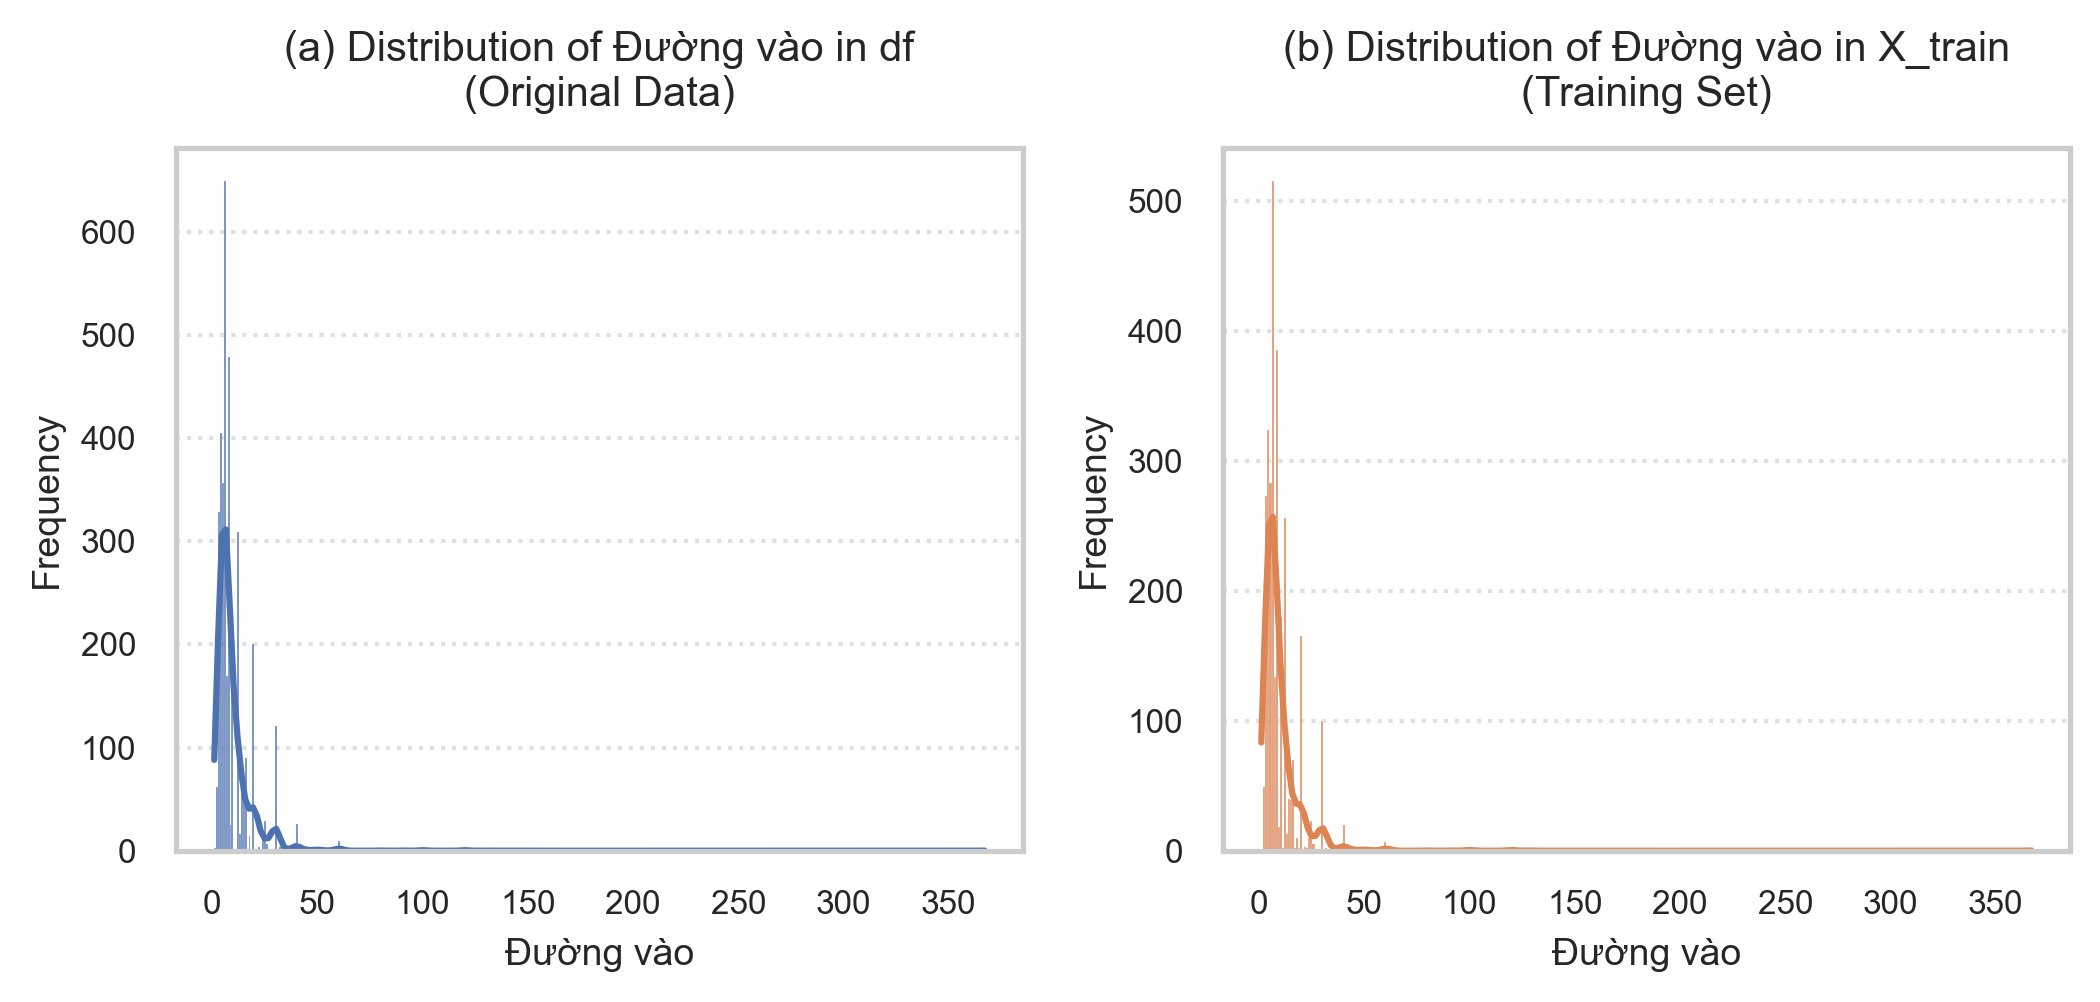

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator # Thêm công cụ tối ưu hóa nhãn trục X

# 1. Làm sạch dữ liệu NaN cho cột 'Đường vào'
duong_vao_df = df['Đường vào'].dropna()
duong_vao_train = X_train['Đường vào'].dropna()

# =========================================================
# 2. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

# --- BIỂU ĐỒ (a): PHÂN PHỐI ĐƯỜNG VÀO TRÊN DF GỐC ---
sns.histplot(
    duong_vao_df, 
    kde=True, 
    color='#4C72B0', # Tone xanh dương học thuật
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)
# Cấu trúc tiếng Anh, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
axes[0].set_title('(a) Distribution of Đường vào in df\n(Original Data)', fontsize=10, pad=10)
axes[0].set_xlabel('Đường vào', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)

# Tự động tối ưu mốc hiển thị trục X phù hợp với dữ liệu liên tục/bán liên tục
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[0].tick_params(axis='both', labelsize=8)

# Lưới nền mờ thanh lịch (Tắt lưới dọc để hình ảnh tinh gọn)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].grid(axis='x', visible=False)


# --- BIỂU ĐỒ (b): PHÂN PHỐI ĐƯỜNG VÀO TRÊN TẬP X_TRAIN ---
sns.histplot(
    duong_vao_train, 
    kde=True, 
    color='#DD8452', # Tone cam học thuật để phân biệt trực quan
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)
# Cấu trúc tiếng Anh, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
axes[1].set_title('(b) Distribution of Đường vào in X_train\n(Training Set)', fontsize=10, pad=10)
axes[1].set_xlabel('Đường vào', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)

# Tự động tối ưu mốc hiển thị trục X
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[1].tick_params(axis='both', labelsize=8)

# Lưới nền mờ thanh lịch (Tắt lưới dọc)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

# Tinh chỉnh khoảng cách an toàn giữa các subplots để không chồng lấn biên dữ liệu
plt.tight_layout()

# =========================================================
# 3. XUẤT FILE VECTOR CHẤT LƯỢNG CAO CHO BÁO CÁO KHOA HỌC
# =========================================================
#plt.savefig('distribution_duong_vao_comparison_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('distribution_duong_vao_comparison_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

In [390]:
import pandas as pd

# 1. Lọc ra các bản ghi có Đường vào lớn hơn 50m
outliers_duong_vao = df[df['Đường vào'] > 50]

# 2. In báo cáo số lượng mẫu vi phạm
print(f"📊 Tìm thấy tổng cộng: {len(outliers_duong_vao)} bản ghi có Đường vào > 50m\n")

if not outliers_duong_vao.empty:
    print("=== DANH SÁCH CHI TIẾT CÁC BẢN GHI OUTLIER ĐƯỜNG VÀO ===")
    
    # Lựa chọn các cột quan trọng để hiển thị và đối chiếu logic
    cols_to_display = [c for c in ['Link', 'Đường vào', 'Diện tích', 'Số tầng'] if c in df.columns]
    
    # Sắp xếp giảm dần theo độ rộng đường để xem căn nào "khủng" nhất trước
    display(outliers_duong_vao[cols_to_display].sort_values(by='Đường vào', ascending=False))
else:
    print("✅ Tuyệt vời! Không có bản ghi nào có Đường vào vượt quá 50m.")

📊 Tìm thấy tổng cộng: 24 bản ghi có Đường vào > 50m

=== DANH SÁCH CHI TIẾT CÁC BẢN GHI OUTLIER ĐƯỜNG VÀO ===


,Link,Đường vào,Diện tích,Số tầng
3681,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,367.0,367.0,6.0
5462,https://batdongsan.com.vn/ban-nha-rieng-duong-...,129.0,129.0,1.0
4221,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,120.0,144.0,8.0
3931,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,120.0,75.0,4.0
5953,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,120.0,75.0,4.0
4413,https://batdongsan.com.vn/ban-nha-rieng-pho-ph...,100.0,81.0,NaN
5468,https://batdongsan.com.vn/ban-nha-rieng-duong-...,100.0,72.0,2.0
5232,https://batdongsan.com.vn/ban-nha-rieng-duong-...,100.0,37.0,3.0
2904,https://batdongsan.com.vn/ban-nha-rieng-duong-...,90.0,42.0,3.0
2633,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,80.0,161.0,2.0


Các Outlier này là vô lý: Tại đô thị lớn như TP.HCM, đường phố rộng nhất (như đại lộ Võ Văn Kiệt, Nguyễn Văn Linh) cũng chỉ khoảng 40m - 60m.
Các outlier này là hậu quả cảu:
- lỗi khi crawldata
- Lỗi khi nhập liệu
- Xoá

In [74]:
# 1. Tìm tất cả các chỉ mục (Index) của các bản ghi có Đường vào > 50m
outlier_dv_indices = df[df['Đường vào'] > 50].index

# 2. Tiến hành xóa đồng bộ nếu tìm thấy bản ghi thỏa mãn
if not outlier_dv_indices.empty:
    print(f"📍 Phát hiện {len(outlier_dv_indices)} bản ghi outlier có Đường vào > 50m.")
    
    # Xóa trong df gốc
    df = df.drop(index=outlier_dv_indices)
    
    # Xóa đồng bộ trong tập Train (errors='ignore' để bỏ qua nếu index nằm bên tập Test)
    X_train = X_train.drop(index=outlier_dv_indices, errors='ignore')
    y_train = y_train.drop(index=outlier_dv_indices, errors='ignore')
    
    # Xóa đồng bộ trong tập Test (errors='ignore' để bỏ qua nếu index nằm bên tập Train)
    X_test = X_test.drop(index=outlier_dv_indices, errors='ignore')
    y_test = y_test.drop(index=outlier_dv_indices, errors='ignore')
    
    print("✅ Đã xóa thành công toàn bộ outlier > 50m khỏi df, X_train, y_train, X_test, và y_test!")
    
    # Kiểm tra lại kích thước tập dữ liệu sau khi xử lý để nghiệm thu
    print(f"-> Kích thước X_train hiện tại: {X_train.shape}")
    print(f"-> Kích thước X_test hiện tại: {X_test.shape}")
else:
    print("❌ Không tìm thấy bản ghi nào có Đường vào lớn hơn 50m trong dữ liệu!")

📍 Phát hiện 24 bản ghi outlier có Đường vào > 50m.
✅ Đã xóa thành công toàn bộ outlier > 50m khỏi df, X_train, y_train, X_test, và y_test!
-> Kích thước X_train hiện tại: (4774, 23)
-> Kích thước X_test hiện tại: (1197, 22)


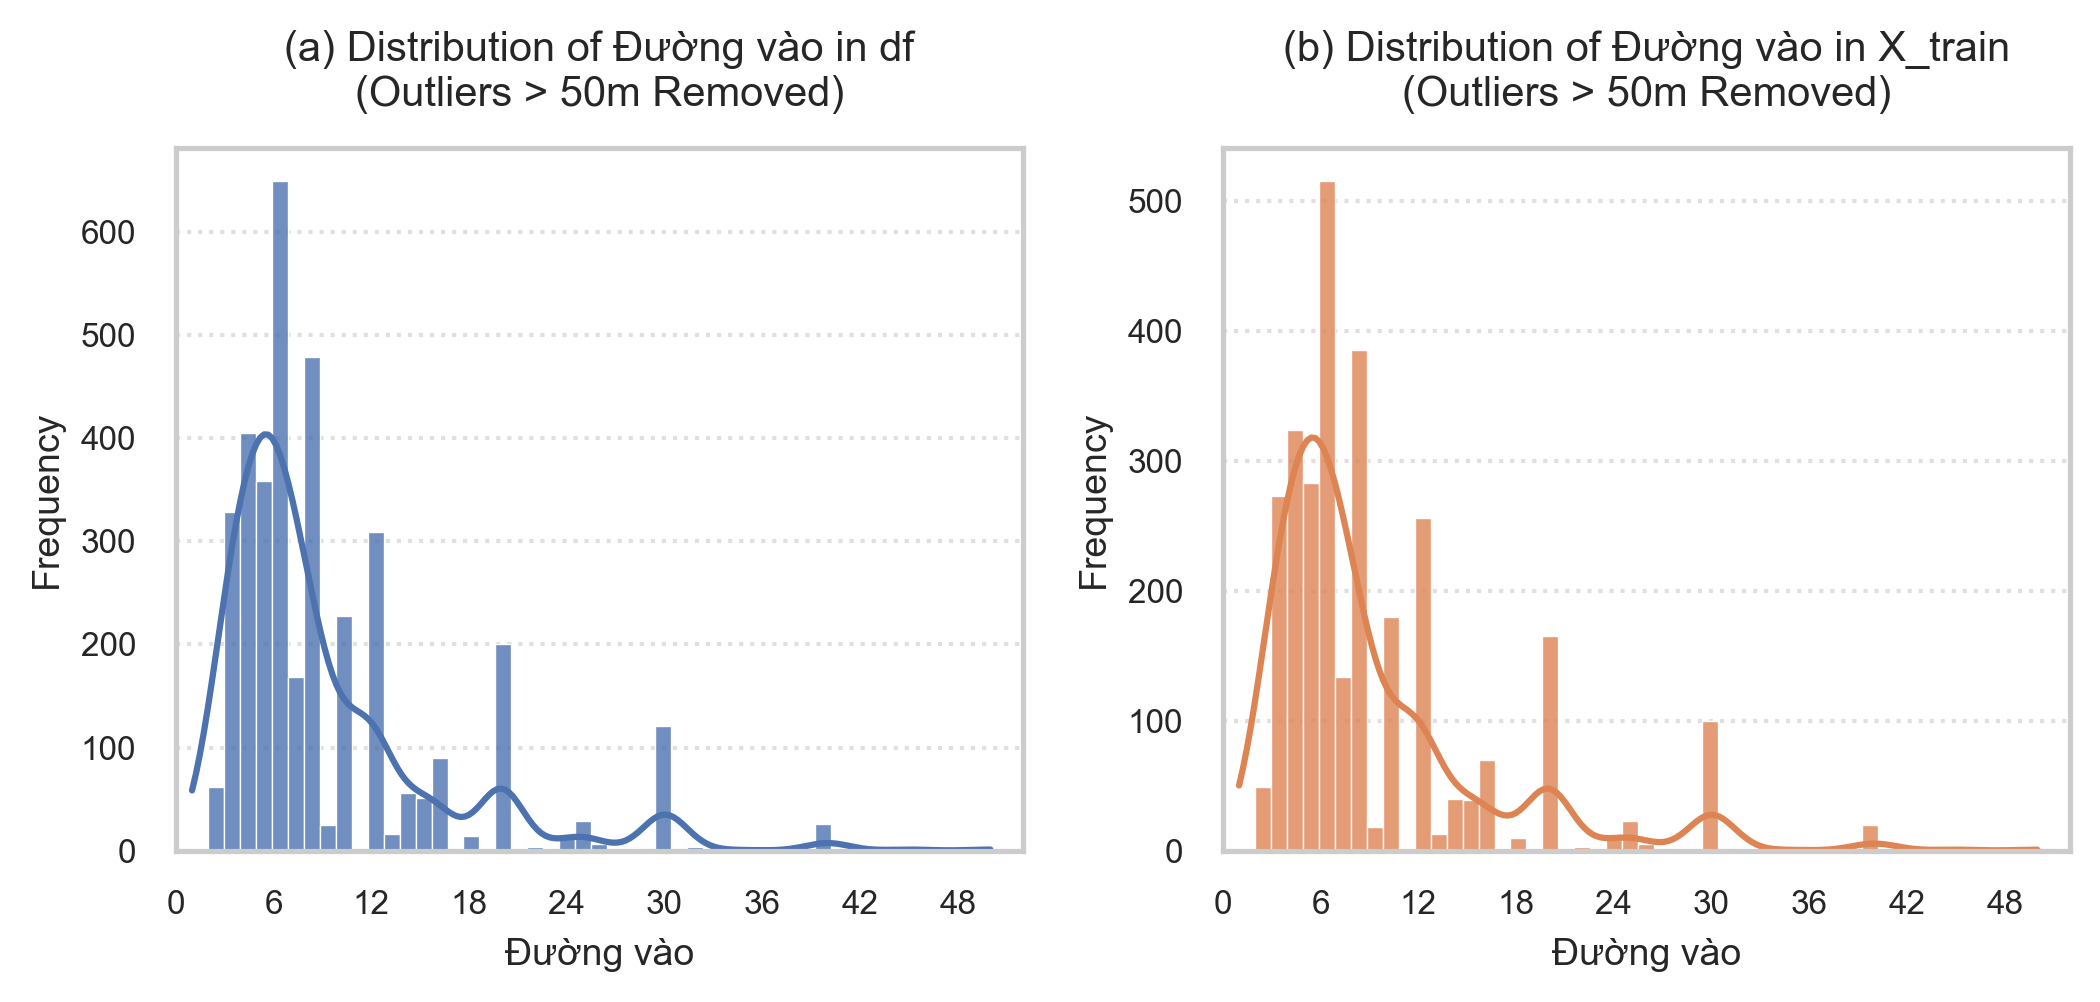

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator # Thêm công cụ tối ưu hóa nhãn trục X

# 1. Làm sạch tạm thời các giá trị NaN để tránh lỗi khi vẽ đường KDE
clean_df_dv = df['Đường vào'].dropna()
clean_train_dv = X_train['Đường vào'].dropna()

# =========================================================
# 2. CẤU HÌNH VÀ VẼ BIỂU ĐỒ CHUẨN XUẤT BẢN IEEE
# =========================================================
# Cài đặt phông chữ không chân (Sans-serif) và thiết lập nhúng font vector PDF
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Kích thước khung hình ngang chuẩn IEEE (7.16 inch tràn 2 cột), Cao 3.5 inch
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

# --- BIỂU ĐỒ (a): TẬP DF GỐC SAU KHI SẠCH OUTLIER ---
sns.histplot(
    clean_df_dv, 
    bins=50,              
    kde=True, 
    color='#4C72B0',     # Tone xanh dương học thuật thống nhất
    edgecolor='white', 
    alpha=0.8, 
    ax=axes[0]
)
# Cấu trúc tiếng Anh khoa học, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
axes[0].set_title('(a) Distribution of Đường vào in df\n(Outliers > 50m Removed)', fontsize=10, pad=10)
axes[0].set_xlabel('Đường vào', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)
axes[0].set_xlim(0, 52)   

# Tự động tối ưu mốc hiển thị trục X
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[0].tick_params(axis='both', labelsize=8)

# Lưới nền mờ thanh lịch (Tắt lưới dọc để hình ảnh tinh gọn)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].grid(axis='x', visible=False)


# --- BIỂU ĐỒ (b): TẬP X_TRAIN SAU KHI SẠCH OUTLIER ---
sns.histplot(
    clean_train_dv, 
    bins=50, 
    kde=True, 
    color='#DD8452',     # Tone cam học thuật để phân biệt trực quan
    edgecolor='white', 
    alpha=0.8, 
    ax=axes[1]
)
# Cấu trúc tiếng Anh khoa học, giữ tên biến gốc và LOẠI BỎ IN ĐẬM
axes[1].set_title('(b) Distribution of Đường vào in X_train\n(Outliers > 50m Removed)', fontsize=10, pad=10)
axes[1].set_xlabel('Đường vào', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)
axes[1].set_xlim(0, 52)   

# Tự động tối ưu mốc hiển thị trục X
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[1].tick_params(axis='both', labelsize=8)

# Lưới nền mờ thanh lịch (Tắt lưới dọc)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

# Tinh chỉnh khoảng cách an toàn giữa các subplots để tránh chồng lấn biên đồ thị
plt.tight_layout()

# =========================================================
# 3. XUẤT FILE VECTOR CHẤT LƯỢNG CAO CHO BÁO CÁO KHOA HỌC
# =========================================================
#plt.savefig('distribution_duong_vao_clean_comparison_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
#plt.savefig('distribution_duong_vao_clean_comparison_ieee.png', format='png', bbox_inches='tight', dpi=600)

plt.show()

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_63005/1987772312.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_63005/1987772312.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_63005/1987772312.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_63005/1987772312.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ti

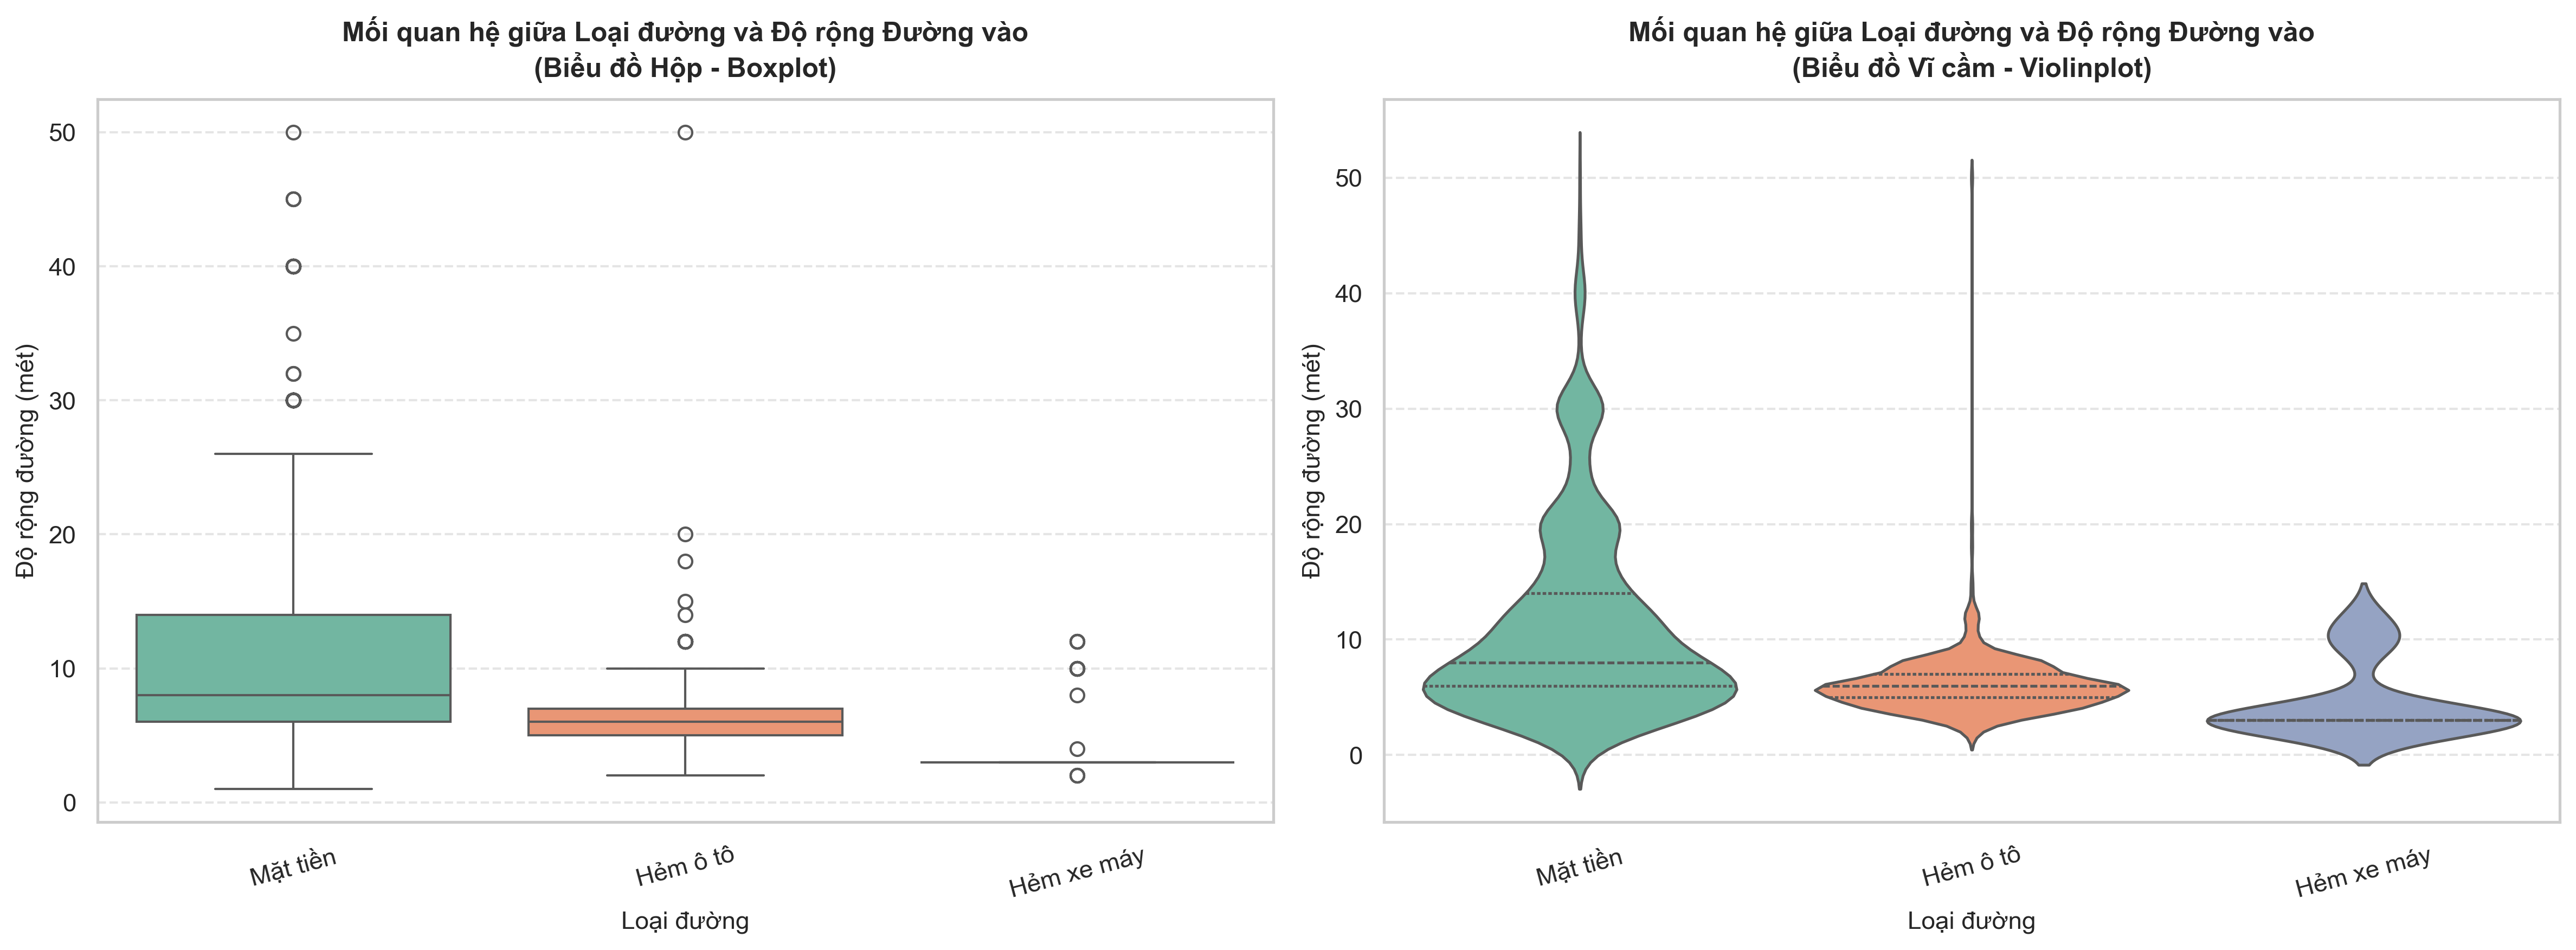

In [393]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lọc bỏ các hàng bị khuyết thiếu (NaN) ở cả 2 cột để biểu đồ vẽ chuẩn xác hơn
plot_data = X_train[['Loại đường vào', 'Đường vào']].dropna()

# 2. Khởi tạo khung nền gồm 2 biểu đồ nằm song song
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: BOXPLOT (Nhìn rõ Trung vị và các khoảng Tứ phân vị) ---
sns.boxplot(
    data=plot_data,
    x='Loại đường vào',
    y='Đường vào',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Mối quan hệ giữa Loại đường và Độ rộng Đường vào\n(Biểu đồ Hộp - Boxplot)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Loại đường', fontsize=11)
axes[0].set_ylabel('Độ rộng đường (mét)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Xoay nhãn trục X nếu tên các loại đường quá dài, tránh bị dính chữ
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)


# --- BIỂU ĐỒ 2: VIOLINPLOT (Nhìn rõ hình dáng phân phối mật độ dữ liệu) ---
sns.violinplot(
    data=plot_data,
    x='Loại đường vào',
    y='Đường vào',
    palette='Set2',
    inner='quartile', # Hiển thị thêm các đường nét đứt biểu diễn tứ phân vị bên trong vĩ cầm
    ax=axes[1]
)
axes[1].set_title('Mối quan hệ giữa Loại đường và Độ rộng Đường vào\n(Biểu đồ Vĩ cầm - Violinplot)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Loại đường', fontsize=11)
axes[1].set_ylabel('Độ rộng đường (mét)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Tối ưu khoảng cách hiển thị giữa các đồ thị
plt.tight_layout()
plt.show()

🔍 ĐANG PHÂN TÍCH HÀNH VI GIẤU THÔNG TIN 'Đường vào' THEO CÁC BIẾN SỐ HỌC...



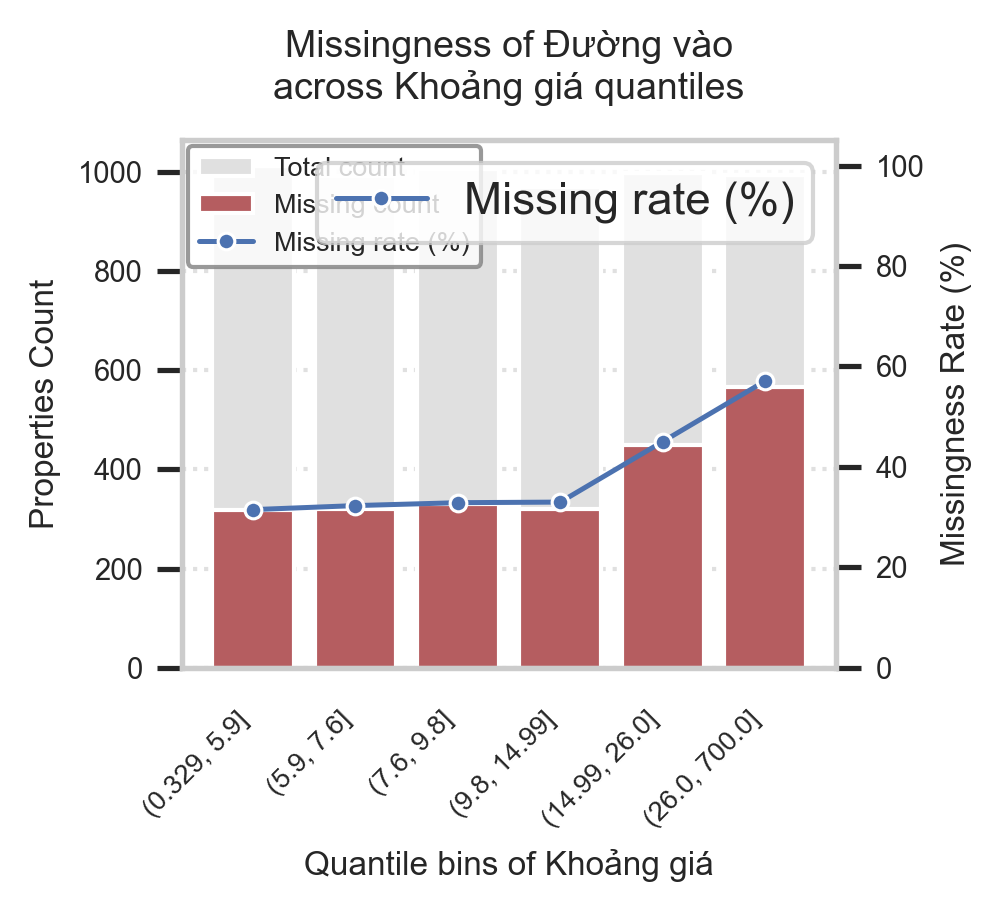

✅ Đã xuất biểu đồ 1 cột cho biến: Khoảng giá



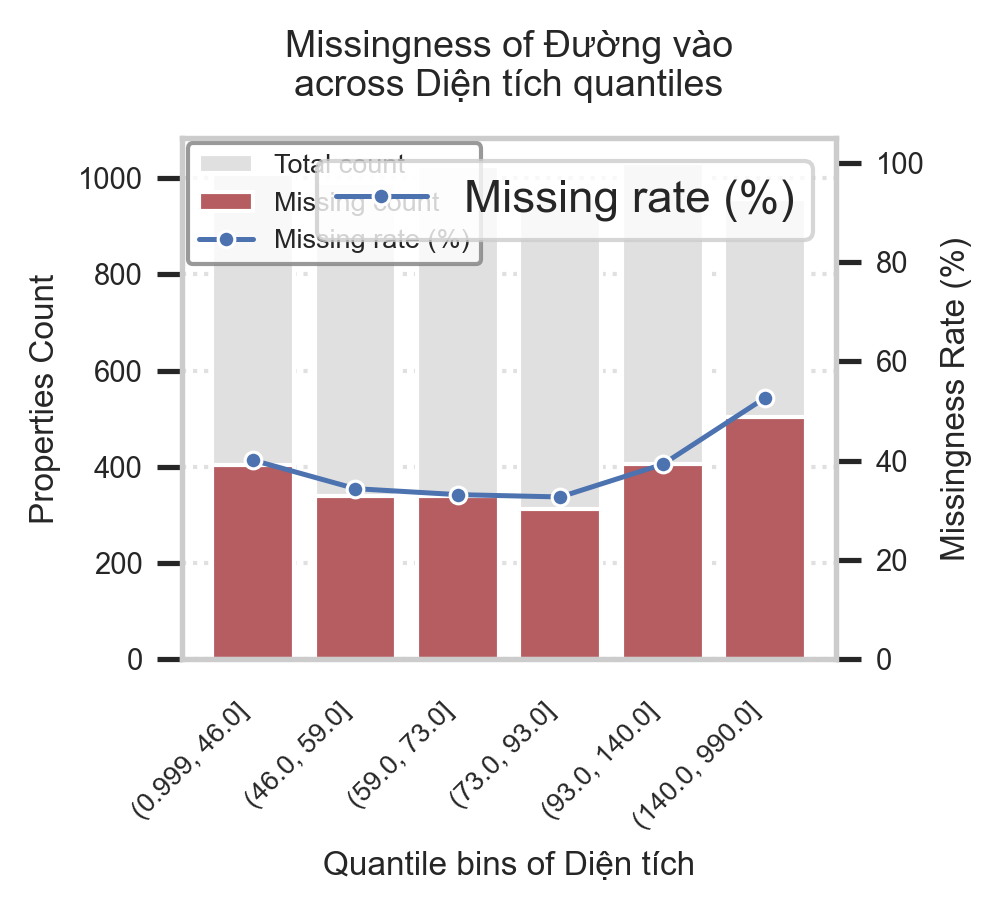

✅ Đã xuất biểu đồ 1 cột cho biến: Diện tích



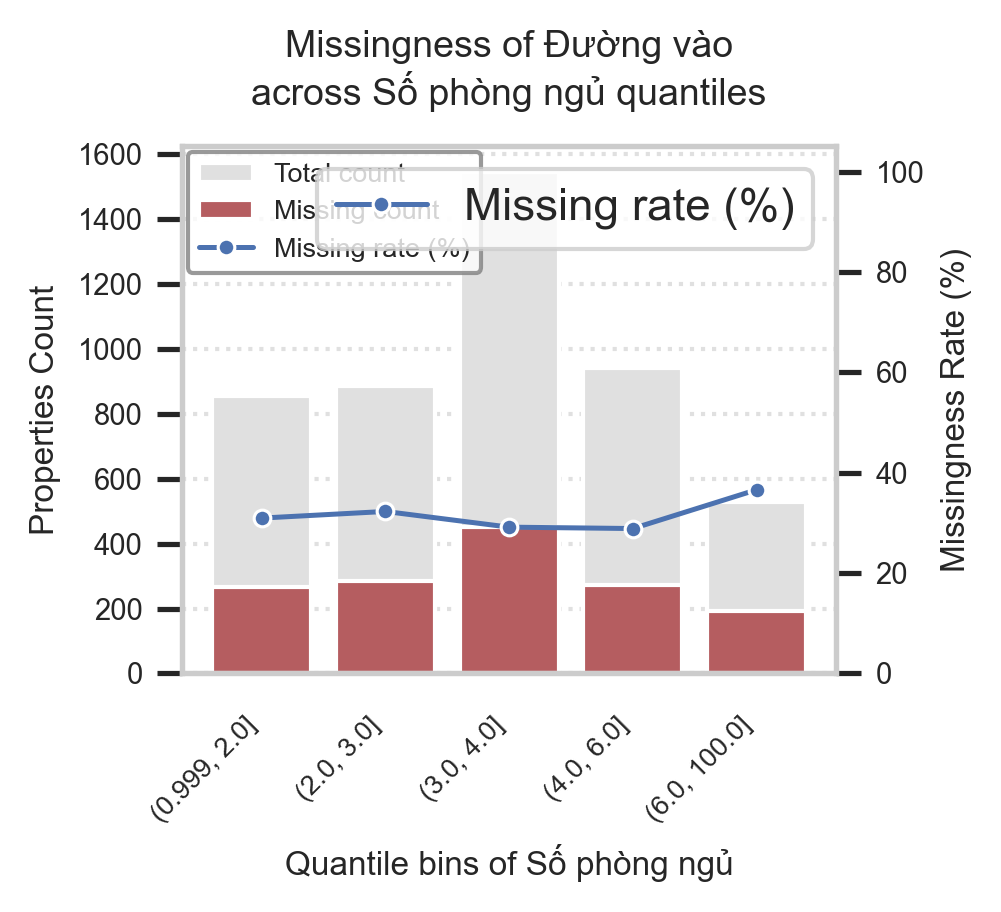

✅ Đã xuất biểu đồ 1 cột cho biến: Số phòng ngủ



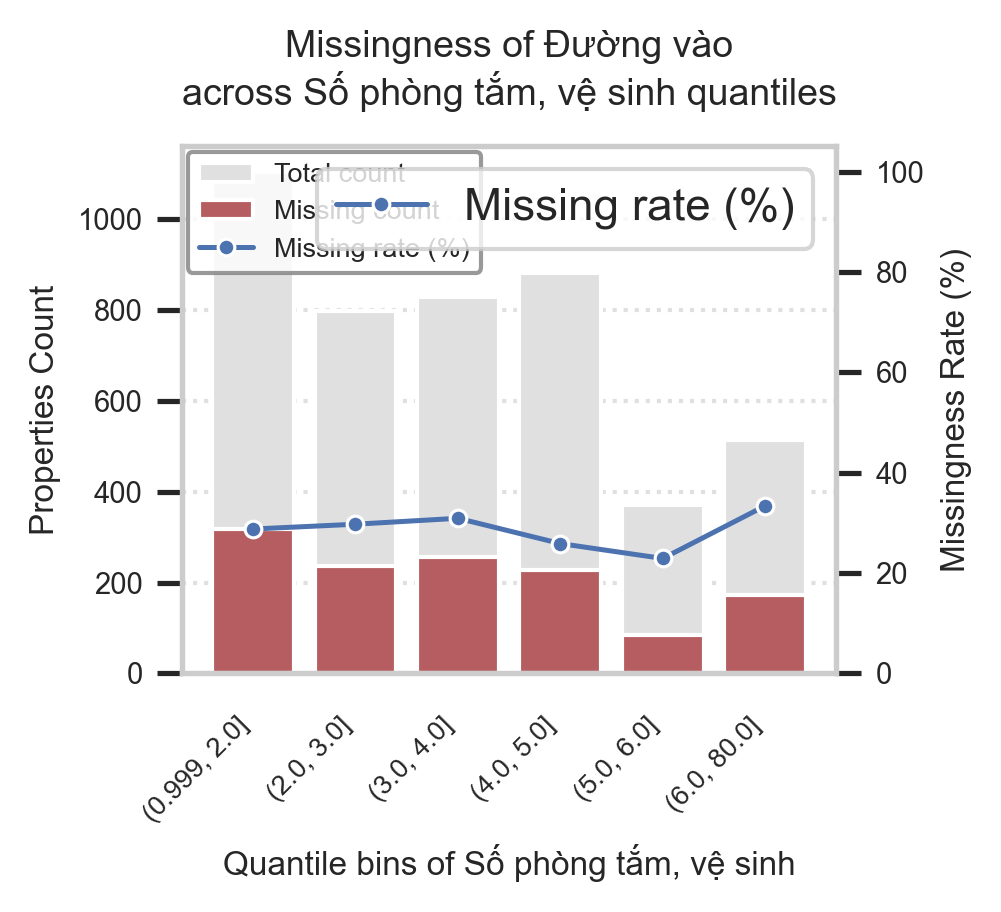

✅ Đã xuất biểu đồ 1 cột cho biến: Số phòng tắm, vệ sinh



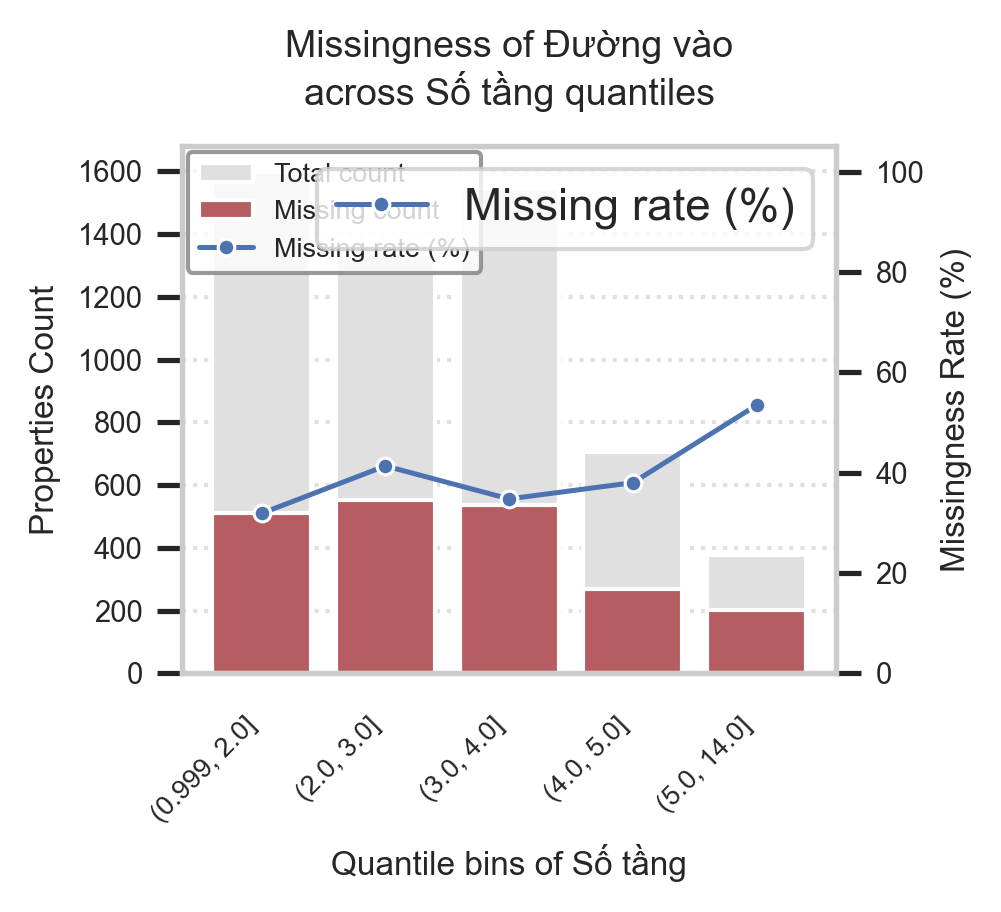

✅ Đã xuất biểu đồ 1 cột cho biến: Số tầng



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_missing_correlation_single_col(df, feature_cols, missing_col='Đường vào', q=6):
    """
    Hàm vẽ biểu đồ mối tương quan (Dual-axis) tối ưu cho 1 CỘT (Single-column)
    của bài báo khoa học chuẩn IEEE (Rộng 3.5 inches).
    """
    print(f"🔍 ĐANG PHÂN TÍCH HÀNH VI GIẤU THÔNG TIN '{missing_col}' THEO CÁC BIẾN SỐ HỌC...\n")
    
    # Cài đặt phông chữ không chân và nhúng font vector PDF chuẩn IEEE
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    
    for col in feature_cols:
        # 1. Tạo bản sao và loại bỏ các dòng bị khuyết ở biến đang xét
        df_plot = df.dropna(subset=[col]).copy()
        
        # 2. Chia phân khúc (Quantiles)
        df_plot['Phân_khúc'] = pd.qcut(df_plot[col], q=q, duplicates='drop')
        
        # 3. Tính toán thống kê
        missing_stats = df_plot.groupby('Phân_khúc', observed=False)[missing_col].agg(
            Tổng_số_nhà='size',
            Số_nhà_giấu_thông_tin=lambda x: x.isna().sum()
        ).reset_index()
        
        missing_stats['Tỷ_lệ_giấu_%'] = (missing_stats['Số_nhà_giấu_thông_tin'] / missing_stats['Tổng_số_nhà']) * 100
        
        # =========================================================
        # 4. CẤU HÌNH BIỂU ĐỒ CHUẨN 1 CỘT IEEE (Width = 3.5 inches)
        # =========================================================
        # Kích thước 3.5 x 3.2 inch (Nhỏ gọn, vuông vắn, vừa đúng 1 cột)
        fig, ax1 = plt.subplots(figsize=(3.5, 3.2), dpi=300)
        
        # --- TRỤC 1 (Cột): Số lượng tuyệt đối ---
        # Rút gọn label để legend không bị tràn trong không gian hẹp
        sns.barplot(
            data=missing_stats, x='Phân_khúc', y='Tổng_số_nhà', 
            color='#E0E0E0', ax=ax1, edgecolor='white', label='Total count'
        )
        sns.barplot(
            data=missing_stats, x='Phân_khúc', y='Số_nhà_giấu_thông_tin', 
            color='#C44E52', ax=ax1, edgecolor='white', label='Missing count'
        )
        
        # Thu nhỏ cỡ chữ nhãn trục (8pt)
        ax1.set_ylabel('Properties Count', fontsize=8)
        ax1.set_xlabel(f'Quantile bins of {col}', fontsize=8)
        ax1.tick_params(axis='y', labelsize=7)
        
        # SỬA LỖI TRỤC X 1 CỘT: Xoay 45 độ, thu nhỏ chữ xuống 6.5pt để vừa khung hẹp
        ax1.tick_params(axis='x', rotation=45, labelsize=6.5)
        plt.setp(ax1.get_xticklabels(), ha='right')
        
        # --- TRỤC 2 (Đường): Tỷ lệ khuyết thiếu ---
        ax2 = ax1.twinx()
        sns.lineplot(
            data=missing_stats, x=np.arange(len(missing_stats)), y='Tỷ_lệ_giấu_%', 
            color='#4C72B0', marker='o', markersize=4, linewidth=1.2, 
            ax=ax2, label='Missing rate (%)'
        )
        
        ax2.set_ylabel('Missingness Rate (%)', fontsize=8)
        ax2.tick_params(axis='y', labelsize=7)
        ax2.set_ylim(0, 105)
        
        # Lưới ngang mờ
        ax1.grid(axis='y', linestyle=':', alpha=0.6)
        ax1.grid(axis='x', visible=False)
        ax2.grid(visible=False)
        
        # Tiêu đề: Ngắt làm 2 dòng (\n) và hạ cỡ chữ (9pt) để không bị cắt mép
        ax1.set_title(f'Missingness of {missing_col}\nacross {col} quantiles', 
                     fontsize=9, pad=10)
        
        # HỢP NHẤT CHÚ THÍCH (LEGEND): Thu nhỏ tối đa và đẩy gọn vào góc
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.get_legend().remove()
        
        # borderaxespad=0.2 giúp legend nằm gọn gàng bên trong khung đồ thị
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                   fontsize=6.5, frameon=True, facecolor='white', edgecolor='gray',
                   borderaxespad=0.2)
        
        plt.tight_layout()
        
        # XUẤT FILE CHUẨN XUẤT BẢN
        #safe_col_name = col.replace(' ', '_').replace(',', '')
        #plt.savefig(f'missing_corr_singlecol_{safe_col_name}_ieee.pdf', format='pdf', bbox_inches='tight', dpi=600)
        #plt.savefig(f'missing_corr_singlecol_{safe_col_name}_ieee.png', format='png', bbox_inches='tight', dpi=600)
        
        plt.show()
        
        print(f"✅ Đã xuất biểu đồ 1 cột cho biến: {col}\n" + "="*50 + "\n")

# ==========================================
# THỰC THI
# ==========================================
cols_to_check = [
    'Khoảng giá', 
    'Diện tích', 
    'Số phòng ngủ', 
    'Số phòng tắm, vệ sinh', 
    'Số tầng'
]

# Gọi hàm với cấu hình 1 cột mới
plot_missing_correlation_single_col(df, cols_to_check, missing_col='Đường vào', q=6)

MAR:
- Nhà có giá càng cao thường không nằm trong hẻm hoặc là năm ở các vị trí địa lý đặc biệt (sông, biển, núi,..)
- Ngoài ra sự khuyết thiếu của 'ĐƯờng vào' con phụ thuộc vào nhiều biến khác như: 'Diện tích' , 'Số tâng',... Các biến này trước tiếp ảnh hưởng tới giá nhà mà giá nhà thì ảnh huuowngr tới tỉ lệ =khuyết thiếu của độ rộng đường. 
- Sự khuyết thiếu dữ liệu "Đường vào" không hề ngẫu nhiên (MCAR) mà nó phụ thuộc rất mạnh vào quy mô của bất động sản. Nhà càng to, càng nhiều tầng, nhiều phòng thì người đăng tin càng có xu hướng bỏ trống cột "Đường vào". Điều này hoàn toàn logic với thực tế: những căn nhà quy mô lớn thường là biệt thự hoặc nhà mặt phố lớn, nơi độ rộng ngõ không còn là yếu tố cần bận tâm.

phân phối bị sai lệch. Thử nghiệm nội suy bằng MICE và KNN

In [395]:
print(X_train.columns)

Index(['Link', 'Địa chỉ', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh',
       'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude',
       'Mô tả', 'Loại đường vào', 'Khoảng giá_log', 'hem_xe_hoi',
       'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'Đường', 'Phường/Xã/Thị Trấn', 'Quận'],
      dtype='object')


🔍 ĐANG CHẠY THỬ NGHIỆM KNN IMPUTER...


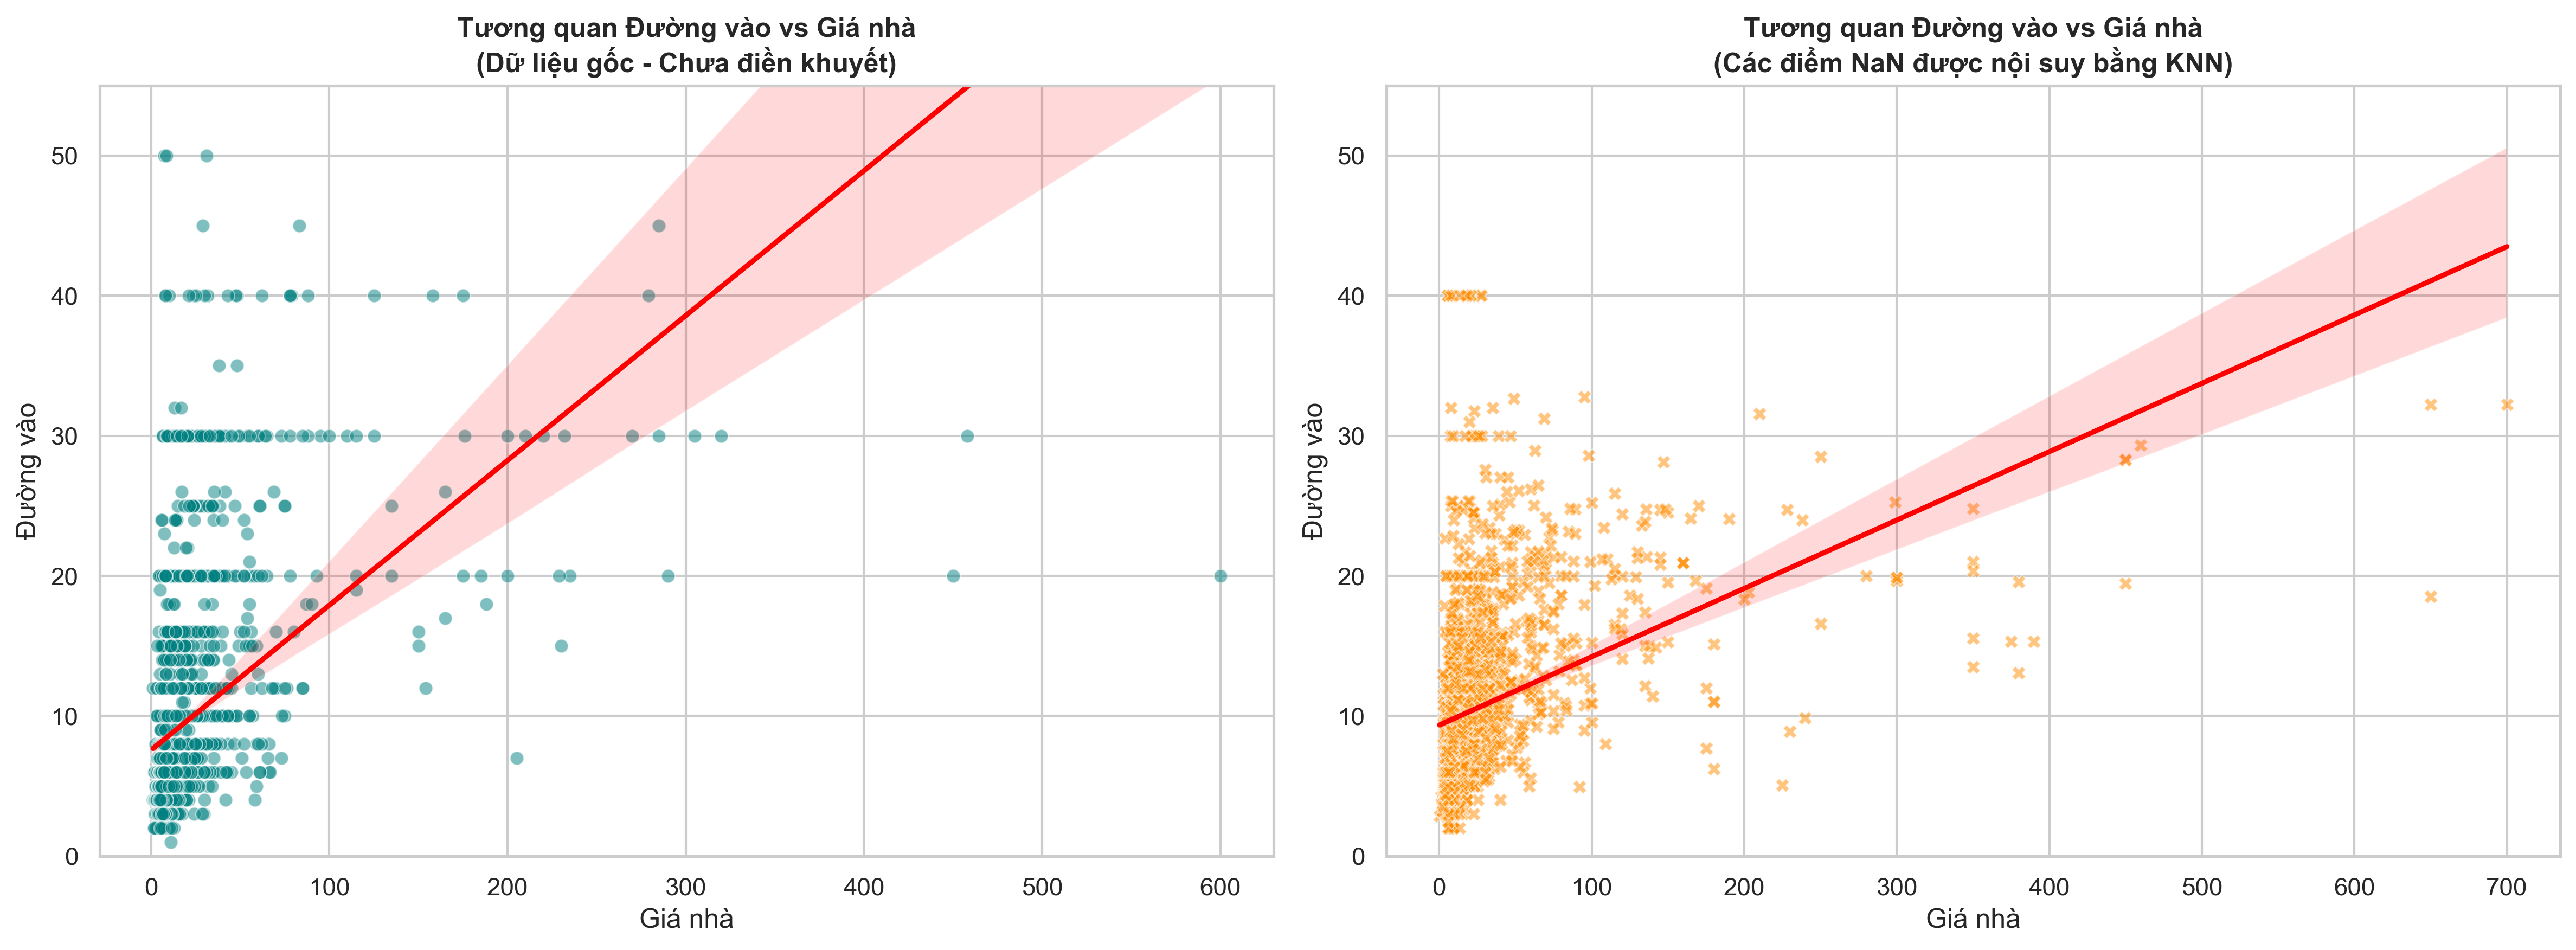

✅ KNN Imputer đã chạy xong!


In [396]:
# =========================================================================
# CELL 1: THỬ NGHIỆM KNN IMPUTER VÀ ĐÁNH GIÁ MỐI TƯƠNG QUAN VỚI GIÁ NHÀ
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print("🔍 ĐANG CHẠY THỬ NGHIỆM KNN IMPUTER...")

# 🛑 BƯỚC SỬA LỖI: Bạn hãy thay thế tên cột chính xác của bạn vào đây nếu nó khác biệt
num_cols = ['Diện tích', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Đường vào']

# Kiểm tra xem các cột có tồn tại trong X_train không
missing_cols = [col for col in num_cols if col not in X_train.columns]
if missing_cols:
    raise KeyError(f"❌ Không tìm thấy các cột {missing_cols} trong X_train. Hãy kiểm tra lại chính xác tên cột bằng cách chạy: print(X_train.columns.tolist())")

# 1. Trích xuất các biến số học để làm cơ sở nội suy
X_train_knn = X_train[num_cols].copy()

# 2. Scale dữ liệu (Bắt buộc với KNN vì thuật toán tính khoảng cách hình học)
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_knn), columns=num_cols, index=X_train.index)

# 3. Fit & Transform KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train_knn_imputed_scaled = pd.DataFrame(knn_imputer.fit_transform(X_train_scaled), columns=num_cols, index=X_train.index)

# 4. Inverse Scale để trả về giá trị thực tế của mét
X_train_knn_imputed = pd.DataFrame(scaler.inverse_transform(X_train_knn_imputed_scaled), columns=num_cols, index=X_train.index)

# Lấy ra các index bị khuyết ban đầu để phục vụ vẽ biểu đồ
missing_idx = X_train['Đường vào'].isna()

# 5. VẼ BIỂU ĐỒ SO SÁNH
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot_original = pd.DataFrame({'Đường vào': X_train.loc[~missing_idx, 'Đường vào'], 'Giá nhà': y_train.loc[~missing_idx]})
df_plot_imputed = pd.DataFrame({'Đường vào': X_train_knn_imputed.loc[missing_idx, 'Đường vào'], 'Giá nhà': y_train.loc[missing_idx]})

# Đồ thị 1: Dữ liệu gốc
sns.scatterplot(data=df_plot_original, x='Giá nhà', y='Đường vào', alpha=0.5, color='teal', ax=axes[0])
sns.regplot(data=df_plot_original, x='Giá nhà', y='Đường vào', scatter=False, color='red', ax=axes[0])
axes[0].set_title('Tương quan Đường vào vs Giá nhà\n(Dữ liệu gốc - Chưa điền khuyết)', fontweight='bold')
axes[0].set_ylim(0, X_train['Đường vào'].max() + 5)

# Đồ thị 2: Dữ liệu do KNN điền
sns.scatterplot(data=df_plot_imputed, x='Giá nhà', y='Đường vào', alpha=0.5, color='darkorange', marker='X', ax=axes[1])
sns.regplot(data=df_plot_imputed, x='Giá nhà', y='Đường vào', scatter=False, color='red', ax=axes[1])
axes[1].set_title('Tương quan Đường vào vs Giá nhà\n(Các điểm NaN được nội suy bằng KNN)', fontweight='bold')
axes[1].set_ylim(0, X_train['Đường vào'].max() + 5)

plt.tight_layout()
plt.show()
print("✅ KNN Imputer đã chạy xong!")

🔍 ĐANG CHẠY THỬ NGHIỆM MICE IMPUTER...


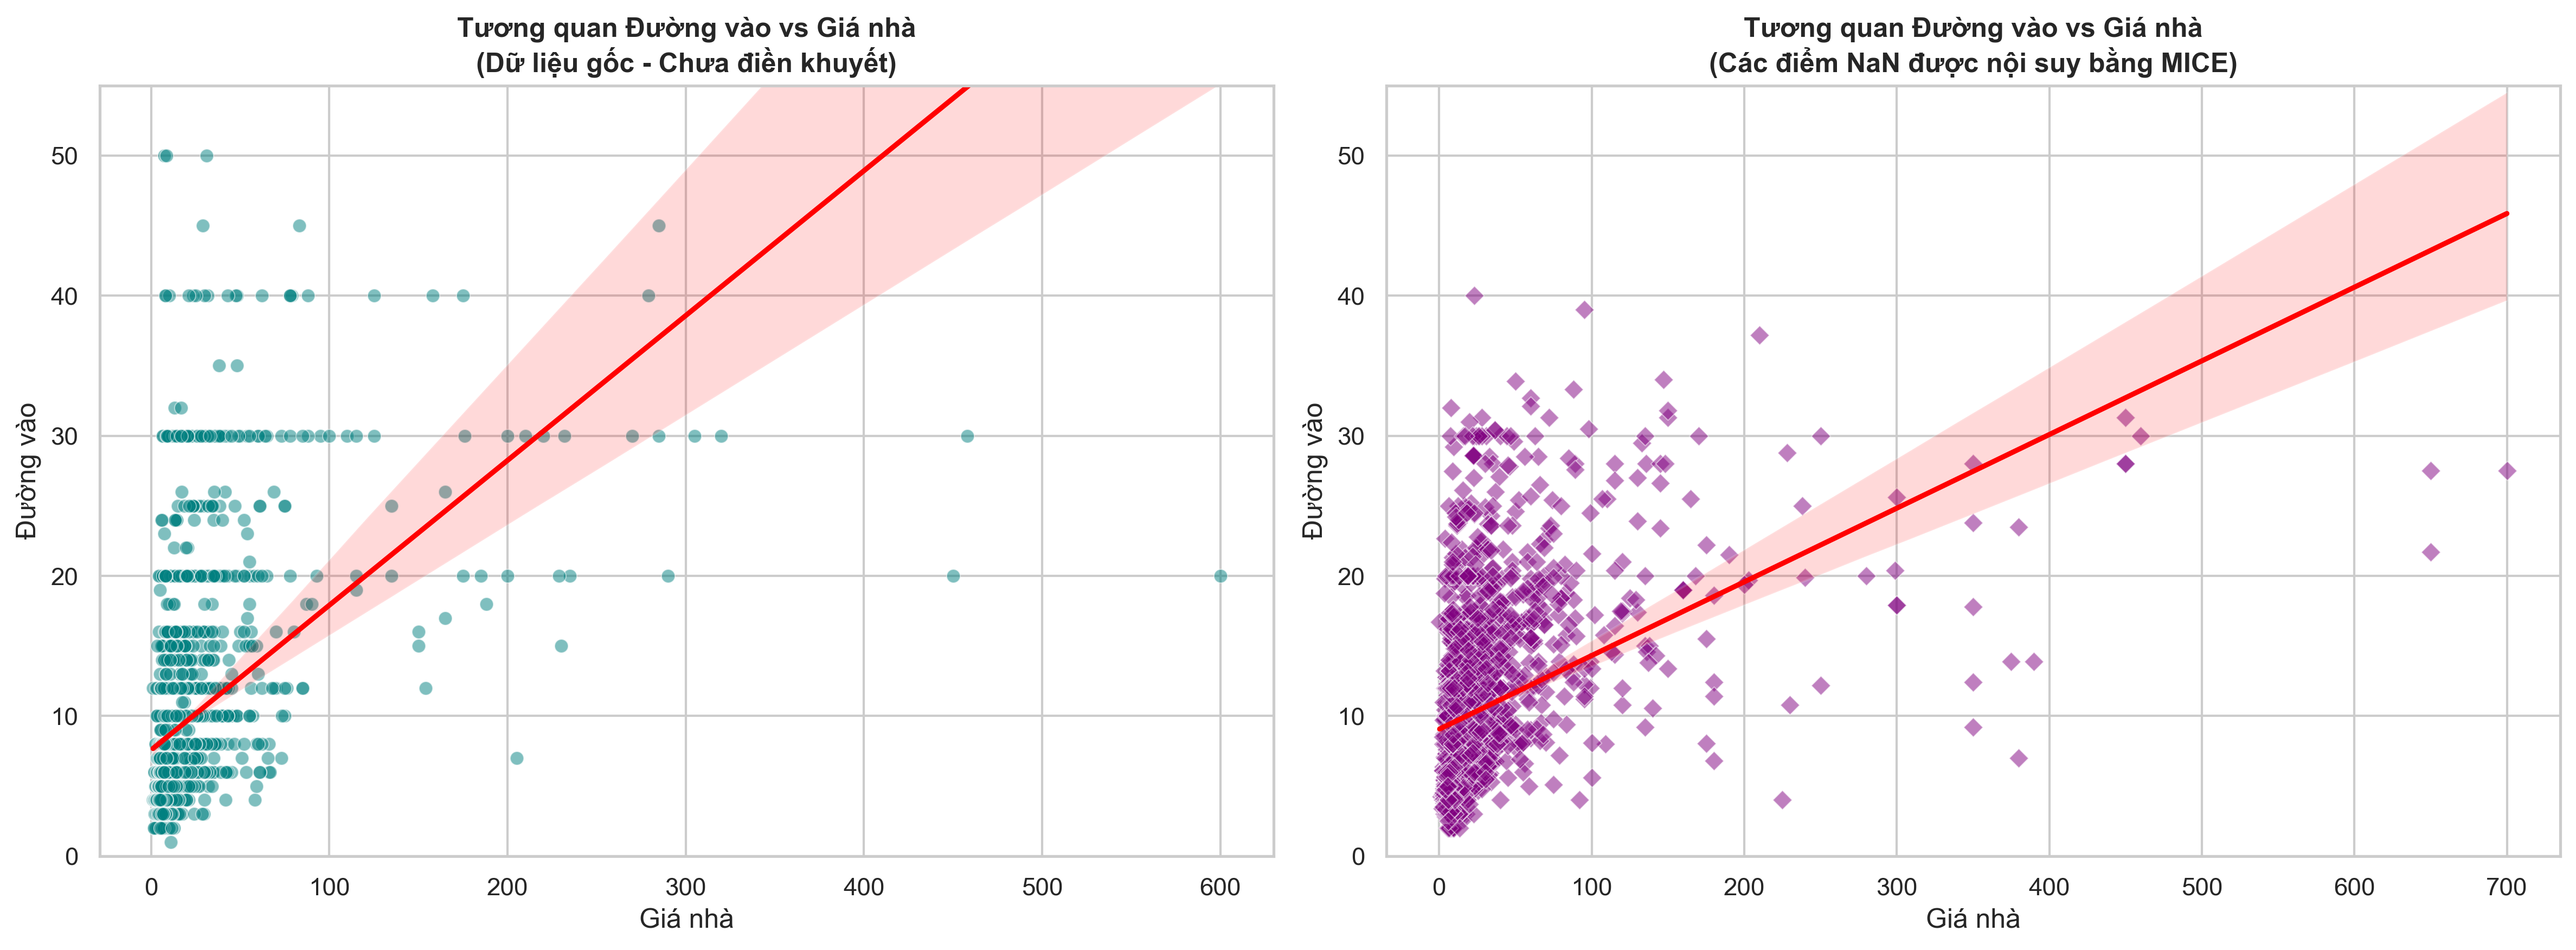

✅ MICE Imputer đã chạy xong!


In [397]:
# =========================================================================
# CELL 2: THỬ NGHIỆM MICE IMPUTER VÀ ĐÁNH GIÁ MỐI TƯƠNG QUAN VỚI GIÁ NHÀ
# =========================================================================
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

print("🔍 ĐANG CHẠY THỬ NGHIỆM MICE IMPUTER...")

# 1. Lấy dữ liệu 
X_train_mice = X_train[num_cols].copy()

# 2. Khởi tạo MICE (Sử dụng ExtraTreesRegressor)
mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
    max_iter=10, 
    random_state=42,
    min_value=0 
)

# 3. Fit & Transform
X_train_mice_imputed = pd.DataFrame(mice_imputer.fit_transform(X_train_mice), columns=num_cols, index=X_train.index)

# 4. VẼ BIỂU ĐỒ SO SÁNH
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot_mice_imputed = pd.DataFrame({'Đường vào': X_train_mice_imputed.loc[missing_idx, 'Đường vào'], 'Giá nhà': y_train.loc[missing_idx]})

# Đồ thị 1: Dữ liệu gốc
sns.scatterplot(data=df_plot_original, x='Giá nhà', y='Đường vào', alpha=0.5, color='teal', ax=axes[0])
sns.regplot(data=df_plot_original, x='Giá nhà', y='Đường vào', scatter=False, color='red', ax=axes[0])
axes[0].set_title('Tương quan Đường vào vs Giá nhà\n(Dữ liệu gốc - Chưa điền khuyết)', fontweight='bold')
axes[0].set_ylim(0, X_train['Đường vào'].max() + 5)

# Đồ thị 2: Dữ liệu do MICE điền
sns.scatterplot(data=df_plot_mice_imputed, x='Giá nhà', y='Đường vào', alpha=0.5, color='purple', marker='D', ax=axes[1])
sns.regplot(data=df_plot_mice_imputed, x='Giá nhà', y='Đường vào', scatter=False, color='red', ax=axes[1])
axes[1].set_title('Tương quan Đường vào vs Giá nhà\n(Các điểm NaN được nội suy bằng MICE)', fontweight='bold')
axes[1].set_ylim(0, X_train['Đường vào'].max() + 5)

plt.tight_layout()
plt.show()
print("✅ MICE Imputer đã chạy xong!")

In [398]:
# =========================================================================
# CELL 3: ÁP DỤNG MICE IMPUTER LÊN TOÀN BỘ PIPELINE (TRAIN & TEST)
# =========================================================================
print("🚀 ĐANG ÁP DỤNG CHÍNH THỨC MICE CHO X_TRAIN VÀ X_TEST...")

# BƯỚC 1: Xử lý biến phân loại trước
for dataset in [X_train, X_test]:
    if 'Loại đường vào' in dataset.columns:
        dataset['Loại đường vào'] = dataset['Loại đường vào'].fillna('Chưa xác định')

# BƯỚC 2: Tạo Flag MNAR (Giữ lại ý tưởng rất tốt của bạn)
# Việc này giúp mô hình bắt được tín hiệu "hành vi giấu thông tin"
for dataset in [X_train, X_test]:
    dataset['duong_vao_null_flag'] = dataset['Đường vào'].isna().astype(int)

# BƯỚC 3: Điền khuyết MICE
# Chỉ chọn các biến số để MICE hoạt động
num_features = ['Diện tích', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Đường vào']

# Khởi tạo mô hình
final_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
    max_iter=10, 
    random_state=42,
    min_value=0 # Không có đường ngõ âm
)

# ⚠️ QUAN TRỌNG: Chỉ FIT trên X_train, TRANSFORM trên cả Train và Test
X_train[num_features] = final_imputer.fit_transform(X_train[num_features])
X_test[num_features]  = final_imputer.transform(X_test[num_features])

print("✅ Đã hoàn tất xử lý Missing Value hoàn hảo không bị Data Leakage!")
print(f"   -> Số dòng NaN Đường vào X_train hiện tại: {X_train['Đường vào'].isna().sum()}")
print(f"   -> Số dòng NaN Đường vào X_test hiện tại : {X_test['Đường vào'].isna().sum()}")

🚀 ĐANG ÁP DỤNG CHÍNH THỨC MICE CHO X_TRAIN VÀ X_TEST...
✅ Đã hoàn tất xử lý Missing Value hoàn hảo không bị Data Leakage!
   -> Số dòng NaN Đường vào X_train hiện tại: 0
   -> Số dòng NaN Đường vào X_test hiện tại : 0


# 3.Feature Extraction/Engineering

In [399]:
''' 
X_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_train_processed.csv')
y_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_train_processed.csv')
X_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_test_processed.csv')
y_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_test_processed.csv')
'''

" \nX_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_train_processed.csv')\ny_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_train_processed.csv')\nX_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_test_processed.csv')\ny_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_test_processed.csv')\n"

## 3.1 Dùng LLM Qwen7B để trích xuất thêm các đặc trưng tiện ích ở cột mô tả.

Khởi tạo mô hình

In [400]:
''' 
from openai import OpenAI
import json
import pandas as pd
from tqdm import tqdm

# 1. Khởi tạo client kết nối với Ollama đang chạy ngầm
client = OpenAI(
    base_url='http://localhost:11434/v1',
    api_key='ollama', 
)

# 2. Định nghĩa danh sách 5 thuộc tính tiện ích (kiểu Boolean) cần trích xuất
tien_ich_cols = [
    'hem_xe_hoi', 
    'gan_cho_sieu_thi', 
    'gan_truong_hoc', 
    'gan_benh_vien', 
    'gan_cong_vien_ho_nuoc'
]

print("✅ Đã cấu hình xong kết nối tới Local LLM. Sẵn sàng trích xuất đặc trưng!")
'''

' \nfrom openai import OpenAI\nimport json\nimport pandas as pd\nfrom tqdm import tqdm\n\n# 1. Khởi tạo client kết nối với Ollama đang chạy ngầm\nclient = OpenAI(\n    base_url=\'http://localhost:11434/v1\',\n    api_key=\'ollama\', \n)\n\n# 2. Định nghĩa danh sách 5 thuộc tính tiện ích (kiểu Boolean) cần trích xuất\ntien_ich_cols = [\n    \'hem_xe_hoi\', \n    \'gan_cho_sieu_thi\', \n    \'gan_truong_hoc\', \n    \'gan_benh_vien\', \n    \'gan_cong_vien_ho_nuoc\'\n]\n\nprint("✅ Đã cấu hình xong kết nối tới Local LLM. Sẵn sàng trích xuất đặc trưng!")\n'

In [401]:
''' 
def extract_features_pipeline(df_input, text_column='Mô tả'):
    # Tạo bản sao để bảo vệ DataFrame gốc và tránh SettingWithCopyWarning
    df_res = df_input.copy()
    
    # Khởi tạo trước các cột tiện ích bằng giá trị 0 (mặc định là không có)
    for col in tien_ich_cols:
        df_res[col] = 0
        
    print(f"⏳ Đang quét cột '{text_column}' để trích xuất đặc trưng (Tổng số dòng: {len(df_res)})...")
    
    # Vòng lặp duyệt qua từng dòng dữ liệu bằng tqdm để theo dõi tiến độ
    for index, row in tqdm(df_res.iterrows(), total=len(df_res), desc="LLM Processing"):
        description = row[text_column]
        
        # Nếu dòng bị trống mô tả, bỏ qua và giữ nguyên giá trị 0 mặc định
        if pd.isna(description) or str(description).strip() == "":
            continue
            
        prompt = f"""
        Đọc đoạn mô tả bất động sản sau và xác định xem các tiện ích xung quanh có được nhắc đến hay không.
        Trả về giá trị 1 nếu CÓ nhắc đến (hoặc có ý nghĩa tương đương), và 0 nếu KHÔNG nhắc đến.
        
        BẮT BUỘC TRẢ VỀ ĐÚNG ĐỊNH DẠNG JSON VỚI CÁC KEY SAU (không giải thích thêm):
        {{
            "hem_xe_hoi": 0,
            "gan_cho_sieu_thi": 0,
            "gan_truong_hoc": 0,
            "gan_benh_vien": 0,
            "gan_cong_vien_ho_nuoc": 0
        }}
        
        Mô tả: "{description}"
        """
        
        try:
            response = client.chat.completions.create(
                model="qwen2.5:7b", 
                messages=[{"role": "user", "content": prompt}],
                response_format={ "type": "json_object" },
                temperature=0.1
            )
            
            # Ép kiểu dữ liệu chuỗi JSON trả về thành Dictionary trong Python
            extracted_data = json.loads(response.choices[0].message.content)
            
            # Cập nhật giá trị vào các cột tương ứng tại đúng Index của căn nhà đó
            if extracted_data:
                for col in tien_ich_cols:
                    df_res.at[index, col] = int(extracted_data.get(col, 0))
                    
        except Exception as e:
            # Nếu một dòng bị lỗi (LLM phản hồi lỗi hoặc rớt mạng), giữ nguyên giá trị 0 để không sập code
            continue
            
    return df_res

print("✅ Đã đóng gói hàm extract_features_pipeline thành công!")
'''

' \ndef extract_features_pipeline(df_input, text_column=\'Mô tả\'):\n    # Tạo bản sao để bảo vệ DataFrame gốc và tránh SettingWithCopyWarning\n    df_res = df_input.copy()\n    \n    # Khởi tạo trước các cột tiện ích bằng giá trị 0 (mặc định là không có)\n    for col in tien_ich_cols:\n        df_res[col] = 0\n        \n    print(f"⏳ Đang quét cột \'{text_column}\' để trích xuất đặc trưng (Tổng số dòng: {len(df_res)})...")\n    \n    # Vòng lặp duyệt qua từng dòng dữ liệu bằng tqdm để theo dõi tiến độ\n    for index, row in tqdm(df_res.iterrows(), total=len(df_res), desc="LLM Processing"):\n        description = row[text_column]\n        \n        # Nếu dòng bị trống mô tả, bỏ qua và giữ nguyên giá trị 0 mặc định\n        if pd.isna(description) or str(description).strip() == "":\n            continue\n            \n        prompt = f"""\n        Đọc đoạn mô tả bất động sản sau và xác định xem các tiện ích xung quanh có được nhắc đến hay không.\n        Trả về giá trị 1 nếu CÓ nhắc đế

In [402]:
''' 
# 1. Áp dụng cho tập huấn luyện (X_train)
print("=== TIẾN HÀNH TRÍCH XUẤT TRÊN TẬP TRAIN ===")
X_train = extract_features_pipeline(X_train, text_column='Mô tả')

# 2. Áp dụng cho tập kiểm thử (X_test)
print("\n=== TIẾN HÀNH TRÍCH XUẤT TRÊN TẬP TEST ===")
X_test = extract_features_pipeline(X_test, text_column='Mô tả')

# 3. Kiểm tra nhanh kết quả sau khi trích xuất
print("\n📊 Kiểm tra ngẫu nhiên 5 dòng cuối cùng của X_train với các thuộc tính mới:")
display(X_train[tien_ich_cols].tail())
'''

' \n# 1. Áp dụng cho tập huấn luyện (X_train)\nprint("=== TIẾN HÀNH TRÍCH XUẤT TRÊN TẬP TRAIN ===")\nX_train = extract_features_pipeline(X_train, text_column=\'Mô tả\')\n\n# 2. Áp dụng cho tập kiểm thử (X_test)\nprint("\n=== TIẾN HÀNH TRÍCH XUẤT TRÊN TẬP TEST ===")\nX_test = extract_features_pipeline(X_test, text_column=\'Mô tả\')\n\n# 3. Kiểm tra nhanh kết quả sau khi trích xuất\nprint("\n📊 Kiểm tra ngẫu nhiên 5 dòng cuối cùng của X_train với các thuộc tính mới:")\ndisplay(X_train[tien_ich_cols].tail())\n'

## 3.2 Tạo biến tương tác

Xác định đa cộng tuyến bằng ma trận tương quan.

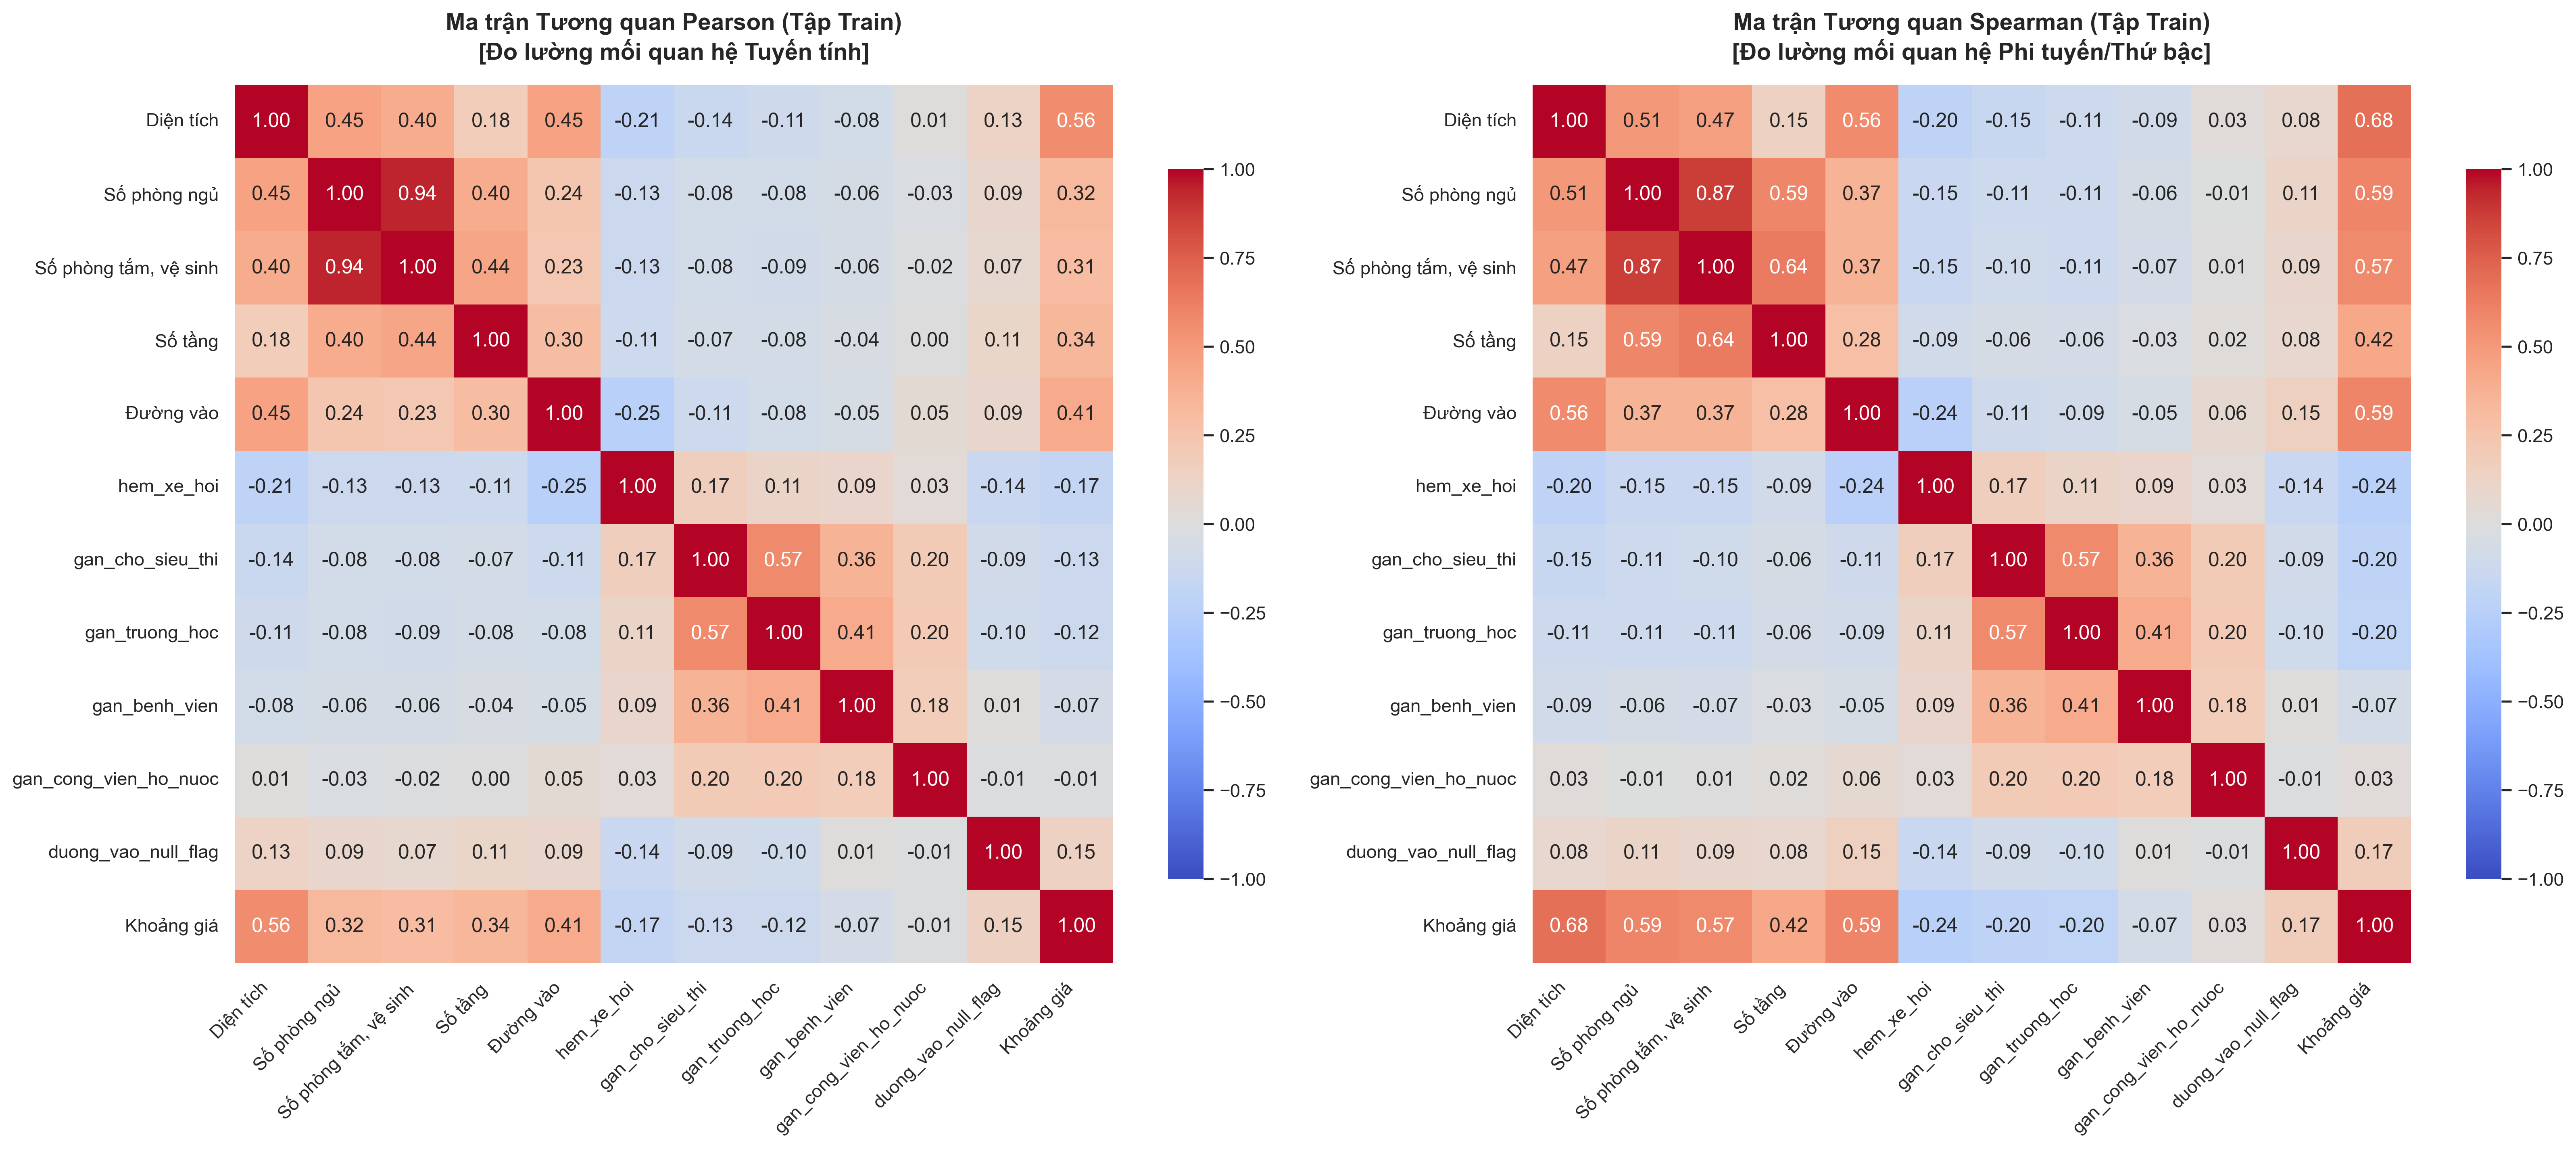

In [403]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: VẼ MA TRẬN TƯƠNG QUAN PEARSON VÀ SPEARMAN (CHỈ TRÊN TẬP TRAIN)
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ghép X_train và y_train thành một DataFrame tạm thời để tính toán đồng bộ
# Đảm bảo index của 2 tập này đang khớp nhau
train_data = pd.concat([X_train, y_train], axis=1)
train_data = train_data.drop(columns = ['Longitude', 'Latitude', 'Khoảng giá_log'])

# 2. Lọc ra các cột có định dạng số (tránh lỗi khi đưa các cột Text/Categorical vào tính)
train_numeric = train_data.select_dtypes(include=[np.number])

# 3. Tính toán 2 loại ma trận tương quan
pearson_corr = train_numeric.corr(method='pearson')
spearman_corr = train_numeric.corr(method='spearman')

# 4. Khởi tạo khung hình với 1 hàng và 2 cột (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# --- BIỂU ĐỒ 1: Ma trận Pearson (Tương quan Tuyến tính) ---
sns.heatmap(
    pearson_corr, 
    annot=True,          # Hiển thị con số trên ô
    fmt=".2f",           # Lấy 2 chữ số thập phân
    cmap='coolwarm',     # Thang màu từ Lạnh (âm) sang Nóng (dương)
    vmin=-1, vmax=1,     # Giới hạn giá trị chuẩn của hệ số tương quan
    square=True,         # Ép các ô thành hình vuông cho đẹp
    ax=axes[0],
    cbar_kws={"shrink": .8}
)
axes[0].set_title('Ma trận Tương quan Pearson (Tập Train)\n[Đo lường mối quan hệ Tuyến tính]', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# --- BIỂU ĐỒ 2: Ma trận Spearman (Tương quan Phi tuyến / Thứ bậc) ---
sns.heatmap(
    spearman_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    ax=axes[1],
    cbar_kws={"shrink": .8}
)
axes[1].set_title('Ma trận Tương quan Spearman (Tập Train)\n[Đo lường mối quan hệ Phi tuyến/Thứ bậc]', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# 5. Tinh chỉnh khoảng cách hiển thị và show hình
plt.tight_layout()
plt.show()

Phát hiện đa cộng tuyến nặng ở cột 'Số phòng ngủ' và 'Số phòng tắm, vệ sinh'. 2 cột này sẽ được cộng lại để tạo thành một đăch trưng mới là Tổng số phòng.

In [404]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: TẠO BIẾN TƯƠNG TÁC VÀ VẼ LẠI MA TRẬN TƯƠNG QUAN
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tạo biến mới 'Tổng số phòng' cho CẢ X_train VÀ X_test để đồng bộ
X_train['Tổng số phòng'] = X_train['Số phòng ngủ'] + X_train['Số phòng tắm, vệ sinh']
X_test['Tổng số phòng'] = X_test['Số phòng ngủ'] + X_test['Số phòng tắm, vệ sinh']

# 2. Xóa bỏ 2 biến gốc để triệt tiêu hoàn toàn bệnh đa cộng tuyến
cols_to_drop = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

print("✅ Đã tạo 'Tổng số phòng' và xóa các cột gốc trên cả Train & Test thành công!\n")

✅ Đã tạo 'Tổng số phòng' và xóa các cột gốc trên cả Train & Test thành công!



In [405]:
print(train_data.columns)

Index(['Link', 'Địa chỉ', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh',
       'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Mô tả',
       'Loại đường vào', 'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc',
       'gan_benh_vien', 'gan_cong_vien_ho_nuoc', 'Đường', 'Phường/Xã/Thị Trấn',
       'Quận', 'duong_vao_null_flag', 'Khoảng giá'],
      dtype='object')


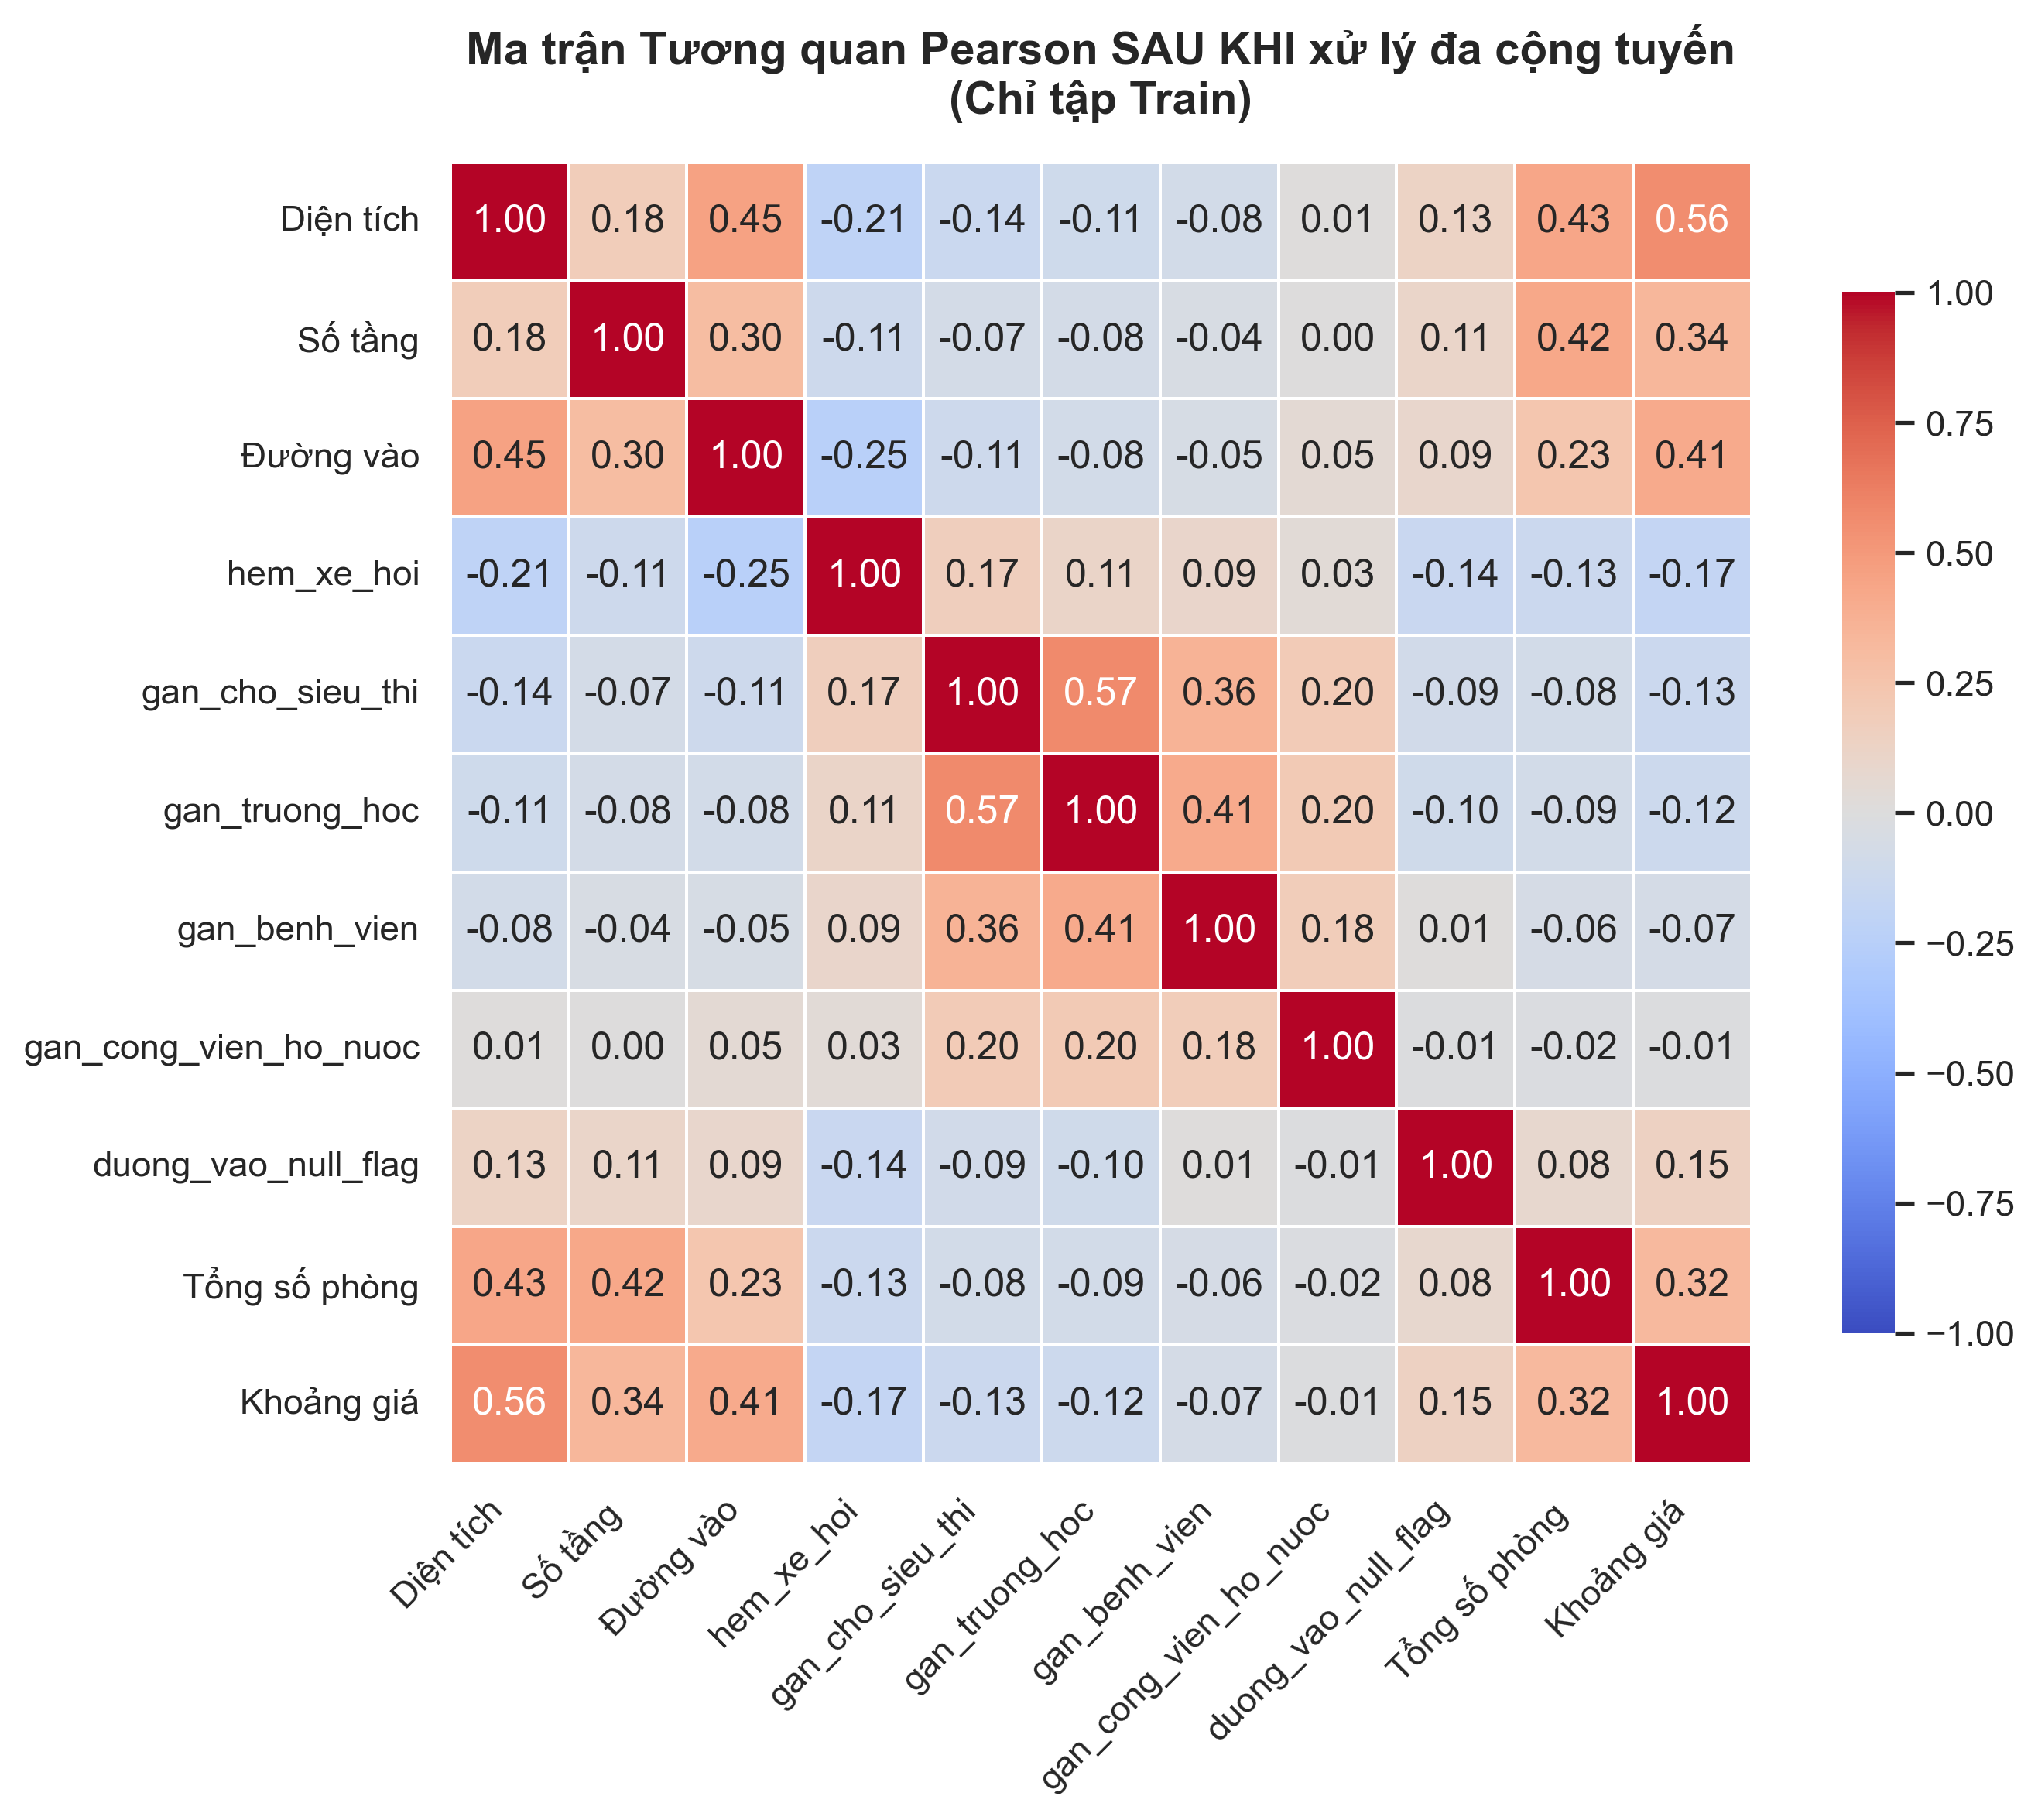

In [406]:
# 3. Ghép X_train và y_train thành một DataFrame tạm thời để tính toán
train_data = pd.concat([X_train, y_train], axis=1)
train_data = train_data.drop(columns = ['Longitude', 'Latitude', 'Khoảng giá_log'])

# Lọc ra các cột định dạng số
train_numeric = train_data.select_dtypes(include=[np.number])

# 4. Tính toán ma trận tương quan Pearson mới
pearson_corr_new = train_numeric.corr(method='pearson')

# 5. Vẽ lại biểu đồ Heatmap để kiểm tra thành quả
plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr_new, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True,
    cbar_kws={"shrink": .8},
    linewidths=0.5
)
plt.title('Ma trận Tương quan Pearson SAU KHI xử lý đa cộng tuyến\n(Chỉ tập Train)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Biến mới không giảm tương quan so với biến mục tiêu.

## 3.3 Lưu data đã clean, trước tiền xử lý.

In [407]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: XÓA CÁC CỘT RÁC / KHÔNG CÓ GIÁ TRỊ DỰ ĐOÁN (ĐẶT NGAY ĐẦU TIÊN)
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd

print("⏳ Đang dọn dẹp các cột văn bản không có giá trị phân tích...")

# 1. Danh sách các cột văn bản tự do, mã định danh không mang tính thống kê
cols_to_drop_early = ['Link', 'Địa chỉ', 'Mô tả']

# 2. Xóa các cột này khỏi X_train và X_test
# Mẹo: errors='ignore' giúp code không bị báo lỗi nếu bạn lỡ bấm chạy (run) cell này nhiều lần
X_train = X_train.drop(columns=cols_to_drop_early, errors='ignore')

if 'X_test' in locals():
    X_test = X_test.drop(columns=cols_to_drop_early, errors='ignore')

print(f"✅ Đã dọn dẹp xong! Các cột bị xóa: {cols_to_drop_early}")
print(f"📐 Kích thước X_train hiện tại: {X_train.shape}")

⏳ Đang dọn dẹp các cột văn bản không có giá trị phân tích...
✅ Đã dọn dẹp xong! Các cột bị xóa: ['Link', 'Địa chỉ', 'Mô tả']
📐 Kích thước X_train hiện tại: (4774, 19)


# 4. Lưu dữ liệu đã làm sạch

In [408]:
X_train = X_train.drop(columns = ['Khoảng giá_log'])
X_test = X_test.drop(columns = ['Khoảng giá_log'])

In [409]:
# ═══════════════════════════════════════════════════════════════════════
# CELL LƯU FILE 1: LƯU DỮ LIỆU BAN ĐẦU (ĐÃ CLEAN, TRƯỚC BIẾN ĐỔI)
# ═══════════════════════════════════════════════════════════════════════
import os

# Tạo thư mục lưu trữ nếu chưa có (Tùy chọn)
os.makedirs('data_output', exist_ok=True)

# Ghép Feature và Target thành dataframe hoàn chỉnh để lưu
df_train_clean = pd.concat([X_train, y_train], axis=1)
# Kiểm tra nếu tập test có y_test thì ghép, không thì chỉ lưu X_test
df_test_clean = pd.concat([X_test, y_test], axis=1) if 'y_test' in locals() else X_test.copy()

# Lưu file dạng CSV
df_train_clean.to_csv('data_output/1_data_cleaned_train.csv', index=False)
df_test_clean.to_csv('data_output/1_data_cleaned_test.csv', index=False)

print("💾 FILE 1: Đã lưu dữ liệu Clean ban đầu thành công!")
print("   -> data_output/1_data_cleaned_train.csv")
print("   -> data_output/1_data_cleaned_test.csv")

💾 FILE 1: Đã lưu dữ liệu Clean ban đầu thành công!
   -> data_output/1_data_cleaned_train.csv
   -> data_output/1_data_cleaned_test.csv
